In [ ]:
# === STEP 1: Uninstall conflicting PyTorch & PyG packages ===
!pip uninstall -y torch torchvision torchaudio torch_geometric pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv

# === STEP 2: Install EXACT matching PyTorch + PyG stack ===
# PyTorch 2.4.0 (exact match for PyG wheels)
!pip install --quiet torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121

# PyG + scatter/sparse/etc for torch 2.4.0 + cu121
!pip install --quiet \
    torch_geometric \
    pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

# === STEP 3: Install Gymnasium + SB3 ===
!pip install --quiet gymnasium "stable-baselines3[extra]"

# === STEP 4: Verify imports ===
import torch
import torch_geometric
from torch_scatter import scatter
import gymnasium
import stable_baselines3

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"PyG: {torch_geometric.__version__}")
print(f"torch_scatter: OK")
print(f"Gymnasium: {gymnasium.__version__}")
print(f"SB3: {stable_baselines3.__version__}")

Found existing installation: torch 2.4.0+cu121
Uninstalling torch-2.4.0+cu121:
  Successfully uninstalled torch-2.4.0+cu121
Found existing installation: torchvision 0.19.0+cu121
Uninstalling torchvision-0.19.0+cu121:
  Successfully uninstalled torchvision-0.19.0+cu121
Found existing installation: torchaudio 2.4.0+cu121
Uninstalling torchaudio-2.4.0+cu121:
  Successfully uninstalled torchaudio-2.4.0+cu121
Found existing installation: torch-geometric 2.7.0
Uninstalling torch-geometric-2.7.0:
  Successfully uninstalled torch-geometric-2.7.0
Found existing installation: pyg_lib 0.4.0+pt24cu121
Uninstalling pyg_lib-0.4.0+pt24cu121:
  Successfully uninstalled pyg_lib-0.4.0+pt24cu121
Found existing installation: torch_scatter 2.1.2+pt24cu121
Uninstalling torch_scatter-2.1.2+pt24cu121:
  Successfully uninstalled torch_scatter-2.1.2+pt24cu121
Found existing installation: torch_sparse 0.6.18+pt24cu121
Uninstalling torch_sparse-0.6.18+pt24cu121:
  Successfully uninstalled torch_sparse-0.6.18+pt24

AttributeError: partially initialized module 'torch_geometric' has no attribute 'typing' (most likely due to a circular import)

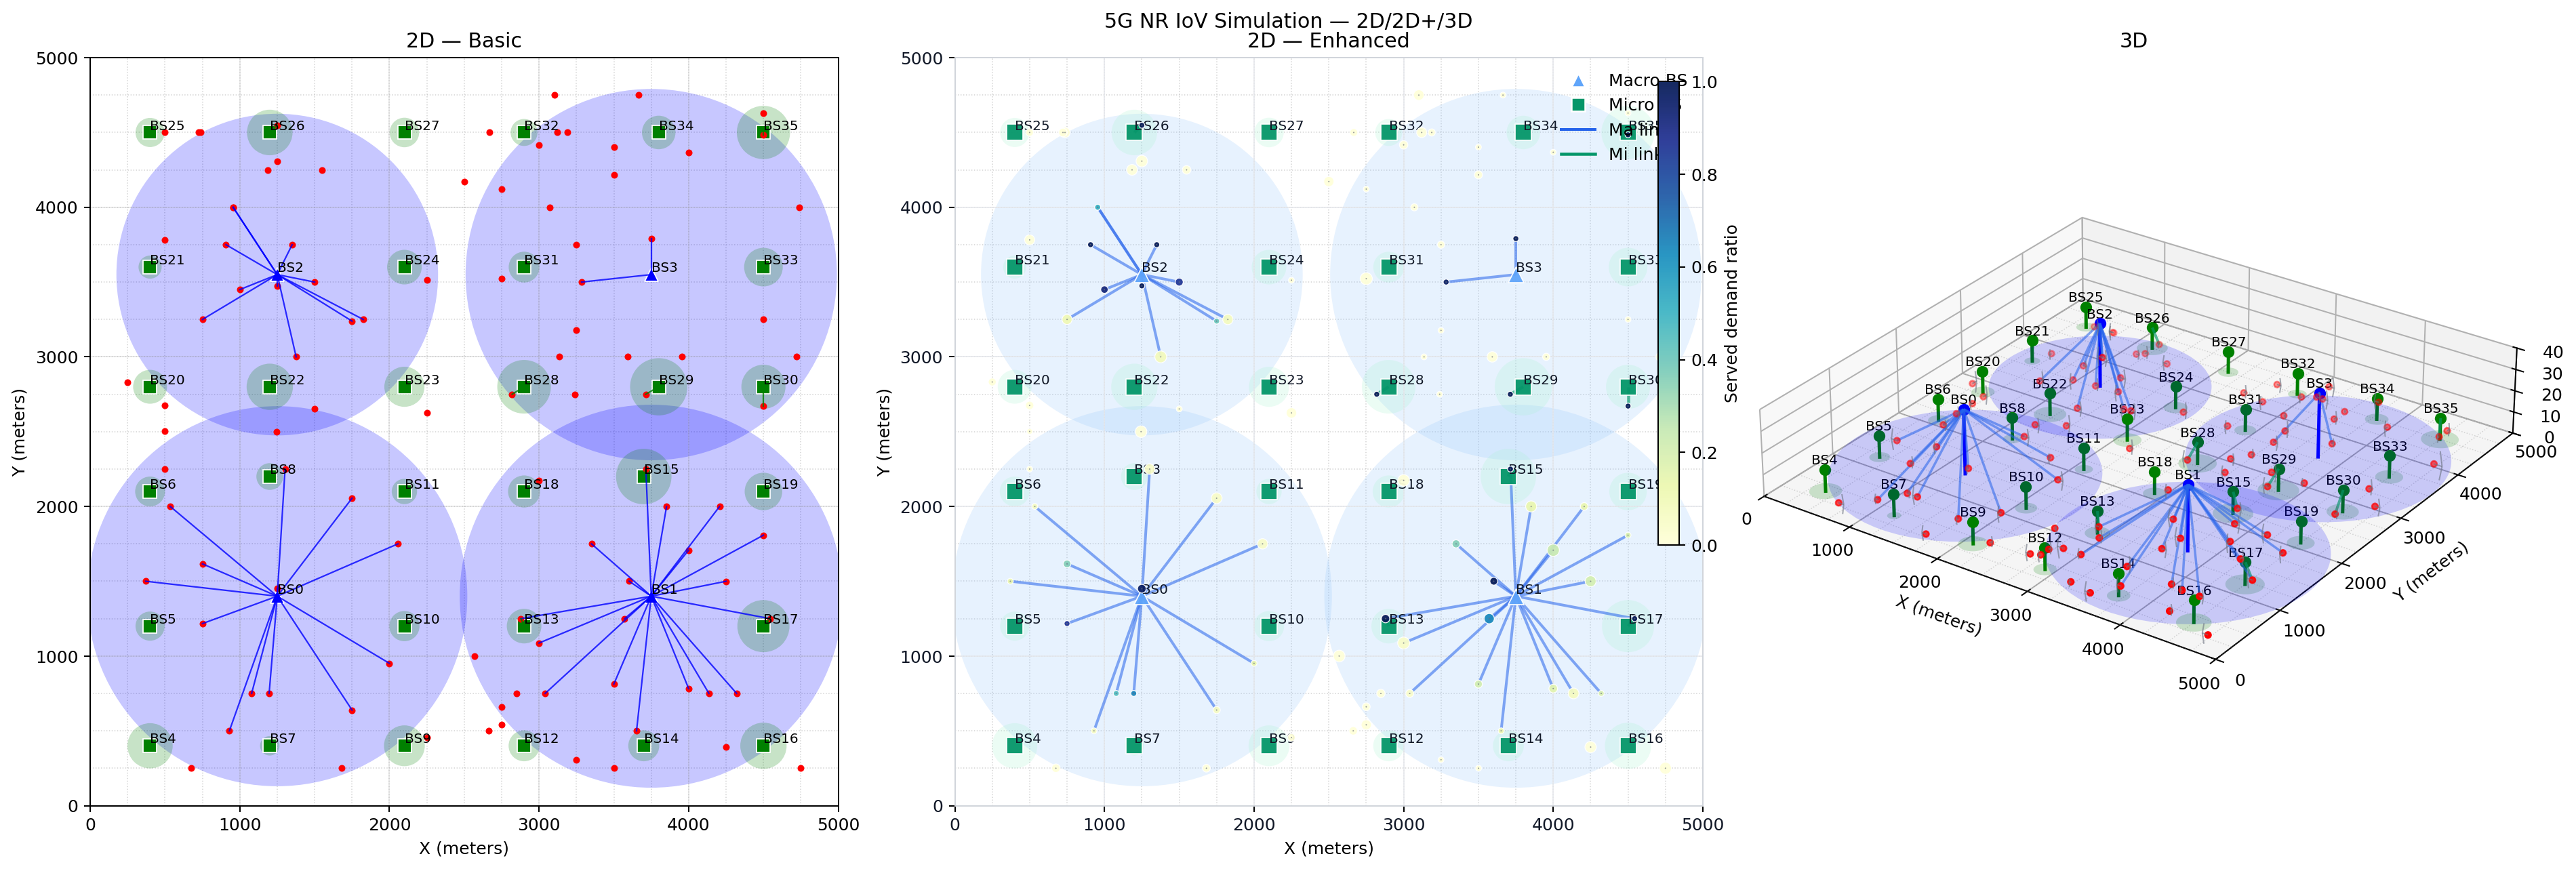

Starting rendering test... (close plot window to stop)


/tmp/ipython-input-3809894034.py:1701: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.fig.canvas.draw_idle()


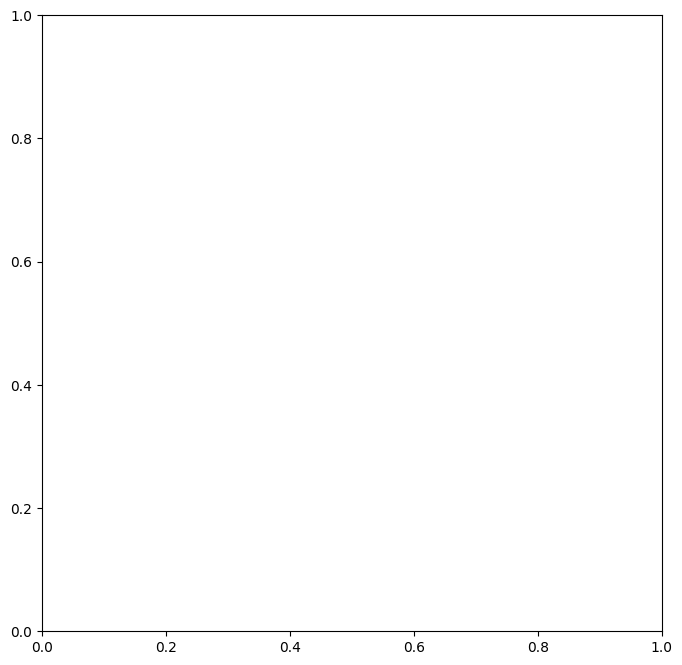

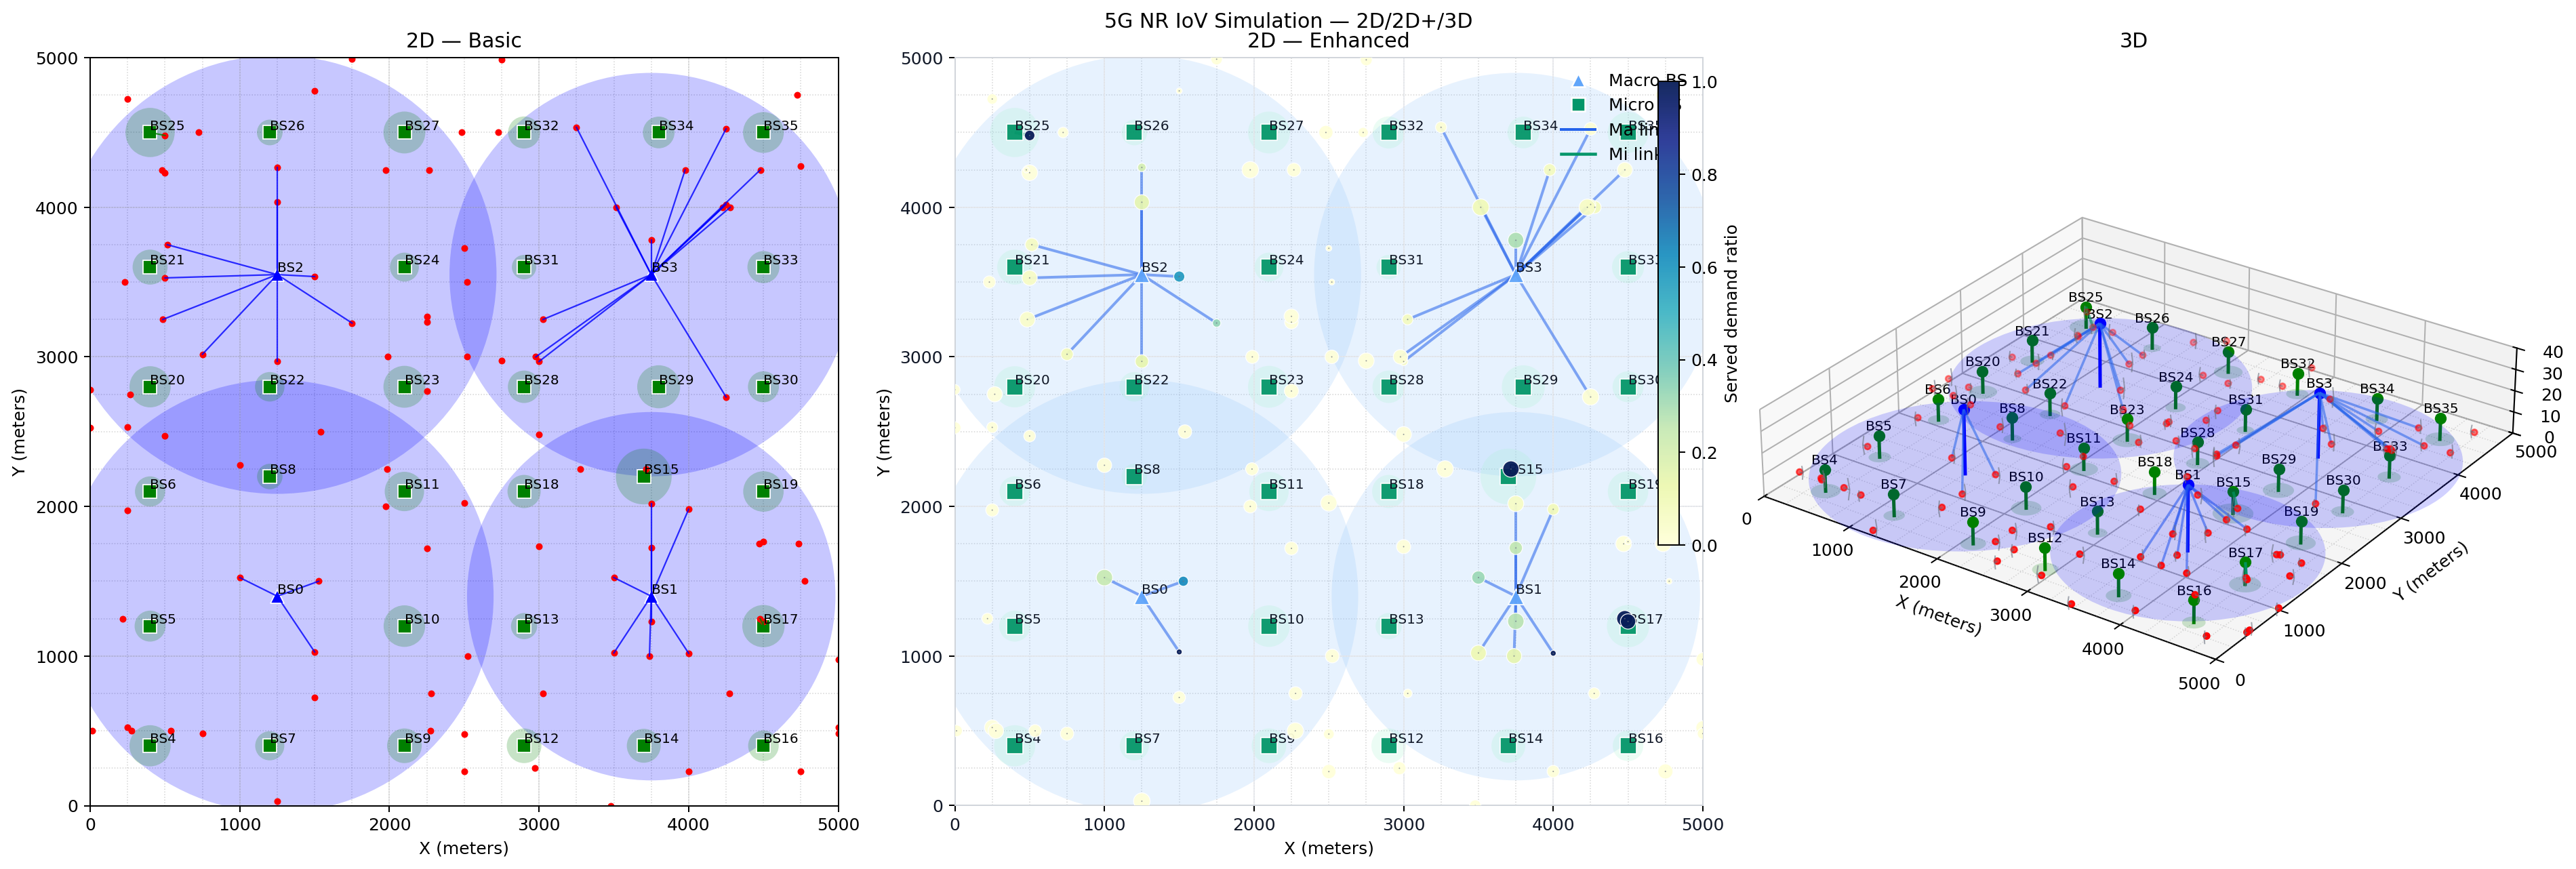

/tmp/ipython-input-3809894034.py:1701: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.fig.canvas.draw_idle()
/tmp/ipython-input-3809894034.py:1701: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.fig.canvas.draw_idle()
/tmp/ipython-input-3809894034.py:1701: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.fig.canvas.draw_idle()
/tmp/ipython-input-3809894034.py:1701: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.fig.canvas.draw_idle()
/tmp/ipython-input-3809894034.py:1701: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.


Finished. Steps=200, Total reward=79.302


In [ ]:
import numpy as np
import random
from collections import defaultdict
import warnings
from types import SimpleNamespace

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
try:
    from IPython.display import display
    _HAVE_IPY = True
except Exception:
    _HAVE_IPY = False


# =========================
# 5G/NR PHY HELPERS & PARAMS
# =========================
# 3GPP-style RX sensitivity (dBm): -174 + 10log10(BW) + NF + SNR_req
def rx_sensitivity_dBm(bw_hz, nf_db=7.0, snr_req_db=-5.0):
    return -174.0 + 10.0*np.log10(max(bw_hz, 1.0)) + nf_db + snr_req_db

# --- 256-QAM parameters (NR Rel-15+ compatible) ---
MOD_ORDER = 256
BITS_PER_CODEWORD = int(np.log2(MOD_ORDER))  # 8 bits per symbol/codeword for 256-QAM

# Shannon with SNR gap (linear), gently capped at 256-QAM = 8 b/s/Hz
def spectral_efficiency_from_sinr(SINR_dB, gap_db=1.5, max_se=float(BITS_PER_CODEWORD)):
    """
    Link-to-system: SE ≈ log2(1 + SINR/Γ), capped to 256-QAM's 8 bits/s/Hz.
    Γ (gap) ~ 1.5 dB approximates coding/implementation loss.
    """
    gamma = 10.0**(SINR_dB/10.0) / (10.0**(gap_db/10.0))
    se = np.log2(1.0 + gamma)
    return float(np.clip(se, 0.0, max_se))

# NR physical-layer overhead (PDCCH/DMRS/CSI-RS/guard etc.)
NR_OVERHEAD = 0.85
SNR_GAP_DB = 1.5      # “SNR gap” to Shannon
# IMPORTANT: for strict 256-QAM, cap is exactly 8 b/s/Hz
MAX_SE = float(BITS_PER_CODEWORD)

# Per-tier MIMO max spatial layers (rank)
MIMO_MAX_RANK = {'Ma': 4, 'Mi': 8}

# Simple antenna / beam gains (approximate)
BEAM_GAIN_DB = {
    'Ma': {'tx_main': 8.0,  'tx_side': -3.0, 'rx': 0.0},   # macro panel-ish
    'Mi': {'tx_main': 15.0, 'tx_side': -5.0, 'rx': 7.0},   # mmWave pencil beam-ish
}

# UE-side RX gain used for **interference** accumulation
UE_INTERF_RX_DB = 0.0

# Macro reuse toggle (True => reuse-1 macro interference)
MACRO_REUSE_ONE = False


def mimo_rank_and_total_se(SINR_dB: float, max_layers: int,
                           gap_db: float = SNR_GAP_DB, max_se: float = MAX_SE) -> (int, float):
    """
    Pick MIMO rank (1..max_layers) that maximizes sum-SE assuming equal power split across layers.
    Includes a mild correlation/overhead loss for higher ranks.
    Per-layer SE is capped to 8 b/s/Hz (256-QAM).
    """
    sinr_lin = 10.0**(SINR_dB/10.0)
    best_L, best_sum_se = 1, spectral_efficiency_from_sinr(SINR_dB, gap_db, max_se)
    for L in range(2, max_layers+1):
        # Equal power split: SNR per layer ~ sinr_lin / L
        per_layer_snr_dB = 10.0*np.log10(max(sinr_lin / max(L, 1), 1e-12))
        se_layer = spectral_efficiency_from_sinr(per_layer_snr_dB, gap_db, max_se)
        # Mild degradation for higher ranks (spatial correlation, DMRS overhead, precoder loss)
        corr_eff = max(0.5, 1.0 - 0.07*(L-1))
        sum_se = L * se_layer * corr_eff
        if sum_se > best_sum_se:
            best_sum_se, best_L = sum_se, L
    return best_L, float(best_sum_se)


# ---------- Observation index constants ----------
# Keep these in sync with MobileNetwork.get_observation()
OBS_IDX = SimpleNamespace(
    BS_TYPE=0, TX_NORM=1, CH_UTIL=2, COV_UTIL=3, LOAD_RATIO_NORM=4, NEARBY_POT=5, AVG_SPEED=6,
    REQ_P_NORM=7, AVG_RADIAL_V=8, SP_VAR=9, NEIGHBOR_TX_NORM=10, AVG_DEMAND_NORM=11, INTER_NORM=12
)

# =========================
# ENVIRONMENT
# =========================

class Channel:
    def __init__(self, id, frequency, bandwidth, noise_figure_db=7.0):
        self.id = id
        self.frequency = frequency            # Hz
        self.bandwidth = bandwidth            # Hz
        self.users = []
        self.base_station = None
        self.temperature = 293.15             # K
        self.noise_figure_db = noise_figure_db

    def calculate_noise_power(self):
        """Thermal noise (W) inc. NF: N = kTB * NF."""
        k = 1.38e-23
        N = k * self.temperature * self.bandwidth
        NF = 10.0**(self.noise_figure_db / 10.0)
        return N * NF  # W


class BaseStation:
    def __init__(self, id, transmit_power, height, location, type_bs):
        self.id = id
        self.transmit_power = transmit_power  # mW (total across channels)
        self.height = height
        self.type_bs = type_bs  # 'Ma' (macro) or 'Mi' (micro/mmWave)
        self.location = np.array(location, dtype=float)
        self.users = []
        self.assigned_channels = []  # channels reserved by this BS
        self.coverage_area = 0.0
        self.per_channel_power = {}  # channel_id -> mW (set each step)
        self.MAX_COVERAGE   = {'Ma': 2000.0, 'Mi': 350.0}  # hard cap (tune 250–400 m)
        self.COV_MARGIN_DB  = {'Ma': 3.0,    'Mi': 20.0}   # extra loss for blockage/penumbra
        self.SNR_REQ_DB     = {'Ma': -5.0,   'Mi': +5.0}   # mmWave needs higher SINR at cell edge


    # --- 3GPP TR 38.901 3D-UMa/3D-UMi PL (approximate) ---
    def _pl_uma_los(self, d3d, f_ghz, h_ut=1.5):
        c = 3e8
        f_hz = f_ghz * 1e9
        h_bs = float(self.height)
        d2d = max(np.sqrt(max(d3d**2 - (h_bs - h_ut)**2, 1e-9)), 1.0)
        h_bs_eff = h_bs - 1.0
        h_ut_eff = h_ut - 1.0
        d_bp = 4.0 * h_bs_eff * h_ut_eff * f_hz / c
        pl1 = 28.0 + 22.0*np.log10(d3d) + 20.0*np.log10(f_ghz)
        if d2d <= d_bp:
            return pl1
        pl2 = 28.0 + 40.0*np.log10(d3d) + 20.0*np.log10(f_ghz) - 9.0*np.log10(d_bp**2 + (h_bs - h_ut)**2)
        return pl2

    def _pl_uma_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=h_ut)
        pl_nlos = 13.54 + 39.08*np.log10(d3d) + 20.0*np.log10(f_ghz) - 0.6*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _pl_umi_los(self, d3d, f_ghz):
        return 32.4 + 21.0*np.log10(f_ghz) + 20.0*np.log10(d3d)

    def _pl_umi_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_umi_los(d3d, f_ghz)
        pl_nlos = 22.4 + 35.3*np.log10(d3d) + 21.3*np.log10(f_ghz) - 0.3*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _eirp_dbm(self, transmit_power_mW: float) -> float:
        g = BEAM_GAIN_DB[self.type_bs]
        tx_dbm = 10.0*np.log10(max(transmit_power_mW, 1e-15))
        return tx_dbm + g['tx_main'] + g['rx']

    def calculate_path_loss(self, distance, frequency, user_height=1.5):
        d2d = max(float(distance), 0.1)
        f_ghz = frequency / 1e9
        d3d = np.sqrt(d2d**2 + (self.height - user_height)**2)

        if self.type_bs == 'Ma':
            # UMa
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 63.0)) + np.exp(-d2d / 63.0)
            pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=user_height)
            pl_nlos = self._pl_uma_nlos(d3d, f_ghz, h_ut=user_height)
        else:
            # UMi / mmWave-ish
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 36.0)) + np.exp(-d2d / 36.0)
            pl_los = self._pl_umi_los(d3d, f_ghz)
            pl_nlos = self._pl_umi_nlos(d3d, f_ghz, h_ut=user_height)

        return float(p_los * pl_los + (1.0 - p_los) * pl_nlos)


    def update_coverage_area_from_power(self, transmit_power_mW, frequency_hz):
        if self.per_channel_power:
            p_list = list(self.per_channel_power.values())
            p_ch = float(np.percentile(p_list, 80))  # or np.median(p_list) for a tighter cell
        else:
            p_ch = transmit_power_mW / max(len(self.assigned_channels), 1)

        if self.assigned_channels:
            bw_hz = self.assigned_channels[0].bandwidth
            nf_db = self.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if self.type_bs == 'Ma' else 200e6
            nf_db = 7.0

        # tougher cell-edge for Mi
        sens_dBm = rx_sensitivity_dBm(
            bw_hz,
            nf_db=nf_db,
            snr_req_db=self.SNR_REQ_DB[self.type_bs]
        )

        # your helper currently adds TX+RX gains; keep it but subtract a coverage margin
        eirp_plus_grx_dbm = self._eirp_dbm(p_ch)
        path_loss_budget_dB = eirp_plus_grx_dbm - sens_dBm - self.COV_MARGIN_DB[self.type_bs]

        self.coverage_area = self.find_distance_for_path_loss(path_loss_budget_dB, frequency_hz)

        cap = self.MAX_COVERAGE.get(self.type_bs, None)
        if cap is not None:
            self.coverage_area = min(self.coverage_area, float(cap))
        return self.coverage_area




    def find_distance_for_path_loss(self, path_loss_dB, frequency):
        d_min, d_max = 1.0, 10000.0
        tol = 0.1
        for _ in range(30):
            d_mid = 0.5*(d_min + d_max)
            PL_mid = self.calculate_path_loss(d_mid, frequency)
            if abs(PL_mid - path_loss_dB) < tol:
                return d_mid
            if PL_mid < path_loss_dB:
                d_min = d_mid
            else:
                d_max = d_mid
        return d_mid

    def assign_channels(self, num_channels, available_channels):
        num_channels = min(num_channels, len(available_channels))
        self.assigned_channels = available_channels[:num_channels]
        for ch in self.assigned_channels:
            ch.base_station = self

    def clear_assigned_channels(self):
        self.assigned_channels = []
        self.per_channel_power = {}

    def find_available_channel(self):
        for ch in self.assigned_channels:
            if len(ch.users) == 0:
                return ch
        return None

    def assign_channel_to_user(self, user):
        ch = self.find_available_channel()
        if ch:
            user.channel.append(ch)
            ch.users.append(user)


class User:
    def __init__(self, id, location, velocity, demand):
        self.id = id
        self.location = np.array(location, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.height = 1.5
        self.channel = []
        self.channel_SINR = []
        self.SINR = 0
        self.SINR_ma = 0
        self.SINR_mi = 0
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_mi = 0
        self.demand = demand
        self.speed = np.linalg.norm(velocity)
        # Mobility state
        self.waypoint = None
        self.pause_time = 0
        self.dir_axis = None
        self.dir_sign = 1
        self.next_intersection = None
        # MIMO layers chosen per-channel (set each step)
        self.mimo_layers = []  # parallel to channel_SINR

    def calculate_data_rate(self):
        """
        Uses 256-QAM cap (8 b/s/Hz per layer) inside mimo_rank_and_total_se().
        """
        self.data_rate_ma = 0.0
        self.data_rate_mi = 0.0
        self.mimo_layers = []
        for i, ch in enumerate(self.channel):
            bw_eff = ch.bandwidth * NR_OVERHEAD  # Hz
            SINR_dB = self.channel_SINR[i]
            max_rank = MIMO_MAX_RANK[ch.base_station.type_bs]
            L, total_se = mimo_rank_and_total_se(SINR_dB, max_rank, gap_db=SNR_GAP_DB, max_se=MAX_SE)
            dr_Mbps = (bw_eff * total_se) / 1e6
            self.mimo_layers.append(L)
            if ch.base_station.type_bs == 'Ma':
                self.data_rate_ma += dr_Mbps
            else:
                self.data_rate_mi += dr_Mbps
        self.data_rate = self.data_rate_ma + self.data_rate_mi

    def calculate_demand_from_rng(self, rng):
        app_types = {'video': 50, 'gaming': 100, 'browsing': 20}
        app = rng.choice(list(app_types.keys()))
        self.demand = float(app_types[app] * (1 + rng.uniform(0, 0.5)))

    def calculate_latency(self):
        if not self.channel:
            return 100.0
        avg_d = np.mean([np.linalg.norm(self.location - ch.base_station.location) for ch in self.channel])
        prop_delay = (avg_d / 3e8) * 1e3  # ms
        proc_delay = 0.5
        sched_delay = 0.5
        num_users_on_channel = sum(len(ch.users) for ch in self.channel) / len(self.channel)
        queue_delay = 0.5 + num_users_on_channel / (self.data_rate + 1e-6)
        return float(np.clip(prop_delay + proc_delay + sched_delay + queue_delay, 0.0, 100.0))

    def clear_channel(self):
        self.channel = []
        self.channel_SINR = []
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.mimo_layers = []


class MobileNetwork(gym.Env):
    """
    5G NR-like cellular environment:
    - Path loss: 3GPP TR 38.901 UMa/UMi (approximate closed forms)
    - Modulation: 256-QAM (8 bits/symbol) cap via SE<=8 with NR overhead
    - Spectral efficiency: Shannon with gap + NR overhead, capped at 8 b/s/Hz (256-QAM)
    - MIMO: per-tier max rank with equal power split and mild correlation loss
    - Scheduler: one macro + one micro (if in coverage), i.e., ≤2 channels per user
    - Reward: 10*util - 2*power_norm (util = served/total demand; power normalized to per-tier budget)
    """
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, num_base_stations, num_users, num_channels, area_size, bs_loc,
                 num_steps=0, max_steps=200, render_mode: str = "human",
                 mobility_model: str = "manhattan", road_spacing: float = 250.0,
                 v_mean: float = 12.0, v_std: float = 3.0, stop_prob: float = 0.05, max_stop_steps: int = 3):
        super().__init__()
        self.render_mode = render_mode if render_mode in self.metadata["render_modes"] else None

        self.np_random, seed = gym.utils.seeding.np_random(42)
        self.num_steps = num_steps
        self.max_steps = max_steps
        self.penalty_factor = 0.1
        self.num_base_stations = num_base_stations
        self.bs_loc = bs_loc
        self.num_users = num_users
        self.num_channels = num_channels
        self.area_size = [area_size, area_size]

        # Mobility config
        self.mobility_model = mobility_model
        self.road_spacing = road_spacing
        self.v_mean = v_mean
        self.v_std = v_std
        self.stop_prob = stop_prob
        self.max_stop_steps = max_stop_steps
        self._build_road_grid()

        # TX powers (mW)
        self.ma_transmission_power = 40000.0
        self.mi_transmission_power = 10000.0

        # Channel caps per BS (per step reservation cap)
        self.max_ma_channels = 100
        self.max_mi_channels = 10

        self.type_bs = ["Ma"] * 4 + ["Mi"] * (num_base_stations - 4)
        self.transmit_power = [self.ma_transmission_power] * 4 + [self.mi_transmission_power] * (num_base_stations - 4)
        self.height = [30] * 4 + [10] * (num_base_stations - 4)

        self.base_stations = [
            BaseStation(i, self.transmit_power[i], self.height[i], bs_loc[i], self.type_bs[i])
            for i in range(num_base_stations)
        ]
        # Users
        self.users = []
        for i in range(num_users):
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
            else:
                loc = self.np_random.uniform(0, area_size, 2)
                vel = self.np_random.integers(-10, 10, 2)
            demand = self.np_random.integers(100, 280)
            self.users.append(User(i, loc, vel, demand))

        for u in self.users:
            if self.mobility_model == "manhattan":
                self._init_user_manhattan(u)
            else:
                u.speed = float(np.linalg.norm(u.velocity))
                u.waypoint = self.np_random.uniform(0, area_size, 2)

        # Carriers
        self.macro_carrier_frequencies = [3.5e9] if MACRO_REUSE_ONE else [3.4e9, 3.5e9, 3.6e9, 3.7e9, 3.8e9]
        self.micro_carrier_frequencies = [24.5e9, 25.5e9, 26.5e9, 27.5e9, 28.5e9]

        # Per-channel bandwidths (lightweight slice model)
        # (Values match earlier setup; SE is now capped to 8 b/s/Hz for 256-QAM.)
        num_channels_per_carrier_ma = 135
        num_channels_per_carrier_mi = 130
        macro_bw_hz = 3.6e6
        micro_bw_hz = 14.4e6

        self.macro_channels = []
        ch_id = 0
        for f in self.macro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_ma):
                self.macro_channels.append(Channel(ch_id, f, macro_bw_hz, noise_figure_db=7.0))
                ch_id += 1

        self.micro_channels = []
        for f in self.micro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_mi):
                self.micro_channels.append(Channel(ch_id, f, micro_bw_hz, noise_figure_db=9.0))
                ch_id += 1


        # Capacity per frequency (for over-request diagnostics)
        self.cap_per_freq = defaultdict(int)
        for ch in (self.macro_channels + self.micro_channels):
            self.cap_per_freq[ch.frequency] += 1

        self.current_episode_reward = 0.0

        # Plot
        self.fig = self.ax = self.disp = None
        if self.render_mode == "human":
            try:
                self.fig, self.ax = plt.subplots(figsize=(8, 8))
                self.disp = display(self.fig, display_id='sim_fig') if _HAVE_IPY else None
            except Exception as e:
                warnings.warn(f"Render init failed: {e}")
                self.fig = self.ax = self.disp = None
                self.render_mode = None

        low = np.array([[0.001, 0.001]] * num_base_stations, dtype=np.float32)
        high = np.array([[1.0, 1.0]] * num_base_stations, dtype=np.float32)
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_base_stations, 13), dtype=np.float32)
        self.reward_range = (-np.inf, np.inf)

        self.seed()
        self._assign_frequency_subsets()

        # track previous associations for handover stats
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

    # ---------- Manhattan (urban) mobility ----------
    def _build_road_grid(self):
        L = self.area_size[0]
        spacing = max(50.0, float(self.road_spacing))
        xs = np.arange(0.0, L + 1e-6, spacing)
        ys = np.arange(0.0, L + 1e-6, spacing)
        self.grid_xs = xs
        self.grid_ys = ys

    def _snap_to_grid(self, p):
        x = self.grid_xs[np.argmin(np.abs(self.grid_xs - p[0]))]
        y = self.grid_ys[np.argmin(np.abs(self.grid_ys - p[1]))]
        return np.array([x, y], dtype=float)

    def _spawn_on_grid(self):
        L = self.area_size[0]
        if self.np_random.random() < 0.5:  # horizontal road
            y = float(self.np_random.choice(self.grid_ys))
            x = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'x', 1 if self.np_random.random() < 0.5 else -1
        else:  # vertical road
            x = float(self.np_random.choice(self.grid_xs))
            y = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'y', 1 if self.np_random.random() < 0.5 else -1
        loc = np.array([x, y], dtype=float)
        speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
        if dir_axis == 'x':
            vel = np.array([dir_sign * speed, 0.0], dtype=float)
        else:
            vel = np.array([0.0, dir_sign * speed], dtype=float)
        return loc, vel

    def _init_user_manhattan(self, u: User):
        L = self.area_size[0]
        u.location = self._snap_to_grid(u.location)
        if abs(u.velocity[0]) >= abs(u.velocity[1]):
            u.dir_axis = 'x'
            u.dir_sign = 1 if u.velocity[0] >= 0 else -1
        else:
            u.dir_axis = 'y'
            u.dir_sign = 1 if u.velocity[1] >= 0 else -1
        u.speed = float(max(1.0, np.linalg.norm(u.velocity)))
        eps = 1e-9
        if u.dir_axis == 'x':
            if u.dir_sign > 0:
                candidates = self.grid_xs[self.grid_xs > (u.location[0] + eps)]
                x_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_xs[self.grid_xs < (u.location[0] - eps)]
                x_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([x_next, u.location[1]], dtype=float)
        else:
            if u.dir_sign > 0:
                candidates = self.grid_ys[self.grid_ys > (u.location[1] + eps)]
                y_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_ys[self.grid_ys < (u.location[1] - eps)]
                y_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([u.location[0], y_next], dtype=float)
        u.pause_time = 0

    def _advance_user_manhattan(self, u: User):
        L = self.area_size[0]
        if u.pause_time > 0:
            u.pause_time -= 1
            return
        delta = u.next_intersection - u.location
        dist = float(np.linalg.norm(delta))
        step = min(dist, u.speed)
        if dist > 1e-9:
            u.location += (delta / dist) * step
        if np.linalg.norm(u.location - u.next_intersection) <= 1e-6 or step == dist:
            if self.np_random.random() < self.stop_prob:
                u.pause_time = int(self.np_random.integers(1, self.max_stop_steps + 1))
            r = self.np_random.random()
            if r < 0.2:  # left
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = 1 if u.dir_sign > 0 else -1
                else:
                    u.dir_axis = 'x'; u.dir_sign = -1 if u.dir_sign > 0 else 1
            elif r < 0.4:  # right
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = -1 if u.dir_sign > 0 else 1
                else:
                    u.dir_axis = 'x'; u.dir_sign = 1 if u.dir_sign > 0 else -1
            u.speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
            if u.dir_axis == 'x':
                if u.dir_sign > 0:
                    candidates = self.grid_xs[self.grid_xs > u.location[0]]
                    x_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_xs[self.grid_xs < u.location[0]]
                    x_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
            else:
                if u.dir_sign > 0:
                    candidates = self.grid_ys[self.grid_ys > u.location[1]]
                    y_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_ys[self.grid_ys < u.location[1]]
                    y_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

            hit_x_edge = (u.next_intersection[0] <= 0.0 or u.next_intersection[0] >= L)
            hit_y_edge = (u.next_intersection[1] <= 0.0 or u.next_intersection[1] >= L)
            if hit_x_edge or hit_y_edge:
                u.dir_sign *= -1
                if u.dir_axis == 'x':
                    if u.dir_sign > 0:
                        candidates = self.grid_xs[self.grid_xs > u.location[0]]
                        x_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_xs[self.grid_xs < u.location[0]]
                        x_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                    u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
                else:
                    if u.dir_sign > 0:
                        candidates = self.grid_ys[self.grid_ys > u.location[1]]
                        y_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_ys[self.grid_ys < u.location[1]]
                        y_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                    u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

    def seed(self, seed=None):
        if seed is None:
            seed = random.randrange(0, 2**32 - 1)
        seed32 = int(seed) & 0xFFFFFFFF
        self.np_random, _ = gym.utils.seeding.np_random(seed32)
        random.seed(seed32)
        np.random.seed(seed32)
        return [seed32]

    def _assign_frequency_subsets(self):
        self.bs_carrier_frequency = {}
        ma_list = self.macro_carrier_frequencies
        mi_list = self.micro_carrier_frequencies
        ma_idx = 0
        mi_idx = 0
        for bs in self.base_stations:
            if bs.type_bs == 'Ma':
                if MACRO_REUSE_ONE:
                    f = ma_list[0]
                else:
                    f = ma_list[ma_idx % len(ma_list)]; ma_idx += 1
            else:
                f = mi_list[mi_idx % len(mi_list)]; mi_idx += 1
            self.bs_carrier_frequency[bs.id] = f

    def _per_channel_tx_power_mW(self, bs):
        # Prefer actual mapping if available; fallback to uniform split
        if bs.per_channel_power:
            return float(np.mean(list(bs.per_channel_power.values())))
        n = max(len(bs.assigned_channels), 1)
        return bs.transmit_power / n

    # --- small PHY helpers ---
    def _noise_mW_for(self, bs):
        if bs.assigned_channels:
            return bs.assigned_channels[0].calculate_noise_power() * 1e3
        bw_hz = 100e6 if bs.type_bs == 'Ma' else 200e6
        k = 1.38e-23; T = 293.15; NF = 10**(7/10)
        return k*T*bw_hz*NF*1e3

    def _est_rate_one_channel_Mbps(self, u, bs):
        if not bs.assigned_channels:
            return 0.0
        f = self.bs_carrier_frequency[bs.id]
        d = float(np.linalg.norm(u.location - bs.location))
        PL_dB = bs.calculate_path_loss(d, f)
        n = max(len(bs.assigned_channels), 1)
        p_ch = bs.transmit_power / n
        g = BEAM_GAIN_DB[bs.type_bs]
        g_tx = 10**(g['tx_main']/10); g_rx = 10**(g['rx']/10)
        sig_mW = p_ch * g_tx * g_rx / (10.0**(PL_dB/10.0))
        noise_mW = self._noise_mW_for(bs)
        SINR = sig_mW / max(noise_mW, 1e-12)
        SINR_dB = 10*np.log10(max(SINR, 1e-12))
        bw = bs.assigned_channels[0].bandwidth * NR_OVERHEAD
        # 256-QAM-aware MIMO gain via rank selection (SE capped at 8)
        _, total_se = mimo_rank_and_total_se(SINR_dB, MIMO_MAX_RANK[bs.type_bs], gap_db=SNR_GAP_DB, max_se=MAX_SE)
        return (bw * total_se) / 1e6  # Mbps

    def _best_bs_in_cov(self, u, type_filter=None):
        # pick a BS that trades link rate with current load, with optional tier filter
        best, best_score = None, 0.0
        for bs in self.base_stations:
            if (type_filter is not None) and (bs.type_bs != type_filter):
                continue
            # skip if no free channel
            if not any(len(c.users) == 0 for c in bs.assigned_channels):
                continue
            d = np.linalg.norm(u.location - bs.location)
            if d > bs.coverage_area:
                continue
            r = self._est_rate_one_channel_Mbps(u, bs)
            # simple load-aware factor to prefer underloaded BS
            load = sum(1 for c in bs.assigned_channels if len(c.users) > 0) / max(1, len(bs.assigned_channels))
            fairness = (1.0 - 0.5 * load)  # in [0.5, 1.0]
            score = r * fairness
            if score > best_score:
                best_score = score; best = bs
        return best, best_score

    # --- interference estimator for power allocation ---
    def _estimate_interference_mW(self, u, f, exclude_bs):
        co = [b for b in self.base_stations if b is not exclude_bs and self.bs_carrier_frequency[b.id] == f]
        I = 0.0
        g_rx_int = 10.0**(UE_INTERF_RX_DB/10.0)
        for bi in co:
            p_i = self._per_channel_tx_power_mW(bi)
            d_i = np.linalg.norm(u.location - bi.location)
            PL_i = bi.calculate_path_loss(d_i, f)
            gi = BEAM_GAIN_DB[bi.type_bs]
            g_tx_i = 10.0**(gi['tx_side']/10.0)
            users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
            util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
            I += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))
        return I

    # --- water-filling for per-BS power split ---
    @staticmethod
    def _waterfill(P_total, h_list, n_list, p_floor_list=None, tol=1e-6, max_it=60):
        """
        Maximize sum log2(1 + p_k * h_k / n_k) subject to sum p_k = P_total, p_k >= p_floor_k (>=0).
        Returns list of p_k. Uses bisection on water level.
        """
        K = len(h_list)
        if K == 0:
            return []
        h = np.asarray(h_list, dtype=float)
        n = np.asarray(n_list, dtype=float)
        p_floor = np.zeros(K, dtype=float) if p_floor_list is None else np.asarray(p_floor_list, dtype=float)
        # Remove hopeless channels (h ~ 0)
        mask = h > 0
        if not np.any(mask):
            return [0.0]*K
        # Bisection bounds for lambda (water level inverse)
        lo, hi = 0.0, 1e12
        def alloc(lmbd):
            # p = max(p_floor, 1/lambda - n/h)
            base = 1.0/max(lmbd, 1e-18)
            out = np.maximum(p_floor, base - n/np.maximum(h, 1e-18))
            return np.maximum(out, 0.0)  # numeric clamp
        # Ensure feasibility: if sum floor > P_total, scale down floors uniformly
        p_floor_sum = float(np.sum(p_floor))
        if p_floor_sum > P_total:
            if p_floor_sum < 1e-12:
                return [0.0]*K
            scaled = P_total * (p_floor / p_floor_sum)
            return list(np.maximum(scaled, 0.0))
        # Bisection
        for _ in range(max_it):
            mid = 0.5*(lo+hi)
            p = alloc(mid)
            s = float(np.sum(p))
            if abs(s - P_total) <= tol:
                return list(np.maximum(p, 0.0))
            if s > P_total:
                lo = mid
            else:
                hi = mid
        return list(np.maximum(alloc(hi), 0.0))

    # --- ON-DEMAND SCHEDULER: exactly ≤1 Ma + ≤1 Mi (if inside Mi coverage) ---
    def assign_channels_on_demand(self, max_macro_per_user=1, max_micro_per_user=1):
        # clear all (defensive; step() already cleared)
        for u in self.users:
            u.clear_channel()

        # Phase A: every user gets at most one macro (best macro within coverage)
        for u in self.users:
            bs_ma, _ = self._best_bs_in_cov(u, type_filter='Ma')
            if bs_ma:
                ch = bs_ma.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['ma_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['ma_base_station'].append(bs_ma.id)
                    self.user_info[u.id]['ma_base_station_location'].append(bs_ma.location)

        # Phase B: users inside any micro coverage get exactly one micro (best micro)
        for u in self.users:
            have_mi = any(c.base_station.type_bs == 'Mi' for c in u.channel)
            if have_mi:
                continue
            bs_mi, _ = self._best_bs_in_cov(u, type_filter='Mi')
            if bs_mi:
                ch = bs_mi.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['mi_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['mi_base_station'].append(bs_mi.id)
                    self.user_info[u.id]['mi_base_station_location'].append(bs_mi.location)

    def step(self, action):
        """
        One environment tick.
        - action[i, 0] in [0..1] -> power fraction for BS i  (Ma uses ma_transmission_power; Mi uses mi_transmission_power)
        - action[i, 1] in [0..1] -> *channel fraction* for BS i (maps to 0..max_[ma|mi]_channels per BS, clipped by availability on that carrier)
        The number of channels each BS actually reserves is:
            req_ch = round(channel_fraction[i] * max_[ma|mi]_channels)  (then clipped to what's available for its carrier)
        Users are then scheduled (≤1 macro + ≤1 micro) from those reserved channels using your existing on-demand scheduler.
        """
        self.num_steps += 1

        # small stochastic demand refresh
        for u in self.users:
            if self.np_random.random() < 0.1:
                u.calculate_demand_from_rng(self.np_random)

        power_consumption_penalty = 0.0
        total_data_rate = 0.0
        total_mi_data_rate = 0.0
        total_ma_data_rate = 0.0
        user_latencies = []

        # --- parse / clamp action
        action = np.clip(action, self.action_space.low, self.action_space.high)
        power_fraction = action[:, 0]
        channel_fraction = action[:, 1]

        # --- clear state for this step
        for u in self.users:
            u.clear_channel()
        for bs in self.base_stations:
            bs.clear_assigned_channels()
        for ch in self.macro_channels + self.micro_channels:
            ch.users.clear()
            ch.base_station = None

        self.assigned_channels = {}
        self.reset_user_info()
        self.frequency_to_channels = defaultdict(list)

        user_locations = np.array([u.location for u in self.users])

        total_ma_channels = 0
        total_mi_channels = 0
        requested_ma_channels_per_freq = defaultdict(int)
        requested_mi_channels_per_freq = defaultdict(int)

        # -------- per-BS power & channel reservation (NOW channel count comes from action) --------
        for i, bs in enumerate(self.base_stations):
            f = self.bs_carrier_frequency[bs.id]

            # 1) power from action
            if bs.type_bs == 'Ma':
                bs.transmit_power = float(power_fraction[i]) * self.ma_transmission_power
            else:
                bs.transmit_power = float(power_fraction[i]) * self.mi_transmission_power

            # coverage with current total power (no channels yet -> default BW/NF path)
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # 2) channels from action (by carrier availability)
            if bs.type_bs == 'Ma':
                avail_pool = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_ma_channels)
            else:
                avail_pool = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_mi_channels)

            # map fraction -> requested channels; allow zero if the agent wants it
            req_ch = int(np.rint(float(channel_fraction[i]) * max_cap))
            req_ch = int(np.clip(req_ch, 0, len(avail_pool)))
            if req_ch == 0 and len(avail_pool) > 0 and bs.transmit_power > 1e-6:
                req_ch = 1

            # reserve them for this BS
            if req_ch > 0:
                bs.assign_channels(req_ch, avail_pool)
                for ch in bs.assigned_channels:
                    self.assigned_channels[ch] = None
                    self.frequency_to_channels[ch.frequency].append((bs, ch))
                    if bs.type_bs == 'Ma':
                        total_ma_channels += 1
                    else:
                        total_mi_channels += 1

            # track request pressure per frequency (for diagnostics)
            if bs.type_bs == 'Ma':
                requested_ma_channels_per_freq[f] += req_ch
            else:
                requested_mi_channels_per_freq[f] += req_ch

            # Recompute coverage using actual per-channel BW now that assignment is known
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # --- soft power adequacy regularization ---
            dists = np.linalg.norm(user_locations - bs.location, axis=1)
            idx = np.where(dists <= bs.coverage_area)[0]
            if idx.size > 0:
                p90 = float(np.percentile(dists[idx], 90))
                req_tx_mW_per_ch = self.calculate_required_power_for_distance(p90, bs)
                req_tx_mW_total = req_tx_mW_per_ch * max(1, len(bs.assigned_channels))

                denom = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
                under = max(0.0, (req_tx_mW_total - bs.transmit_power) / max(denom, 1e-9))
                over  = max(0.0, (bs.transmit_power - req_tx_mW_total) / max(denom, 1e-9))
                power_consumption_penalty += 1.2 * under + 0.3 * np.tanh(over)

                # Soft power floor (85% of required)
                min_total = 0.85 * req_tx_mW_total
                if bs.transmit_power < min_total:
                    bs.transmit_power = min_total
                    bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- user scheduling: ≤1 macro + ≤1 micro if inside Mi coverage --------
        self.assign_channels_on_demand(max_macro_per_user=1, max_micro_per_user=1)

        # -------- per-BS power split across *active* channels via water-filling --------
        for bs in self.base_stations:
            bs.per_channel_power = {}
            ch_act, H, N, floors = [], [], [], []
            for ch in bs.assigned_channels:
                if not ch.users:
                    continue
                u = ch.users[0]
                f = self.bs_carrier_frequency[bs.id]
                d = float(np.linalg.norm(u.location - bs.location))
                PL_dB = bs.calculate_path_loss(d, f)
                g = BEAM_GAIN_DB[bs.type_bs]
                h = (10**(g['tx_main']/10) * 10**(g['rx']/10)) / (10**(PL_dB/10.0))  # linear channel gain
                noise_mW = ch.calculate_noise_power()*1e3
                I_mW = self._estimate_interference_mW(u, f, bs)
                prio = float(np.clip(0.5 + (u.demand/150.0), 0.5, 1.5))  # demand-aware
                N_eff = (noise_mW + I_mW) / prio
                ch_act.append(ch); H.append(h); N.append(N_eff); floors.append(0.0)

            if not ch_act:
                # Even if no active channels, keep coverage consistent with total power
                f = self.bs_carrier_frequency[bs.id]
                bs.update_coverage_area_from_power(bs.transmit_power, f)
                continue

            P_total = float(bs.transmit_power)
            p_list = self._waterfill(P_total, H, N, p_floor_list=floors, tol=1e-6, max_it=60)
            for ch, p in zip(ch_act, p_list):
                bs.per_channel_power[ch.id] = float(max(p, 0.0))

            # >>> Recompute coverage using *realized per-channel power* (water-filled) <<<
            f = self.bs_carrier_frequency[bs.id]
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- SINR / rates / latency aggregation --------
        for u in self.users:
            self.calculate_SINR(u)
            u.calculate_data_rate()
            user_latencies.append(u.calculate_latency())
            total_data_rate += u.data_rate
            total_mi_data_rate += u.data_rate_mi
            total_ma_data_rate += u.data_rate_ma

        ma_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Ma')
        mi_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Mi')
        total_power = ma_power + mi_power

        ma_users = set(); mi_users = set()
        for u in self.users:
            for ch in u.channel:
                (ma_users if ch.base_station.type_bs == 'Ma' else mi_users).add(u.id)
        ma_users_associated = len(ma_users)
        mi_users_associated = len(mi_users)
        num_associated_users = len({u.id for u in self.users if u.channel})

        association_fractions = []
        channel_rewards = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            if users_in_cov:
                assoc_users = [u for u in users_in_cov if any(ch in u.channel for ch in bs.assigned_channels)]
                association_fractions.append(len(assoc_users) / len(users_in_cov))
                ch_num = len(bs.assigned_channels)
                usr_num = len(users_in_cov)
                channel_rewards.append(1.0 - abs(ch_num - usr_num) / max(ch_num + usr_num, 1))

        associated_reward = float(np.mean(association_fractions)) if association_fractions else 0.0
        channel_reward = float(np.mean(channel_rewards)) if channel_rewards else 0.0
        power_penalty = power_consumption_penalty / self.num_base_stations if self.num_base_stations > 0 else 0.0

        # ---- diagnostics: over-request per frequency (normalized) ----
        over_num, cap_sum = 0, 0
        for f in self.macro_carrier_frequencies:
            over_num += max(0, requested_ma_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        for f in self.micro_carrier_frequencies:
            over_num += max(0, requested_mi_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        over_frac = float(over_num) / max(cap_sum, 1)

        # overlap ratio (users covered by >1 BS on same freq)
        overlaps = 0
        for u in self.users:
            counts_by_f = defaultdict(int)
            for bs in self.base_stations:
                if not bs.assigned_channels:
                    continue
                f = self.bs_carrier_frequency[bs.id]
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area:
                    counts_by_f[f] += 1
            if any(c > 1 for c in counts_by_f.values()):
                overlaps += 1
        overlap_ratio = overlaps / self.num_users if self.num_users > 0 else 0.0

        # QoS served ratios
        served_ratios = [float(np.clip(u.data_rate / u.demand, 0.0, 1.0)) if u.demand > 0 else 1.0 for u in self.users]
        qos_mean = float(np.mean(served_ratios)) if served_ratios else 0.0
        s = np.array(served_ratios, dtype=float)
        jain = float((s.sum()**2) / (len(s)*np.sum(s**2) + 1e-9)) if len(s) > 0 and np.sum(s**2) > 0 else 0.0

        satisfied_users_count = sum(1 for u in self.users if u.data_rate >= u.demand)
        served = sum(min(u.data_rate, u.demand) for u in self.users)
        total_demand = sum(u.demand for u in self.users) + 1e-9
        util = served / total_demand

        n_ma = sum(1 for bs in self.base_stations if bs.type_bs == 'Ma')
        n_mi = self.num_base_stations - n_ma
        budget_mW = n_ma * self.ma_transmission_power + n_mi * self.mi_transmission_power
        power_norm = total_power / max(budget_mW, 1e-9)

        reward = 10.0 * util - 2.0 * power_norm
        reward = float(np.clip(reward, -10.0, 10.0))

        # summaries
        def P(a, p): return float(np.percentile(a, p)) if len(a) > 0 else 0.0
        best_sinrs = [max(u.channel_SINR) if u.channel_SINR else -100.0 for u in self.users]
        rates = [u.data_rate for u in self.users]
        sinr_p5,  sinr_p50, sinr_p95 = P(best_sinrs, 5),  P(best_sinrs, 50), P(best_sinrs, 95)
        rate_p5,  rate_p50,  rate_p95 = P(rates, 5),       P(rates, 50),      P(rates, 95)
        lat_p95 = float(np.percentile(user_latencies, 95)) if user_latencies else 100.0
        lat_p50 = float(np.percentile(user_latencies, 50)) if user_latencies else 100.0
        avg_unmet_demand = float(np.mean([max(0.0, u.demand - u.data_rate) for u in self.users])) if self.users else 0.0
        avg_rate = float(np.mean(rates)) if rates else 0.0
        sinr_outage_pct = float(sum(1 for s_ in best_sinrs if s_ < 0.0)) / max(self.num_users, 1)
        rate_outage_pct = float(sum(1 for r in rates if r < 1.0)) / max(self.num_users, 1)

        ho_ma = 0; ho_mi = 0
        for u in self.users:
            cur_ma = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Ma'), None)
            cur_mi = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Mi'), None)
            prev_ma = self.prev_assoc_by_user[u.id]['Ma']
            prev_mi = self.prev_assoc_by_user[u.id]['Mi']
            if prev_ma is not None and cur_ma is not None and cur_ma != prev_ma: ho_ma += 1
            if prev_mi is not None and cur_mi is not None and cur_mi != prev_mi: ho_mi += 1
            self.prev_assoc_by_user[u.id]['Ma'] = cur_ma
            self.prev_assoc_by_user[u.id]['Mi'] = cur_mi
        handover_count = ho_ma + ho_mi
        handover_rate = float(handover_count) / max(self.num_users, 1)

        load_ratios = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            load_ratios.append(len(users_in_cov) / max(1, len(bs.assigned_channels)))
        load_ratios = np.asarray(load_ratios, dtype=float)
        bs_load_cov = float(load_ratios.std() / max(load_ratios.mean(), 1e-9)) if load_ratios.size > 0 else 0.0

        avg_cov_ma = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Ma'])) if any(bs.type_bs=='Ma' for bs in self.base_stations) else 0.0
        avg_cov_mi = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Mi'])) if any(bs.type_bs=='Mi' for bs in self.base_stations) else 0.0

        ma_channel_util = float(total_ma_channels / max(len(self.macro_channels), 1))
        mi_channel_util = float(total_mi_channels / max(len(self.micro_channels), 1))
        avg_demand = float(np.mean([u.demand for u in self.users])) if self.users else 0.0

        energy_eff_Mb_per_J = (total_data_rate / max(total_power * 1e-3, 1e-12))

        info = {
            'total_data_rate': total_data_rate,
            'ma_data_rate': total_ma_data_rate,
            'mi_data_rate': total_mi_data_rate,
            'avg_rate': avg_rate,
            'total_power': total_power,
            'total_ma_power': ma_power,
            'total_mi_power': mi_power,
            'energy_eff_Mb_per_J': energy_eff_Mb_per_J,
            'associated_user': num_associated_users,
            'ma_associated_user': ma_users_associated,
            'mi_associated_user': mi_users_associated,
            'avg_latency': float(np.mean(user_latencies)) if user_latencies else 100.0,
            'lat_p50': lat_p50,
            'lat_p95': lat_p95,
            'satisfied_users': satisfied_users_count,
            'avg_unmet_demand': avg_unmet_demand,
            'total_channels': total_ma_channels + total_mi_channels,
            'total_ma_channels': total_ma_channels,
            'total_mi_channels': total_mi_channels,
            'ma_channel_util': ma_channel_util,
            'mi_channel_util': mi_channel_util,
            'avg_demand': avg_demand,
            'sinr_p5': sinr_p5, 'sinr_p50': sinr_p50, 'sinr_p95': sinr_p95,
            'rate_p5': rate_p5, 'rate_p50': rate_p50, 'rate_p95': rate_p95,
            'sinr_outage_pct': sinr_outage_pct,
            'rate_outage_pct': rate_outage_pct,
            'bs_load_cov': bs_load_cov,
            'avg_cov_ma': avg_cov_ma, 'avg_cov_mi': avg_cov_mi,
            'handover_rate': handover_rate, 'handover_ma': float(ho_ma), 'handover_mi': float(ho_mi),
            'overlap_ratio': overlap_ratio,
            'ma_rate_norm': float(np.clip(total_ma_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Ma' for ch in bs.assigned_channels if ch.users)) * (self.macro_channels[0].bandwidth if self.macro_channels else 3.6e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'mi_rate_norm': float(np.clip(total_mi_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Mi' for ch in bs.assigned_channels if ch.users)) * (self.micro_channels[0].bandwidth if self.micro_channels else 14.4e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'assoc_unique': num_associated_users / max(self.num_users, 1),
            'qos_mean': qos_mean, 'jain_fairness': jain,
            'util': util, 'power_norm': power_norm,
            'reward_pos': 10.0 * util, 'reward_neg': 2.0 * power_norm,
            'over_request_frac': over_frac,
            'power_pen_norm': float(np.tanh(power_penalty))
        }

        self.current_episode_reward += reward
        terminated = False
        truncated = self.num_steps >= self.max_steps
        obs = self.get_observation()
        self.update_user_location()

        return obs, reward, terminated, truncated, info



    def reset(self, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        self.current_episode_reward = 0.0
        self.num_steps = 0

        L = self.area_size[0]
        for u in self.users:
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
                u.location = loc
                u.velocity = vel
                self._init_user_manhattan(u)
            else:
                u.location = self.np_random.uniform(0, L, 2)
                u.waypoint = self.np_random.uniform(0, L, 2)
                u.speed = float(np.linalg.norm(u.velocity))
            u.data_rate = 0.0
            u.SINR = 0.0
            u.clear_channel()

        for ch in self.macro_channels + self.micro_channels:
            ch.users = []
            ch.base_station = None

        self.assigned_channels = {}
        for bs in self.base_stations:
            bs.users = []
            bs.clear_assigned_channels()
            bs.transmit_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            f = self.bs_carrier_frequency[bs.id]
            if bs.type_bs == 'Ma':
                avail = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
            else:
                avail = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
            bs.assign_channels(1, avail[:1])
            for ch in bs.assigned_channels:
                self.assigned_channels[ch] = None
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        self.update_user_location()
        self.reset_user_info()
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

        return self.get_observation(), {}

    def calculate_required_power_for_distance(self, distance, base_station):
        f = self.bs_carrier_frequency[base_station.id]
        pl_dB = base_station.calculate_path_loss(distance, f)

        if base_station.assigned_channels:
            bw_hz = base_station.assigned_channels[0].bandwidth
            nf_db = base_station.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if base_station.type_bs == 'Ma' else 200e6
            nf_db = 7.0
        sens_dBm = rx_sensitivity_dBm(bw_hz, nf_db=nf_db, snr_req_db=-5.0)

        g = BEAM_GAIN_DB[base_station.type_bs]
        req_tx_dBm = sens_dBm + pl_dB - (g['tx_main'] + g['rx'])
        return 10.0**(req_tx_dBm/10.0)  # per-channel mW

    def count_users_in_coverage_of_bs(self, base_station):
        users_in_cov = [u for u in self.users if np.linalg.norm(u.location - base_station.location) <= base_station.coverage_area]
        return len(users_in_cov), users_in_cov

    def reset_user_info(self):
        self.user_info = {
            u.id: {
                'user': u.id,
                'ma_assigned_channel': [],
                'mi_assigned_channel': [],
                'ma_base_station': [],
                'mi_base_station': [],
                'ma_base_station_location': [],
                'mi_base_station_location': []
            } for u in self.users
        }

    # legacy helpers
    def assign_unique_channel_from_rf_base_station(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Ma')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['ma_assigned_channel'].append(ch.id)
                self.user_info[user.id]['ma_base_station'].append(bs.id)
                self.user_info[user.id]['ma_base_station_location'].append(bs.location)

    def assign_unique_channel_from_nearest_micro(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Mi')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['mi_assigned_channel'].append(ch.id)
                self.user_info[user.id]['mi_base_station'].append(bs.id)
                self.user_info[user.id]['mi_base_station_location'].append(bs.location)

    def get_closest_bs_in_coverage(self, user, bs_type):
        closest, dmin = None, float('inf')
        for bs in self.base_stations:
            if bs.type_bs != bs_type:
                continue
            d = np.linalg.norm(user.location - bs.location)
            if d <= bs.coverage_area and d < dmin:
                closest, dmin = bs, d
        return closest

    def update_user_location(self):
        if self.mobility_model == "manhattan":
            for u in self.users:
                self._advance_user_manhattan(u)
                u.location = np.clip(u.location, 0.0, self.area_size[0])
        else:
            L = self.area_size[0]
            for u in self.users:
                if u.pause_time > 0:
                    u.pause_time -= 1
                    continue
                if u.waypoint is None:
                    u.waypoint = self.np_random.uniform(0, L, 2)

                delta = u.waypoint - u.location
                dist = np.linalg.norm(delta)
                if dist <= u.speed:
                    u.location = u.waypoint
                    u.pause_time = int(self.np_random.integers(0, 10))
                    u.waypoint = self.np_random.uniform(0, L, 2)
                    delta = u.waypoint - u.location
                    dist = np.linalg.norm(delta)
                    direction = delta / dist if dist > 0 else np.zeros(2)
                else:
                    direction = delta / dist if dist > 0 else np.zeros(2)

                u.velocity = direction * u.speed
                u.location = np.clip(u.location + u.velocity, 0, L)

    def get_observation(self):
        obs = []
        max_speed = 25.0
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            max_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            max_ch = self.max_ma_channels if bs.type_bs == 'Ma' else self.max_mi_channels
            bs_type = 0.5 if bs.type_bs == 'Ma' else 1.0
            tx_norm = np.clip(bs.transmit_power / max_power, 0, 1)
            used = sum(1 for c in bs.assigned_channels if len(c.users) > 0)
            ch_util = np.clip(used / max_ch, 0, 1)
            cov_util = len(users_in_cov) / self.num_users if self.num_users > 0 else 0.0
            load_ratio = len(users_in_cov) / max(1, len(bs.assigned_channels))
            load_ratio_norm = float(np.clip(load_ratio, 0.0, 2.0) / 2.0)
            nearby_pot = len([u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area*1.5]) / self.num_users if self.num_users > 0 else 0.0
            avg_speed = np.clip((sum(u.speed for u in users_in_cov) / len(users_in_cov) if users_in_cov else 0.0) / max_speed, 0, 1)

            max_dist = max([np.linalg.norm(u.location - bs.location) for u in users_in_cov]) if users_in_cov else 0.0
            if users_in_cov:
                req_p_per_ch = self.calculate_required_power_for_distance(max_dist, bs)
                n_ch = max(1, len(bs.assigned_channels))
                req_total = req_p_per_ch * n_ch
            else:
                req_total = 0.0
            req_p_norm = np.clip(req_total / max_power if max_power > 0 else 0.0, 0, 1)

            avg_radial_v = (
                (np.mean([np.dot(u.velocity, (bs.location - u.location) / np.linalg.norm(bs.location - u.location))
                          for u in users_in_cov if np.linalg.norm(bs.location - u.location) > 0]) / max_speed + 1) / 2
                if users_in_cov else 0.5
            )
            sp_var = np.clip(np.var([u.speed for u in users_in_cov]) / ((max_speed**2)/4) if len(users_in_cov) > 1 else 0.0, 0, 1)

            f = self.bs_carrier_frequency[bs.id]
            co_bs = [o for o in self.base_stations if o is not bs and self.bs_carrier_frequency[o.id] == f]

            K = 10
            if users_in_cov:
                if len(users_in_cov) <= K:
                    sampled_users = users_in_cov
                else:
                    sampled_users = list(self.np_random.choice(users_in_cov, K, replace=False))
            else:
                sampled_users = []

            I_b = 0.0
            g_rx = 10.0 ** (UE_INTERF_RX_DB / 10.0)
            for b2 in co_bs:
                p_i = self._per_channel_tx_power_mW(b2)
                gi = BEAM_GAIN_DB[b2.type_bs]
                g_tx_i = 10.0 ** (gi['tx_side'] / 10.0)

                users_in_cov_b2 = [uu for uu in self.users if np.linalg.norm(uu.location - b2.location) <= b2.coverage_area]
                util = min(1.0, len(users_in_cov_b2) / max(1, len(b2.assigned_channels)))

                if sampled_users:
                    acc = 0.0
                    for uu in sampled_users:
                        d_i = np.linalg.norm(uu.location - b2.location)
                        PL_i = b2.calculate_path_loss(d_i, f)
                        acc += p_i * g_tx_i * g_rx / (10.0 ** (PL_i / 10.0))
                    I_b += util * (acc / len(sampled_users))

            I_dBm = 10.0 * np.log10(max(I_b, 1e-12))
            inter_norm = np.clip((I_dBm + 120.0) / 120.0, 0.0, 1.0)

            avg_demand_norm = float(np.clip(np.mean([u.demand for u in users_in_cov]) / 300.0, 0, 1)) if users_in_cov else 0.0
            neigh = [
                o.transmit_power / (self.ma_transmission_power if o.type_bs=='Ma' else self.mi_transmission_power)
                for o in self.base_stations
                if o is not bs and np.linalg.norm(bs.location - o.location) < 1000.0
            ]
            neighbor_tx_norm = float(np.mean(neigh)) if len(neigh) > 0 else 0.0

            obs.append([
                bs_type, tx_norm, ch_util, cov_util, load_ratio_norm, nearby_pot, avg_speed,
                req_p_norm, avg_radial_v, sp_var,
                neighbor_tx_norm,
                avg_demand_norm, inter_norm
            ])
        return np.array(obs, dtype=np.float32)

    def calculate_SINR(self, user):
        user.channel_SINR = []
        user.SINR_ma_list = []
        user.SINR_mi_list = []

        for ch in user.channel:
            bs = ch.base_station
            d = np.linalg.norm(user.location - bs.location)
            PL_dB = bs.calculate_path_loss(d, ch.frequency)

            # per-channel power (water-filled if available)
            p_tx_ch = bs.per_channel_power.get(ch.id, None)
            if p_tx_ch is None:
                n = max(len(bs.assigned_channels), 1)
                p_tx_ch = bs.transmit_power / n

            g = BEAM_GAIN_DB[bs.type_bs]
            g_tx_main = 10.0**(g['tx_main']/10.0)
            g_tx_side = 10.0**(g['tx_side']/10.0)
            g_rx_sig = 10.0**(g['rx']/10.0)

            signal_mW = p_tx_ch * g_tx_main * g_rx_sig / (10.0**(PL_dB/10.0))

            if bs.type_bs == 'Ma' and not MACRO_REUSE_ONE:
                interference_mW = 0.0
            else:
                co = {b for (b, _c) in self.frequency_to_channels[ch.frequency] if b != bs}
                interference_mW = 0.0
                g_rx_int = 10.0**(UE_INTERF_RX_DB / 10.0)
                for bi in co:
                    p_i = self._per_channel_tx_power_mW(bi)
                    d_i = np.linalg.norm(user.location - bi.location)
                    PL_i = bi.calculate_path_loss(d_i, ch.frequency)
                    gi = BEAM_GAIN_DB[bi.type_bs]
                    g_tx_i = 10.0**(gi['tx_side']/10.0)
                    users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
                    util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
                    interference_mW += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))

            noise_W = ch.calculate_noise_power()
            noise_mW = noise_W * 1e3
            denom = max(interference_mW + noise_mW, 1e-15)
            SINR_lin = signal_mW / denom if signal_mW > 0 else 0.0
            SINR_dB = float(np.clip(10.0*np.log10(SINR_lin) if SINR_lin > 0 else -100.0, -100.0, 30.0))

            user.channel_SINR.append(SINR_dB)
            if bs.type_bs == 'Ma':
                user.SINR_ma_list.append(SINR_dB)
            else:
                user.SINR_mi_list.append(SINR_dB)

        if user.SINR_ma_list:
            s_ma = np.mean([10.0**(x/10.0) for x in user.SINR_ma_list])
            user.SINR_ma = 10.0*np.log10(s_ma) if s_ma > 0 else -100.0
        else:
            user.SINR_ma = -100.0

        if user.SINR_mi_list:
            s_mi = np.mean([10.0**(x/10.0) for x in user.SINR_mi_list])
            user.SINR_mi = 10.0*np.log10(s_mi) if s_mi > 0 else -100.0
        else:
            user.SINR_mi = -100.0

    def render(self, mode='human', action=None):
        """
        Three views at once:
          [0] 2D (basic)   [1] 2D (enhanced)   [2] 3D

        Layout via:
          self.render_stack = "horizontal" | "vertical"
          (or self.render_cfg.stack)
        """
        if self.render_mode != "human":
            return

        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.patches import Circle
        from matplotlib.collections import LineCollection
        from matplotlib.lines import Line2D
        from mpl_toolkits.mplot3d import art3d
        from mpl_toolkits.mplot3d.art3d import Line3DCollection
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        # ---------------- helpers ----------------
        def _cfg(name, default):
            rc = getattr(self, "render_cfg", None)
            if rc is None:
                return default
            try:
                return getattr(rc, name)
            except Exception:
                try:
                    return rc.get(name, default)  # dict-like
                except Exception:
                    return default

        def _tick_positions(L):
            if np.isclose(L, 5000.0):
                pos = [0, 1000, 2000, 3000, 4000, 5000]
            elif L >= 1000.0:
                pos = np.arange(0.0, L + 1e-9, 1000.0).tolist()
                if pos[-1] < L - 1e-9:
                    pos.append(L)
            else:
                pos = np.linspace(0.0, L, 6).tolist()
            return pos, [f"{int(t)}" for t in pos]

        def _draw_manhattan_grid(ax2d, L):
            if self.mobility_model == "manhattan":
                for x in getattr(self, "grid_xs", []):
                    ax2d.plot([x, x], [0, L], linestyle=':', linewidth=0.6, alpha=0.35, color='gray', zorder=0)
                for y in getattr(self, "grid_ys", []):
                    ax2d.plot([0, L], [y, y], linestyle=':', linewidth=0.6, alpha=0.35, color='gray', zorder=0)

        def _draw_links_segments_2d():
            segs_ma, segs_mi = [], []
            for u in self.users:
                ux, uy = float(u.location[0]), float(u.location[1])
                for ch in getattr(u, "channel", []):
                    bs = ch.base_station
                    seg = [(ux, uy), (float(bs.location[0]), float(bs.location[1]))]
                    (segs_ma if bs.type_bs == "Ma" else segs_mi).append(seg)
            return segs_ma, segs_mi

        # ---------------- drawers ----------------
        def draw_2d_basic(ax, L):
            ax.clear()
            ax.set_aspect("equal", adjustable="box")
            _draw_manhattan_grid(ax, L)

            # coverage patches first
            for bs in self.base_stations:
                color = 'blue' if bs.type_bs == 'Ma' else 'green'
                circ = Circle((bs.location[0], bs.location[1]), bs.coverage_area, color=color, alpha=0.22, lw=0)
                ax.add_patch(circ)

            # BS markers (Ma=triangle, Mi=square)
            for bs in self.base_stations:
                is_ma = (bs.type_bs == 'Ma')
                marker = '^' if is_ma else 's'
                color  = 'blue' if is_ma else 'green'
                ax.plot(bs.location[0], bs.location[1], marker, color=color, ms=8, mec='white', mew=0.7)
                ax.text(bs.location[0], bs.location[1], f'BS{bs.id}', color='black', fontsize=8, ha='left', va='bottom')

            # users
            ax.plot([u.location[0] for u in self.users],
                    [u.location[1] for u in self.users], 'ro', ms=3)

            # links only if inside coverage (both tiers)
            for u in self.users:
                ux, uy = u.location[0], u.location[1]
                for ch in getattr(u, "channel", []):
                    bs = ch.base_station
                    if np.linalg.norm(u.location - bs.location) <= bs.coverage_area:
                        ax.plot([ux, bs.location[0]], [uy, bs.location[1]],
                                'b-' if bs.type_bs == 'Ma' else 'g-', lw=0.9, alpha=0.8)

            ax.set_xlim(0, L); ax.set_ylim(0, L)
            pos, lab = _tick_positions(L)
            ax.set_xticks(pos); ax.set_xticklabels(lab)
            ax.set_yticks(pos); ax.set_yticklabels(lab)
            ax.set_xlabel('X (meters)'); ax.set_ylabel('Y (meters)')
            ax.set_title('2D — Basic')
            ax.grid(True, alpha=0.25, lw=0.8)

        def draw_2d_enhanced(ax, L):
            ax.clear()
            ax.set_aspect("equal", adjustable="box")
            ax.set_facecolor("white")
            for s in ax.spines.values():
                s.set_color("#d1d5db")
            _draw_manhattan_grid(ax, L)

            # coverage patches
            for bs in self.base_stations:
                c = "#93c5fd" if bs.type_bs == "Ma" else "#a7f3d0"
                circ = Circle((bs.location[0], bs.location[1]), bs.coverage_area, color=c, alpha=0.22, lw=0, zorder=1)
                ax.add_patch(circ)

            # BS markers: triangles for Ma, squares for Mi
            xs_ma = [bs.location[0] for bs in self.base_stations if bs.type_bs == 'Ma']
            ys_ma = [bs.location[1] for bs in self.base_stations if bs.type_bs == 'Ma']
            xs_mi = [bs.location[0] for bs in self.base_stations if bs.type_bs == 'Mi']
            ys_mi = [bs.location[1] for bs in self.base_stations if bs.type_bs == 'Mi']

            if xs_ma:
                ax.scatter(xs_ma, ys_ma, s=85, c='#60a5fa', marker='^', edgecolors="#ffffff",
                          linewidths=0.7, alpha=0.95, zorder=3)
            if xs_mi:
                ax.scatter(xs_mi, ys_mi, s=85, c='#059669', marker='s', edgecolors="#ffffff",
                          linewidths=0.7, alpha=0.95, zorder=3)

            for bs in self.base_stations:
                ax.text(bs.location[0], bs.location[1], f"BS{bs.id}", color="#111827", fontsize=8,
                        ha="left", va="bottom", zorder=4)

            # users colored by served ratio, size ~ demand
            xs_u = [u.location[0] for u in self.users]
            ys_u = [u.location[1] for u in self.users]
            served = []
            sizes = []
            scale = _cfg("demand_size_scale", 0.35)
            for u in self.users:
                r = float(np.clip(getattr(u, "data_rate", 0.0) / max(getattr(u, "demand", 1e-6), 1e-6), 0.0, 1.0))
                served.append(r)
                sizes.append(max(12.0, scale * float(getattr(u, "demand", 1.0))))
            sc = ax.scatter(xs_u, ys_u, s=np.array(sizes, float), c=np.array(served, float),
                            cmap="YlGnBu", vmin=0.0, vmax=1.0, alpha=0.95,
                            edgecolors="#ffffff", linewidths=0.5, zorder=4)

            # Single inset colorbar (doesn't interfere with constrained layout)
            need_new_cbar = not hasattr(self, "_adv_cbar") or getattr(self._adv_cbar, "ax", None) is None \
                            or (self._adv_cbar.ax.figure is not self.fig)
            if need_new_cbar:
                # remove stale one if present
                if hasattr(self, "_adv_cbar"):
                    try:
                        self._adv_cbar.remove()
                    except Exception:
                        pass
                cax = inset_axes(ax, width="2.8%", height="62%", loc="upper right", borderpad=1.4)
                self._adv_cbar = self.fig.colorbar(sc, cax=cax)
                self._adv_cbar.set_label("Served demand ratio")
            else:
                self._adv_cbar.update_normal(sc)

            # velocity vectors (optional)
            if _cfg("vectors", True):
                U = np.array([getattr(u, "velocity", (0, 0))[0] for u in self.users], float)
                V = np.array([getattr(u, "velocity", (0, 0))[1] for u in self.users], float)
                scale_vec = max(1.0, np.percentile(np.hypot(U, V), 95)) if U.size else 1.0
                ax.quiver(xs_u, ys_u, U/scale_vec, V/scale_vec, angles='xy', scale_units='xy',
                          scale=1.0, width=0.002, alpha=0.7, color="#6b7280", zorder=5)

            # links as collections (distinct Ma/Mi colors & line widths)
            segs_ma, segs_mi = _draw_links_segments_2d()
            if segs_ma:
                ax.add_collection(LineCollection(segs_ma, colors="#2563eb", linewidths=1.6, alpha=0.55, zorder=2))
            if segs_mi:
                ax.add_collection(LineCollection(segs_mi, colors="#059669", linewidths=1.8, alpha=0.65, zorder=2))

            # compact legend
            legend_elems = [
                Line2D([0],[0], marker='^', markersize=8, linestyle='None',
                      markerfacecolor='#60a5fa', markeredgecolor='#ffffff', label='Macro BS'),
                Line2D([0],[0], marker='s', markersize=8, linestyle='None',
                      markerfacecolor='#059669', markeredgecolor='#ffffff', label='Micro BS'),
                Line2D([0],[0], color='#2563eb', lw=1.6, label='Ma link'),
                Line2D([0],[0], color='#059669', lw=1.8, label='Mi link'),
            ]
            if getattr(ax, 'legend_', None):
                ax.legend_.remove()
            ax.legend(handles=legend_elems, loc=_cfg('legend_loc', 'upper right'), frameon=False)

            ax.set_xlim(0, L); ax.set_ylim(0, L)
            pos, lab = _tick_positions(L)
            ax.set_xticks(pos); ax.set_xticklabels(lab, color="#111827")
            ax.set_yticks(pos); ax.set_yticklabels(lab, color="#111827")
            ax.set_xlabel("X (meters)"); ax.set_ylabel("Y (meters)")
            ax.set_title("2D — Enhanced")
            ax.grid(True, color="#e5e7eb", lw=0.8, alpha=0.8, zorder=0)

        def draw_3d(ax, L):
            ax.clear()
            if self.mobility_model == "manhattan":
                for x in getattr(self, "grid_xs", []):
                    ax.plot([x, x], [0, L], [0, 0], linestyle=':', linewidth=0.6, alpha=0.30, color='gray', zorder=0)
                for y in getattr(self, "grid_ys", []):
                    ax.plot([0, L], [y, y], [0, 0], linestyle=':', linewidth=0.6, alpha=0.30, color='gray', zorder=0)

            # BS masts + ground disks
            for bs in self.base_stations:
                color = 'blue' if bs.type_bs == 'Ma' else 'green'
                x, y, h = float(bs.location[0]), float(bs.location[1]), float(getattr(bs, "height", 10.0))
                disk = Circle((x, y), bs.coverage_area, color=color, alpha=0.18, lw=0)
                ax.add_patch(disk); art3d.pathpatch_2d_to_3d(disk, z=0.0, zdir='z')
                ax.plot([x, x], [y, y], [0.0, h], color=color, lw=2.0, zorder=3)
                ax.scatter([x], [y], [h], s=35, c=color, depthshade=True, zorder=4)
                ax.text(x, y, h + 1.2, f'BS{bs.id}', color='black', fontsize=8, ha='center', va='bottom', zorder=5)

            # users (~1.5m)
            ux = [u.location[0] for u in self.users]
            uy = [u.location[1] for u in self.users]
            uz = [1.5 for _ in self.users]
            ax.scatter(ux, uy, uz, c='r', s=12, depthshade=True, zorder=6)

            if _cfg("vectors", True):
                U = np.array([getattr(u, "velocity", (0, 0))[0] for u in self.users], float)
                V = np.array([getattr(u, "velocity", (0, 0))[1] for u in self.users], float)
                W = np.zeros_like(U)
                scale = max(1.0, np.percentile(np.hypot(U, V), 95)) if U.size else 1.0
                ax.quiver(ux, uy, uz, U/scale, V/scale, W, length=60.0, lw=0.8, alpha=0.6, color='#6b7280')

            # links
            segs_ma, segs_mi = [], []
            for u in self.users:
                for ch in getattr(u, "channel", []):
                    bs = ch.base_station
                    u_pt = (u.location[0], u.location[1], 1.5)
                    b_pt = (bs.location[0], bs.location[1], float(getattr(bs, "height", 10.0)))
                    (segs_ma if bs.type_bs == 'Ma' else segs_mi).append([u_pt, b_pt])
            if segs_ma:
                ax.add_collection3d(Line3DCollection(segs_ma, colors='#2563eb', linewidths=1.4, alpha=0.55, zorder=2))
            if segs_mi:
                ax.add_collection3d(Line3DCollection(segs_mi, colors='#059669', linewidths=1.6, alpha=0.65, zorder=2))

            # limits & ticks
            zmax = max([float(getattr(bs, "height", 10.0)) for bs in self.base_stations] + [1.5]) + 5.0
            ax.set_xlim(0, L); ax.set_ylim(0, L); ax.set_zlim(0.0, zmax)
            pos, lab = _tick_positions(L)
            ax.set_xticks(pos); ax.set_xticklabels(lab)
            ax.set_yticks(pos); ax.set_yticklabels(lab)
            z_steps = int(max(1, np.ceil(zmax/10.0)))
            z_ticks = np.linspace(0, 10.0*z_steps, min(6, z_steps+1))
            ax.set_zticks(z_ticks); ax.set_zticklabels([f"{int(t)}" for t in z_ticks])

            ax.set_xlabel('X (meters)', labelpad=8)
            ax.set_ylabel('Y (meters)', labelpad=8)
            ax.set_zlabel('Z (meters)', labelpad=6)
            ax.set_title('3D')
            try:
                ax.set_box_aspect((1, 1, 0.18))
            except Exception:
                pass
            ax.view_init(elev=28, azim=-55)

        # -------------- figure / axes --------------
        L = float(self.area_size[0])

        stack = getattr(self, "render_stack", None)
        if stack is None:
            stack = _cfg("stack", "horizontal")
        horiz = (stack or "horizontal").lower().startswith("h")
        nrows, ncols = (1, 3) if horiz else (3, 1)
        want_proj = [None, None, '3d']

        def _need_new_fig():
            if not hasattr(self, "fig") or self.fig is None:
                return True
            if not hasattr(self, "_panel_axes") or len(self._panel_axes) != 3:
                return True
            if getattr(self, "_panel_layout", "") != ("h" if horiz else "v"):
                return True
            try:
                is3d = getattr(self._panel_axes[2], "name", "") == "3d"
            except Exception:
                is3d = False
            return not is3d

        if _need_new_fig():
            # High DPI & bigger canvas for stable constrained layout
            dpi = int(_cfg("dpi", 180))
            figsize = (21, 7) if horiz else (9, 21)

            # Prefer modern layout engine; fall back for older Matplotlib
            try:
                self.fig = plt.figure(figsize=figsize, dpi=dpi, layout="constrained")
            except TypeError:
                self.fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=True)

            gs = self.fig.add_gridspec(nrows=nrows, ncols=ncols)

            axes = []
            for i in range(3):
                r, c = (0, i) if horiz else (i, 0)
                kw = dict(projection=want_proj[i]) if want_proj[i] else {}
                ax = self.fig.add_subplot(gs[r, c], **kw)
                axes.append(ax)

            self._panel_axes = axes
            self._panel_layout = "h" if horiz else "v"

            # drop old colorbar reference (belongs to old fig)
            if hasattr(self, "_adv_cbar"):
                try:
                    self._adv_cbar.remove()
                except Exception:
                    pass
                self._adv_cbar = None

            # One super title
            try:
                self.fig.suptitle("5G NR IoV Simulation — 2D/2D+/3D", y=0.995)
            except Exception:
                pass
        else:
            # If figure exists, ensure DPI is high (user can set via render_cfg.dpi)
            try:
                self.fig.set_dpi(int(_cfg("dpi", 180)))
            except Exception:
                pass

        ax_basic, ax_enh, ax_3d = self._panel_axes

        # -------------- draw panels --------------
        draw_2d_basic(ax_basic, L)
        draw_2d_enhanced(ax_enh, L)
        draw_3d(ax_3d, L)

        # Draw/update
        # Use draw_idle in notebooks; pause for non-IPython usage
        try:
            self.fig.canvas.draw_idle()
        except Exception:
            self.fig.canvas.draw()

        if getattr(self, "disp", None) is not None:
            self.disp.update(self.fig)
        else:
            plt.pause(0.001)









    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None

if __name__ == "__main__":
    bs_loc = [(1250, 1400), (3750, 1400), (1250, 3550), (3750, 3550)]

    env = MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=265,
        area_size=5000,
        bs_loc=[
            (1250,1400), (3750,1400), (1250,3550), (3750,3550),
            (400,400), (400,1200), (400,2100), (1200,400), (1200,2200),
            (2100,400), (2100,1200), (2100,2100), (2900,400), (2900,1200),
            (3700,400), (3700,2200), (4500,400), (4500,1200), (2900,2100),
            (4500,2100), (400,2800), (400,3600), (1200,2800), (2100,2800),
            (2100,3600), (400,4500), (1200,4500), (2100,4500), (2900,2800),
            (3800,2800), (4500,2800), (2900,3600), (2900,4500), (4500,3600),
            (3800,4500), (4500,4500)
        ],
        mobility_model="manhattan", road_spacing=250.0, v_mean=12.0, v_std=3.0, stop_prob=0.05, max_stop_steps=3
    )

    obs, _ = env.reset()
    done = False
    total_reward = 0.0
    step = 0

    print("Starting rendering test... (close plot window to stop)")

    try:
        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)

            env.render()          # draw the frame
            plt.pause(0.01)       # let the UI update

            total_reward += reward
            step += 1
            done = terminated or truncated
        print(f"Finished. Steps={step}, Total reward={total_reward:.3f}")
    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        env.close()

In [ ]:
import numpy as np
import random
from collections import defaultdict
import warnings
from types import SimpleNamespace

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
try:
    from IPython.display import display
    _HAVE_IPY = True
except Exception:
    _HAVE_IPY = False


# =========================
# 5G/NR PHY HELPERS & PARAMS
# =========================
# 3GPP-style RX sensitivity (dBm): -174 + 10log10(BW) + NF + SNR_req
def rx_sensitivity_dBm(bw_hz, nf_db=7.0, snr_req_db=-5.0):
    return -174.0 + 10.0*np.log10(max(bw_hz, 1.0)) + nf_db + snr_req_db

# --- 256-QAM parameters (NR Rel-15+ compatible) ---
MOD_ORDER = 256
BITS_PER_CODEWORD = int(np.log2(MOD_ORDER))  # 8 bits per symbol/codeword for 256-QAM

# Shannon with SNR gap (linear), gently capped at 256-QAM = 8 b/s/Hz
def spectral_efficiency_from_sinr(SINR_dB, gap_db=1.5, max_se=float(BITS_PER_CODEWORD)):
    """
    Link-to-system: SE ≈ log2(1 + SINR/Γ), capped to 256-QAM's 8 bits/s/Hz.
    Γ (gap) ~ 1.5 dB approximates coding/implementation loss.
    """
    gamma = 10.0**(SINR_dB/10.0) / (10.0**(gap_db/10.0))
    se = np.log2(1.0 + gamma)
    return float(np.clip(se, 0.0, max_se))

# NR physical-layer overhead (PDCCH/DMRS/CSI-RS/guard etc.)
NR_OVERHEAD = 0.85
SNR_GAP_DB = 1.5      # “SNR gap” to Shannon
# IMPORTANT: for strict 256-QAM, cap is exactly 8 b/s/Hz
MAX_SE = float(BITS_PER_CODEWORD)

# Per-tier MIMO max spatial layers (rank)
MIMO_MAX_RANK = {'Ma': 4, 'Mi': 8}

# Simple antenna / beam gains (approximate)
BEAM_GAIN_DB = {
    'Ma': {'tx_main': 8.0,  'tx_side': -3.0, 'rx': 0.0},   # macro panel-ish
    'Mi': {'tx_main': 15.0, 'tx_side': -5.0, 'rx': 7.0},   # mmWave pencil beam-ish
}

# UE-side RX gain used for **interference** accumulation
UE_INTERF_RX_DB = 0.0

# Macro reuse toggle (True => reuse-1 macro interference)
MACRO_REUSE_ONE = False


def mimo_rank_and_total_se(SINR_dB: float, max_layers: int,
                           gap_db: float = SNR_GAP_DB, max_se: float = MAX_SE) -> (int, float):
    """
    Pick MIMO rank (1..max_layers) that maximizes sum-SE assuming equal power split across layers.
    Includes a mild correlation/overhead loss for higher ranks.
    Per-layer SE is capped to 8 b/s/Hz (256-QAM).
    """
    sinr_lin = 10.0**(SINR_dB/10.0)
    best_L, best_sum_se = 1, spectral_efficiency_from_sinr(SINR_dB, gap_db, max_se)
    for L in range(2, max_layers+1):
        # Equal power split: SNR per layer ~ sinr_lin / L
        per_layer_snr_dB = 10.0*np.log10(max(sinr_lin / max(L, 1), 1e-12))
        se_layer = spectral_efficiency_from_sinr(per_layer_snr_dB, gap_db, max_se)
        # Mild degradation for higher ranks (spatial correlation, DMRS overhead, precoder loss)
        corr_eff = max(0.5, 1.0 - 0.07*(L-1))
        sum_se = L * se_layer * corr_eff
        if sum_se > best_sum_se:
            best_sum_se, best_L = sum_se, L
    return best_L, float(best_sum_se)


# ---------- Observation index constants ----------
# Keep these in sync with MobileNetwork.get_observation()
OBS_IDX = SimpleNamespace(
    BS_TYPE=0, TX_NORM=1, CH_UTIL=2, COV_UTIL=3, LOAD_RATIO_NORM=4, NEARBY_POT=5, AVG_SPEED=6,
    REQ_P_NORM=7, AVG_RADIAL_V=8, SP_VAR=9, NEIGHBOR_TX_NORM=10, AVG_DEMAND_NORM=11, INTER_NORM=12
)

# =========================
# ENVIRONMENT
# =========================

class Channel:
    def __init__(self, id, frequency, bandwidth, noise_figure_db=7.0):
        self.id = id
        self.frequency = frequency            # Hz
        self.bandwidth = bandwidth            # Hz
        self.users = []
        self.base_station = None
        self.temperature = 293.15             # K
        self.noise_figure_db = noise_figure_db

    def calculate_noise_power(self):
        """Thermal noise (W) inc. NF: N = kTB * NF."""
        k = 1.38e-23
        N = k * self.temperature * self.bandwidth
        NF = 10.0**(self.noise_figure_db / 10.0)
        return N * NF  # W


class BaseStation:
    def __init__(self, id, transmit_power, height, location, type_bs):
        self.id = id
        self.transmit_power = transmit_power  # mW (total across channels)
        self.height = height
        self.type_bs = type_bs  # 'Ma' (macro) or 'Mi' (micro/mmWave)
        self.location = np.array(location, dtype=float)
        self.users = []
        self.assigned_channels = []  # channels reserved by this BS
        self.coverage_area = 0.0
        self.per_channel_power = {}  # channel_id -> mW (set each step)
        self.MAX_COVERAGE   = {'Ma': 2000.0, 'Mi': 350.0}  # hard cap (tune 250–400 m)
        self.COV_MARGIN_DB  = {'Ma': 3.0,    'Mi': 20.0}   # extra loss for blockage/penumbra
        self.SNR_REQ_DB     = {'Ma': -5.0,   'Mi': +5.0}   # mmWave needs higher SINR at cell edge


    # --- 3GPP TR 38.901 3D-UMa/3D-UMi PL (approximate) ---
    def _pl_uma_los(self, d3d, f_ghz, h_ut=1.5):
        c = 3e8
        f_hz = f_ghz * 1e9
        h_bs = float(self.height)
        d2d = max(np.sqrt(max(d3d**2 - (h_bs - h_ut)**2, 1e-9)), 1.0)
        h_bs_eff = h_bs - 1.0
        h_ut_eff = h_ut - 1.0
        d_bp = 4.0 * h_bs_eff * h_ut_eff * f_hz / c
        pl1 = 28.0 + 22.0*np.log10(d3d) + 20.0*np.log10(f_ghz)
        if d2d <= d_bp:
            return pl1
        pl2 = 28.0 + 40.0*np.log10(d3d) + 20.0*np.log10(f_ghz) - 9.0*np.log10(d_bp**2 + (h_bs - h_ut)**2)
        return pl2

    def _pl_uma_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=h_ut)
        pl_nlos = 13.54 + 39.08*np.log10(d3d) + 20.0*np.log10(f_ghz) - 0.6*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _pl_umi_los(self, d3d, f_ghz):
        return 32.4 + 21.0*np.log10(f_ghz) + 20.0*np.log10(d3d)

    def _pl_umi_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_umi_los(d3d, f_ghz)
        pl_nlos = 22.4 + 35.3*np.log10(d3d) + 21.3*np.log10(f_ghz) - 0.3*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _eirp_dbm(self, transmit_power_mW: float) -> float:
        g = BEAM_GAIN_DB[self.type_bs]
        tx_dbm = 10.0*np.log10(max(transmit_power_mW, 1e-15))
        return tx_dbm + g['tx_main'] + g['rx']

    def calculate_path_loss(self, distance, frequency, user_height=1.5):
        d2d = max(float(distance), 0.1)
        f_ghz = frequency / 1e9
        d3d = np.sqrt(d2d**2 + (self.height - user_height)**2)

        if self.type_bs == 'Ma':
            # UMa
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 63.0)) + np.exp(-d2d / 63.0)
            pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=user_height)
            pl_nlos = self._pl_uma_nlos(d3d, f_ghz, h_ut=user_height)
        else:
            # UMi / mmWave-ish
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 36.0)) + np.exp(-d2d / 36.0)
            pl_los = self._pl_umi_los(d3d, f_ghz)
            pl_nlos = self._pl_umi_nlos(d3d, f_ghz, h_ut=user_height)

        return float(p_los * pl_los + (1.0 - p_los) * pl_nlos)


    def update_coverage_area_from_power(self, transmit_power_mW, frequency_hz):
        if self.per_channel_power:
            p_list = list(self.per_channel_power.values())
            p_ch = float(np.percentile(p_list, 80))  # or np.median(p_list) for a tighter cell
        else:
            p_ch = transmit_power_mW / max(len(self.assigned_channels), 1)

        if self.assigned_channels:
            bw_hz = self.assigned_channels[0].bandwidth
            nf_db = self.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if self.type_bs == 'Ma' else 200e6
            nf_db = 7.0

        # tougher cell-edge for Mi
        sens_dBm = rx_sensitivity_dBm(
            bw_hz,
            nf_db=nf_db,
            snr_req_db=self.SNR_REQ_DB[self.type_bs]
        )

        # your helper currently adds TX+RX gains; keep it but subtract a coverage margin
        eirp_plus_grx_dbm = self._eirp_dbm(p_ch)
        path_loss_budget_dB = eirp_plus_grx_dbm - sens_dBm - self.COV_MARGIN_DB[self.type_bs]

        self.coverage_area = self.find_distance_for_path_loss(path_loss_budget_dB, frequency_hz)

        cap = self.MAX_COVERAGE.get(self.type_bs, None)
        if cap is not None:
            self.coverage_area = min(self.coverage_area, float(cap))
        return self.coverage_area




    def find_distance_for_path_loss(self, path_loss_dB, frequency):
        d_min, d_max = 1.0, 10000.0
        tol = 0.1
        for _ in range(30):
            d_mid = 0.5*(d_min + d_max)
            PL_mid = self.calculate_path_loss(d_mid, frequency)
            if abs(PL_mid - path_loss_dB) < tol:
                return d_mid
            if PL_mid < path_loss_dB:
                d_min = d_mid
            else:
                d_max = d_mid
        return d_mid

    def assign_channels(self, num_channels, available_channels):
        num_channels = min(num_channels, len(available_channels))
        self.assigned_channels = available_channels[:num_channels]
        for ch in self.assigned_channels:
            ch.base_station = self

    def clear_assigned_channels(self):
        self.assigned_channels = []
        self.per_channel_power = {}

    def find_available_channel(self):
        for ch in self.assigned_channels:
            if len(ch.users) == 0:
                return ch
        return None

    def assign_channel_to_user(self, user):
        ch = self.find_available_channel()
        if ch:
            user.channel.append(ch)
            ch.users.append(user)


class User:
    def __init__(self, id, location, velocity, demand):
        self.id = id
        self.location = np.array(location, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.height = 1.5
        self.channel = []
        self.channel_SINR = []
        self.SINR = 0
        self.SINR_ma = 0
        self.SINR_mi = 0
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_mi = 0
        self.demand = demand
        self.speed = np.linalg.norm(velocity)
        # Mobility state
        self.waypoint = None
        self.pause_time = 0
        self.dir_axis = None
        self.dir_sign = 1
        self.next_intersection = None
        # MIMO layers chosen per-channel (set each step)
        self.mimo_layers = []  # parallel to channel_SINR

    def calculate_data_rate(self):
        """
        Uses 256-QAM cap (8 b/s/Hz per layer) inside mimo_rank_and_total_se().
        """
        self.data_rate_ma = 0.0
        self.data_rate_mi = 0.0
        self.mimo_layers = []
        for i, ch in enumerate(self.channel):
            bw_eff = ch.bandwidth * NR_OVERHEAD  # Hz
            SINR_dB = self.channel_SINR[i]
            max_rank = MIMO_MAX_RANK[ch.base_station.type_bs]
            L, total_se = mimo_rank_and_total_se(SINR_dB, max_rank, gap_db=SNR_GAP_DB, max_se=MAX_SE)
            dr_Mbps = (bw_eff * total_se) / 1e6
            self.mimo_layers.append(L)
            if ch.base_station.type_bs == 'Ma':
                self.data_rate_ma += dr_Mbps
            else:
                self.data_rate_mi += dr_Mbps
        self.data_rate = self.data_rate_ma + self.data_rate_mi

    def calculate_demand_from_rng(self, rng):
        app_types = {'video': 50, 'gaming': 100, 'browsing': 20}
        app = rng.choice(list(app_types.keys()))
        self.demand = float(app_types[app] * (1 + rng.uniform(0, 0.5)))

    def calculate_latency(self):
        if not self.channel:
            return 100.0
        avg_d = np.mean([np.linalg.norm(self.location - ch.base_station.location) for ch in self.channel])
        prop_delay = (avg_d / 3e8) * 1e3  # ms
        proc_delay = 0.5
        sched_delay = 0.5
        num_users_on_channel = sum(len(ch.users) for ch in self.channel) / len(self.channel)
        queue_delay = 0.5 + num_users_on_channel / (self.data_rate + 1e-6)
        return float(np.clip(prop_delay + proc_delay + sched_delay + queue_delay, 0.0, 100.0))

    def clear_channel(self):
        self.channel = []
        self.channel_SINR = []
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.mimo_layers = []


class MobileNetwork(gym.Env):
    """
    5G NR-like cellular environment:
    - Path loss: 3GPP TR 38.901 UMa/UMi (approximate closed forms)
    - Modulation: 256-QAM (8 bits/symbol) cap via SE<=8 with NR overhead
    - Spectral efficiency: Shannon with gap + NR overhead, capped at 8 b/s/Hz (256-QAM)
    - MIMO: per-tier max rank with equal power split and mild correlation loss
    - Scheduler: one macro + one micro (if in coverage), i.e., ≤2 channels per user
    - Reward: 10*util - 2*power_norm (util = served/total demand; power normalized to per-tier budget)
    """
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, num_base_stations, num_users, num_channels, area_size, bs_loc,
                 num_steps=0, max_steps=200, render_mode: str = "human",
                 mobility_model: str = "manhattan", road_spacing: float = 250.0,
                 v_mean: float = 12.0, v_std: float = 3.0, stop_prob: float = 0.05, max_stop_steps: int = 3):
        super().__init__()
        self.render_mode = render_mode if render_mode in self.metadata["render_modes"] else None

        self.np_random, seed = gym.utils.seeding.np_random(42)
        self.num_steps = num_steps
        self.max_steps = max_steps
        self.penalty_factor = 0.1
        self.num_base_stations = num_base_stations
        self.bs_loc = bs_loc
        self.num_users = num_users
        self.num_channels = num_channels
        self.area_size = [area_size, area_size]

        # Mobility config
        self.mobility_model = mobility_model
        self.road_spacing = road_spacing
        self.v_mean = v_mean
        self.v_std = v_std
        self.stop_prob = stop_prob
        self.max_stop_steps = max_stop_steps
        self._build_road_grid()

        # TX powers (mW)
        self.ma_transmission_power = 40000.0
        self.mi_transmission_power = 10000.0

        # Channel caps per BS (per step reservation cap)
        self.max_ma_channels = 100
        self.max_mi_channels = 10

        self.type_bs = ["Ma"] * 4 + ["Mi"] * (num_base_stations - 4)
        self.transmit_power = [self.ma_transmission_power] * 4 + [self.mi_transmission_power] * (num_base_stations - 4)
        self.height = [30] * 4 + [10] * (num_base_stations - 4)

        self.base_stations = [
            BaseStation(i, self.transmit_power[i], self.height[i], bs_loc[i], self.type_bs[i])
            for i in range(num_base_stations)
        ]
        # Users
        self.users = []
        for i in range(num_users):
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
            else:
                loc = self.np_random.uniform(0, area_size, 2)
                vel = self.np_random.integers(-10, 10, 2)
            demand = self.np_random.integers(100, 280)
            self.users.append(User(i, loc, vel, demand))

        for u in self.users:
            if self.mobility_model == "manhattan":
                self._init_user_manhattan(u)
            else:
                u.speed = float(np.linalg.norm(u.velocity))
                u.waypoint = self.np_random.uniform(0, area_size, 2)

        # Carriers
        self.macro_carrier_frequencies = [3.5e9] if MACRO_REUSE_ONE else [3.4e9, 3.5e9, 3.6e9, 3.7e9, 3.8e9]
        self.micro_carrier_frequencies = [24.5e9, 25.5e9, 26.5e9, 27.5e9, 28.5e9]

        # Per-channel bandwidths (lightweight slice model)
        # (Values match earlier setup; SE is now capped to 8 b/s/Hz for 256-QAM.)
        num_channels_per_carrier_ma = 135
        num_channels_per_carrier_mi = 130
        macro_bw_hz = 3.6e6
        micro_bw_hz = 14.4e6

        self.macro_channels = []
        ch_id = 0
        for f in self.macro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_ma):
                self.macro_channels.append(Channel(ch_id, f, macro_bw_hz, noise_figure_db=7.0))
                ch_id += 1

        self.micro_channels = []
        for f in self.micro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_mi):
                self.micro_channels.append(Channel(ch_id, f, micro_bw_hz, noise_figure_db=9.0))
                ch_id += 1


        # Capacity per frequency (for over-request diagnostics)
        self.cap_per_freq = defaultdict(int)
        for ch in (self.macro_channels + self.micro_channels):
            self.cap_per_freq[ch.frequency] += 1

        self.current_episode_reward = 0.0

        # Plot
        self.fig = self.ax = self.disp = None
        if self.render_mode == "human":
            try:
                self.fig, self.ax = plt.subplots(figsize=(8, 8))
                self.disp = display(self.fig, display_id='sim_fig') if _HAVE_IPY else None
            except Exception as e:
                warnings.warn(f"Render init failed: {e}")
                self.fig = self.ax = self.disp = None
                self.render_mode = None

        low = np.array([[0.001, 0.001]] * num_base_stations, dtype=np.float32)
        high = np.array([[1.0, 1.0]] * num_base_stations, dtype=np.float32)
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_base_stations, 13), dtype=np.float32)
        self.reward_range = (-np.inf, np.inf)

        self.seed()
        self._assign_frequency_subsets()

        # track previous associations for handover stats
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

    # ---------- Manhattan (urban) mobility ----------
    def _build_road_grid(self):
        L = self.area_size[0]
        spacing = max(50.0, float(self.road_spacing))
        xs = np.arange(0.0, L + 1e-6, spacing)
        ys = np.arange(0.0, L + 1e-6, spacing)
        self.grid_xs = xs
        self.grid_ys = ys

    def _snap_to_grid(self, p):
        x = self.grid_xs[np.argmin(np.abs(self.grid_xs - p[0]))]
        y = self.grid_ys[np.argmin(np.abs(self.grid_ys - p[1]))]
        return np.array([x, y], dtype=float)

    def _spawn_on_grid(self):
        L = self.area_size[0]
        if self.np_random.random() < 0.5:  # horizontal road
            y = float(self.np_random.choice(self.grid_ys))
            x = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'x', 1 if self.np_random.random() < 0.5 else -1
        else:  # vertical road
            x = float(self.np_random.choice(self.grid_xs))
            y = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'y', 1 if self.np_random.random() < 0.5 else -1
        loc = np.array([x, y], dtype=float)
        speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
        if dir_axis == 'x':
            vel = np.array([dir_sign * speed, 0.0], dtype=float)
        else:
            vel = np.array([0.0, dir_sign * speed], dtype=float)
        return loc, vel

    def _init_user_manhattan(self, u: User):
        L = self.area_size[0]
        u.location = self._snap_to_grid(u.location)
        if abs(u.velocity[0]) >= abs(u.velocity[1]):
            u.dir_axis = 'x'
            u.dir_sign = 1 if u.velocity[0] >= 0 else -1
        else:
            u.dir_axis = 'y'
            u.dir_sign = 1 if u.velocity[1] >= 0 else -1
        u.speed = float(max(1.0, np.linalg.norm(u.velocity)))
        eps = 1e-9
        if u.dir_axis == 'x':
            if u.dir_sign > 0:
                candidates = self.grid_xs[self.grid_xs > (u.location[0] + eps)]
                x_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_xs[self.grid_xs < (u.location[0] - eps)]
                x_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([x_next, u.location[1]], dtype=float)
        else:
            if u.dir_sign > 0:
                candidates = self.grid_ys[self.grid_ys > (u.location[1] + eps)]
                y_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_ys[self.grid_ys < (u.location[1] - eps)]
                y_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([u.location[0], y_next], dtype=float)
        u.pause_time = 0

    def _advance_user_manhattan(self, u: User):
        L = self.area_size[0]
        if u.pause_time > 0:
            u.pause_time -= 1
            return
        delta = u.next_intersection - u.location
        dist = float(np.linalg.norm(delta))
        step = min(dist, u.speed)
        if dist > 1e-9:
            u.location += (delta / dist) * step
        if np.linalg.norm(u.location - u.next_intersection) <= 1e-6 or step == dist:
            if self.np_random.random() < self.stop_prob:
                u.pause_time = int(self.np_random.integers(1, self.max_stop_steps + 1))
            r = self.np_random.random()
            if r < 0.2:  # left
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = 1 if u.dir_sign > 0 else -1
                else:
                    u.dir_axis = 'x'; u.dir_sign = -1 if u.dir_sign > 0 else 1
            elif r < 0.4:  # right
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = -1 if u.dir_sign > 0 else 1
                else:
                    u.dir_axis = 'x'; u.dir_sign = 1 if u.dir_sign > 0 else -1
            u.speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
            if u.dir_axis == 'x':
                if u.dir_sign > 0:
                    candidates = self.grid_xs[self.grid_xs > u.location[0]]
                    x_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_xs[self.grid_xs < u.location[0]]
                    x_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
            else:
                if u.dir_sign > 0:
                    candidates = self.grid_ys[self.grid_ys > u.location[1]]
                    y_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_ys[self.grid_ys < u.location[1]]
                    y_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

            hit_x_edge = (u.next_intersection[0] <= 0.0 or u.next_intersection[0] >= L)
            hit_y_edge = (u.next_intersection[1] <= 0.0 or u.next_intersection[1] >= L)
            if hit_x_edge or hit_y_edge:
                u.dir_sign *= -1
                if u.dir_axis == 'x':
                    if u.dir_sign > 0:
                        candidates = self.grid_xs[self.grid_xs > u.location[0]]
                        x_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_xs[self.grid_xs < u.location[0]]
                        x_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                    u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
                else:
                    if u.dir_sign > 0:
                        candidates = self.grid_ys[self.grid_ys > u.location[1]]
                        y_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_ys[self.grid_ys < u.location[1]]
                        y_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                    u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

    def seed(self, seed=None):
        if seed is None:
            seed = random.randrange(0, 2**32 - 1)
        seed32 = int(seed) & 0xFFFFFFFF
        self.np_random, _ = gym.utils.seeding.np_random(seed32)
        random.seed(seed32)
        np.random.seed(seed32)
        return [seed32]

    def _assign_frequency_subsets(self):
        self.bs_carrier_frequency = {}
        ma_list = self.macro_carrier_frequencies
        mi_list = self.micro_carrier_frequencies
        ma_idx = 0
        mi_idx = 0
        for bs in self.base_stations:
            if bs.type_bs == 'Ma':
                if MACRO_REUSE_ONE:
                    f = ma_list[0]
                else:
                    f = ma_list[ma_idx % len(ma_list)]; ma_idx += 1
            else:
                f = mi_list[mi_idx % len(mi_list)]; mi_idx += 1
            self.bs_carrier_frequency[bs.id] = f

    def _per_channel_tx_power_mW(self, bs):
        # Prefer actual mapping if available; fallback to uniform split
        if bs.per_channel_power:
            return float(np.mean(list(bs.per_channel_power.values())))
        n = max(len(bs.assigned_channels), 1)
        return bs.transmit_power / n

    # --- small PHY helpers ---
    def _noise_mW_for(self, bs):
        if bs.assigned_channels:
            return bs.assigned_channels[0].calculate_noise_power() * 1e3
        bw_hz = 100e6 if bs.type_bs == 'Ma' else 200e6
        k = 1.38e-23; T = 293.15; NF = 10**(7/10)
        return k*T*bw_hz*NF*1e3

    def _est_rate_one_channel_Mbps(self, u, bs):
        if not bs.assigned_channels:
            return 0.0
        f = self.bs_carrier_frequency[bs.id]
        d = float(np.linalg.norm(u.location - bs.location))
        PL_dB = bs.calculate_path_loss(d, f)
        n = max(len(bs.assigned_channels), 1)
        p_ch = bs.transmit_power / n
        g = BEAM_GAIN_DB[bs.type_bs]
        g_tx = 10**(g['tx_main']/10); g_rx = 10**(g['rx']/10)
        sig_mW = p_ch * g_tx * g_rx / (10.0**(PL_dB/10.0))
        noise_mW = self._noise_mW_for(bs)
        SINR = sig_mW / max(noise_mW, 1e-12)
        SINR_dB = 10*np.log10(max(SINR, 1e-12))
        bw = bs.assigned_channels[0].bandwidth * NR_OVERHEAD
        # 256-QAM-aware MIMO gain via rank selection (SE capped at 8)
        _, total_se = mimo_rank_and_total_se(SINR_dB, MIMO_MAX_RANK[bs.type_bs], gap_db=SNR_GAP_DB, max_se=MAX_SE)
        return (bw * total_se) / 1e6  # Mbps

    def _best_bs_in_cov(self, u, type_filter=None):
        # pick a BS that trades link rate with current load, with optional tier filter
        best, best_score = None, 0.0
        for bs in self.base_stations:
            if (type_filter is not None) and (bs.type_bs != type_filter):
                continue
            # skip if no free channel
            if not any(len(c.users) == 0 for c in bs.assigned_channels):
                continue
            d = np.linalg.norm(u.location - bs.location)
            if d > bs.coverage_area:
                continue
            r = self._est_rate_one_channel_Mbps(u, bs)
            # simple load-aware factor to prefer underloaded BS
            load = sum(1 for c in bs.assigned_channels if len(c.users) > 0) / max(1, len(bs.assigned_channels))
            fairness = (1.0 - 0.5 * load)  # in [0.5, 1.0]
            score = r * fairness
            if score > best_score:
                best_score = score; best = bs
        return best, best_score

    # --- interference estimator for power allocation ---
    def _estimate_interference_mW(self, u, f, exclude_bs):
        co = [b for b in self.base_stations if b is not exclude_bs and self.bs_carrier_frequency[b.id] == f]
        I = 0.0
        g_rx_int = 10.0**(UE_INTERF_RX_DB/10.0)
        for bi in co:
            p_i = self._per_channel_tx_power_mW(bi)
            d_i = np.linalg.norm(u.location - bi.location)
            PL_i = bi.calculate_path_loss(d_i, f)
            gi = BEAM_GAIN_DB[bi.type_bs]
            g_tx_i = 10.0**(gi['tx_side']/10.0)
            users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
            util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
            I += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))
        return I

    # --- water-filling for per-BS power split ---
    @staticmethod
    def _waterfill(P_total, h_list, n_list, p_floor_list=None, tol=1e-6, max_it=60):
        """
        Maximize sum log2(1 + p_k * h_k / n_k) subject to sum p_k = P_total, p_k >= p_floor_k (>=0).
        Returns list of p_k. Uses bisection on water level.
        """
        K = len(h_list)
        if K == 0:
            return []
        h = np.asarray(h_list, dtype=float)
        n = np.asarray(n_list, dtype=float)
        p_floor = np.zeros(K, dtype=float) if p_floor_list is None else np.asarray(p_floor_list, dtype=float)
        # Remove hopeless channels (h ~ 0)
        mask = h > 0
        if not np.any(mask):
            return [0.0]*K
        # Bisection bounds for lambda (water level inverse)
        lo, hi = 0.0, 1e12
        def alloc(lmbd):
            # p = max(p_floor, 1/lambda - n/h)
            base = 1.0/max(lmbd, 1e-18)
            out = np.maximum(p_floor, base - n/np.maximum(h, 1e-18))
            return np.maximum(out, 0.0)  # numeric clamp
        # Ensure feasibility: if sum floor > P_total, scale down floors uniformly
        p_floor_sum = float(np.sum(p_floor))
        if p_floor_sum > P_total:
            if p_floor_sum < 1e-12:
                return [0.0]*K
            scaled = P_total * (p_floor / p_floor_sum)
            return list(np.maximum(scaled, 0.0))
        # Bisection
        for _ in range(max_it):
            mid = 0.5*(lo+hi)
            p = alloc(mid)
            s = float(np.sum(p))
            if abs(s - P_total) <= tol:
                return list(np.maximum(p, 0.0))
            if s > P_total:
                lo = mid
            else:
                hi = mid
        return list(np.maximum(alloc(hi), 0.0))

    # --- ON-DEMAND SCHEDULER: exactly ≤1 Ma + ≤1 Mi (if inside Mi coverage) ---
    def assign_channels_on_demand(self, max_macro_per_user=1, max_micro_per_user=1):
        # clear all (defensive; step() already cleared)
        for u in self.users:
            u.clear_channel()

        # Phase A: every user gets at most one macro (best macro within coverage)
        for u in self.users:
            bs_ma, _ = self._best_bs_in_cov(u, type_filter='Ma')
            if bs_ma:
                ch = bs_ma.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['ma_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['ma_base_station'].append(bs_ma.id)
                    self.user_info[u.id]['ma_base_station_location'].append(bs_ma.location)

        # Phase B: users inside any micro coverage get exactly one micro (best micro)
        for u in self.users:
            have_mi = any(c.base_station.type_bs == 'Mi' for c in u.channel)
            if have_mi:
                continue
            bs_mi, _ = self._best_bs_in_cov(u, type_filter='Mi')
            if bs_mi:
                ch = bs_mi.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['mi_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['mi_base_station'].append(bs_mi.id)
                    self.user_info[u.id]['mi_base_station_location'].append(bs_mi.location)

    def step(self, action):
        """
        One environment tick.
        - action[i, 0] in [0..1] -> power fraction for BS i  (Ma uses ma_transmission_power; Mi uses mi_transmission_power)
        - action[i, 1] in [0..1] -> *channel fraction* for BS i (maps to 0..max_[ma|mi]_channels per BS, clipped by availability on that carrier)
        The number of channels each BS actually reserves is:
            req_ch = round(channel_fraction[i] * max_[ma|mi]_channels)  (then clipped to what's available for its carrier)
        Users are then scheduled (≤1 macro + ≤1 micro) from those reserved channels using your existing on-demand scheduler.
        """
        self.num_steps += 1

        # small stochastic demand refresh
        for u in self.users:
            if self.np_random.random() < 0.1:
                u.calculate_demand_from_rng(self.np_random)

        power_consumption_penalty = 0.0
        total_data_rate = 0.0
        total_mi_data_rate = 0.0
        total_ma_data_rate = 0.0
        user_latencies = []

        # --- parse / clamp action
        action = np.clip(action, self.action_space.low, self.action_space.high)
        power_fraction = action[:, 0]
        channel_fraction = action[:, 1]

        # --- clear state for this step
        for u in self.users:
            u.clear_channel()
        for bs in self.base_stations:
            bs.clear_assigned_channels()
        for ch in self.macro_channels + self.micro_channels:
            ch.users.clear()
            ch.base_station = None

        self.assigned_channels = {}
        self.reset_user_info()
        self.frequency_to_channels = defaultdict(list)

        user_locations = np.array([u.location for u in self.users])

        total_ma_channels = 0
        total_mi_channels = 0
        requested_ma_channels_per_freq = defaultdict(int)
        requested_mi_channels_per_freq = defaultdict(int)

        # -------- per-BS power & channel reservation (NOW channel count comes from action) --------
        for i, bs in enumerate(self.base_stations):
            f = self.bs_carrier_frequency[bs.id]

            # 1) power from action
            if bs.type_bs == 'Ma':
                bs.transmit_power = float(power_fraction[i]) * self.ma_transmission_power
            else:
                bs.transmit_power = float(power_fraction[i]) * self.mi_transmission_power

            # coverage with current total power (no channels yet -> default BW/NF path)
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # 2) channels from action (by carrier availability)
            if bs.type_bs == 'Ma':
                avail_pool = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_ma_channels)
            else:
                avail_pool = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_mi_channels)

            # map fraction -> requested channels; allow zero if the agent wants it
            req_ch = int(np.rint(float(channel_fraction[i]) * max_cap))
            req_ch = int(np.clip(req_ch, 0, len(avail_pool)))
            if req_ch == 0 and len(avail_pool) > 0 and bs.transmit_power > 1e-6:
                req_ch = 1

            # reserve them for this BS
            if req_ch > 0:
                bs.assign_channels(req_ch, avail_pool)
                for ch in bs.assigned_channels:
                    self.assigned_channels[ch] = None
                    self.frequency_to_channels[ch.frequency].append((bs, ch))
                    if bs.type_bs == 'Ma':
                        total_ma_channels += 1
                    else:
                        total_mi_channels += 1

            # track request pressure per frequency (for diagnostics)
            if bs.type_bs == 'Ma':
                requested_ma_channels_per_freq[f] += req_ch
            else:
                requested_mi_channels_per_freq[f] += req_ch

            # Recompute coverage using actual per-channel BW now that assignment is known
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # --- soft power adequacy regularization ---
            dists = np.linalg.norm(user_locations - bs.location, axis=1)
            idx = np.where(dists <= bs.coverage_area)[0]
            if idx.size > 0:
                p90 = float(np.percentile(dists[idx], 90))
                req_tx_mW_per_ch = self.calculate_required_power_for_distance(p90, bs)
                req_tx_mW_total = req_tx_mW_per_ch * max(1, len(bs.assigned_channels))

                denom = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
                under = max(0.0, (req_tx_mW_total - bs.transmit_power) / max(denom, 1e-9))
                over  = max(0.0, (bs.transmit_power - req_tx_mW_total) / max(denom, 1e-9))
                power_consumption_penalty += 1.2 * under + 0.3 * np.tanh(over)

                # Soft power floor (85% of required)
                min_total = 0.85 * req_tx_mW_total
                if bs.transmit_power < min_total:
                    bs.transmit_power = min_total
                    bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- user scheduling: ≤1 macro + ≤1 micro if inside Mi coverage --------
        self.assign_channels_on_demand(max_macro_per_user=1, max_micro_per_user=1)

        # -------- per-BS power split across *active* channels via water-filling --------
        for bs in self.base_stations:
            bs.per_channel_power = {}
            ch_act, H, N, floors = [], [], [], []
            for ch in bs.assigned_channels:
                if not ch.users:
                    continue
                u = ch.users[0]
                f = self.bs_carrier_frequency[bs.id]
                d = float(np.linalg.norm(u.location - bs.location))
                PL_dB = bs.calculate_path_loss(d, f)
                g = BEAM_GAIN_DB[bs.type_bs]
                h = (10**(g['tx_main']/10) * 10**(g['rx']/10)) / (10**(PL_dB/10.0))  # linear channel gain
                noise_mW = ch.calculate_noise_power()*1e3
                I_mW = self._estimate_interference_mW(u, f, bs)
                prio = float(np.clip(0.5 + (u.demand/150.0), 0.5, 1.5))  # demand-aware
                N_eff = (noise_mW + I_mW) / prio
                ch_act.append(ch); H.append(h); N.append(N_eff); floors.append(0.0)

            if not ch_act:
                # Even if no active channels, keep coverage consistent with total power
                f = self.bs_carrier_frequency[bs.id]
                bs.update_coverage_area_from_power(bs.transmit_power, f)
                continue

            P_total = float(bs.transmit_power)
            p_list = self._waterfill(P_total, H, N, p_floor_list=floors, tol=1e-6, max_it=60)
            for ch, p in zip(ch_act, p_list):
                bs.per_channel_power[ch.id] = float(max(p, 0.0))

            # >>> Recompute coverage using *realized per-channel power* (water-filled) <<<
            f = self.bs_carrier_frequency[bs.id]
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- SINR / rates / latency aggregation --------
        for u in self.users:
            self.calculate_SINR(u)
            u.calculate_data_rate()
            user_latencies.append(u.calculate_latency())
            total_data_rate += u.data_rate
            total_mi_data_rate += u.data_rate_mi
            total_ma_data_rate += u.data_rate_ma

        ma_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Ma')
        mi_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Mi')
        total_power = ma_power + mi_power

        ma_users = set(); mi_users = set()
        for u in self.users:
            for ch in u.channel:
                (ma_users if ch.base_station.type_bs == 'Ma' else mi_users).add(u.id)
        ma_users_associated = len(ma_users)
        mi_users_associated = len(mi_users)
        num_associated_users = len({u.id for u in self.users if u.channel})

        association_fractions = []
        channel_rewards = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            if users_in_cov:
                assoc_users = [u for u in users_in_cov if any(ch in u.channel for ch in bs.assigned_channels)]
                association_fractions.append(len(assoc_users) / len(users_in_cov))
                ch_num = len(bs.assigned_channels)
                usr_num = len(users_in_cov)
                channel_rewards.append(1.0 - abs(ch_num - usr_num) / max(ch_num + usr_num, 1))

        associated_reward = float(np.mean(association_fractions)) if association_fractions else 0.0
        channel_reward = float(np.mean(channel_rewards)) if channel_rewards else 0.0
        power_penalty = power_consumption_penalty / self.num_base_stations if self.num_base_stations > 0 else 0.0

        # ---- diagnostics: over-request per frequency (normalized) ----
        over_num, cap_sum = 0, 0
        for f in self.macro_carrier_frequencies:
            over_num += max(0, requested_ma_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        for f in self.micro_carrier_frequencies:
            over_num += max(0, requested_mi_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        over_frac = float(over_num) / max(cap_sum, 1)

        # overlap ratio (users covered by >1 BS on same freq)
        overlaps = 0
        for u in self.users:
            counts_by_f = defaultdict(int)
            for bs in self.base_stations:
                if not bs.assigned_channels:
                    continue
                f = self.bs_carrier_frequency[bs.id]
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area:
                    counts_by_f[f] += 1
            if any(c > 1 for c in counts_by_f.values()):
                overlaps += 1
        overlap_ratio = overlaps / self.num_users if self.num_users > 0 else 0.0

        # QoS served ratios
        served_ratios = [float(np.clip(u.data_rate / u.demand, 0.0, 1.0)) if u.demand > 0 else 1.0 for u in self.users]
        qos_mean = float(np.mean(served_ratios)) if served_ratios else 0.0
        s = np.array(served_ratios, dtype=float)
        jain = float((s.sum()**2) / (len(s)*np.sum(s**2) + 1e-9)) if len(s) > 0 and np.sum(s**2) > 0 else 0.0

        satisfied_users_count = sum(1 for u in self.users if u.data_rate >= u.demand)
        served = sum(min(u.data_rate, u.demand) for u in self.users)
        total_demand = sum(u.demand for u in self.users) + 1e-9
        util = served / total_demand

        n_ma = sum(1 for bs in self.base_stations if bs.type_bs == 'Ma')
        n_mi = self.num_base_stations - n_ma
        budget_mW = n_ma * self.ma_transmission_power + n_mi * self.mi_transmission_power
        power_norm = total_power / max(budget_mW, 1e-9)

        reward = 10.0 * util - 2.0 * power_norm
        reward = float(np.clip(reward, -10.0, 10.0))

        # summaries
        def P(a, p): return float(np.percentile(a, p)) if len(a) > 0 else 0.0
        best_sinrs = [max(u.channel_SINR) if u.channel_SINR else -100.0 for u in self.users]
        rates = [u.data_rate for u in self.users]
        sinr_p5,  sinr_p50, sinr_p95 = P(best_sinrs, 5),  P(best_sinrs, 50), P(best_sinrs, 95)
        rate_p5,  rate_p50,  rate_p95 = P(rates, 5),       P(rates, 50),      P(rates, 95)
        lat_p95 = float(np.percentile(user_latencies, 95)) if user_latencies else 100.0
        lat_p50 = float(np.percentile(user_latencies, 50)) if user_latencies else 100.0
        avg_unmet_demand = float(np.mean([max(0.0, u.demand - u.data_rate) for u in self.users])) if self.users else 0.0
        avg_rate = float(np.mean(rates)) if rates else 0.0
        sinr_outage_pct = float(sum(1 for s_ in best_sinrs if s_ < 0.0)) / max(self.num_users, 1)
        rate_outage_pct = float(sum(1 for r in rates if r < 1.0)) / max(self.num_users, 1)

        ho_ma = 0; ho_mi = 0
        for u in self.users:
            cur_ma = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Ma'), None)
            cur_mi = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Mi'), None)
            prev_ma = self.prev_assoc_by_user[u.id]['Ma']
            prev_mi = self.prev_assoc_by_user[u.id]['Mi']
            if prev_ma is not None and cur_ma is not None and cur_ma != prev_ma: ho_ma += 1
            if prev_mi is not None and cur_mi is not None and cur_mi != prev_mi: ho_mi += 1
            self.prev_assoc_by_user[u.id]['Ma'] = cur_ma
            self.prev_assoc_by_user[u.id]['Mi'] = cur_mi
        handover_count = ho_ma + ho_mi
        handover_rate = float(handover_count) / max(self.num_users, 1)

        load_ratios = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            load_ratios.append(len(users_in_cov) / max(1, len(bs.assigned_channels)))
        load_ratios = np.asarray(load_ratios, dtype=float)
        bs_load_cov = float(load_ratios.std() / max(load_ratios.mean(), 1e-9)) if load_ratios.size > 0 else 0.0

        avg_cov_ma = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Ma'])) if any(bs.type_bs=='Ma' for bs in self.base_stations) else 0.0
        avg_cov_mi = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Mi'])) if any(bs.type_bs=='Mi' for bs in self.base_stations) else 0.0

        ma_channel_util = float(total_ma_channels / max(len(self.macro_channels), 1))
        mi_channel_util = float(total_mi_channels / max(len(self.micro_channels), 1))
        avg_demand = float(np.mean([u.demand for u in self.users])) if self.users else 0.0

        energy_eff_Mb_per_J = (total_data_rate / max(total_power * 1e-3, 1e-12))

        info = {
            'total_data_rate': total_data_rate,
            'ma_data_rate': total_ma_data_rate,
            'mi_data_rate': total_mi_data_rate,
            'avg_rate': avg_rate,
            'total_power': total_power,
            'total_ma_power': ma_power,
            'total_mi_power': mi_power,
            'energy_eff_Mb_per_J': energy_eff_Mb_per_J,
            'associated_user': num_associated_users,
            'ma_associated_user': ma_users_associated,
            'mi_associated_user': mi_users_associated,
            'avg_latency': float(np.mean(user_latencies)) if user_latencies else 100.0,
            'lat_p50': lat_p50,
            'lat_p95': lat_p95,
            'satisfied_users': satisfied_users_count,
            'avg_unmet_demand': avg_unmet_demand,
            'total_channels': total_ma_channels + total_mi_channels,
            'total_ma_channels': total_ma_channels,
            'total_mi_channels': total_mi_channels,
            'ma_channel_util': ma_channel_util,
            'mi_channel_util': mi_channel_util,
            'avg_demand': avg_demand,
            'sinr_p5': sinr_p5, 'sinr_p50': sinr_p50, 'sinr_p95': sinr_p95,
            'rate_p5': rate_p5, 'rate_p50': rate_p50, 'rate_p95': rate_p95,
            'sinr_outage_pct': sinr_outage_pct,
            'rate_outage_pct': rate_outage_pct,
            'bs_load_cov': bs_load_cov,
            'avg_cov_ma': avg_cov_ma, 'avg_cov_mi': avg_cov_mi,
            'handover_rate': handover_rate, 'handover_ma': float(ho_ma), 'handover_mi': float(ho_mi),
            'overlap_ratio': overlap_ratio,
            'ma_rate_norm': float(np.clip(total_ma_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Ma' for ch in bs.assigned_channels if ch.users)) * (self.macro_channels[0].bandwidth if self.macro_channels else 3.6e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'mi_rate_norm': float(np.clip(total_mi_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Mi' for ch in bs.assigned_channels if ch.users)) * (self.micro_channels[0].bandwidth if self.micro_channels else 14.4e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'assoc_unique': num_associated_users / max(self.num_users, 1),
            'qos_mean': qos_mean, 'jain_fairness': jain,
            'util': util, 'power_norm': power_norm,
            'reward_pos': 10.0 * util, 'reward_neg': 2.0 * power_norm,
            'over_request_frac': over_frac,
            'power_pen_norm': float(np.tanh(power_penalty))
        }

        self.current_episode_reward += reward
        terminated = False
        truncated = self.num_steps >= self.max_steps
        obs = self.get_observation()
        self.update_user_location()

        return obs, reward, terminated, truncated, info



    def reset(self, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        self.current_episode_reward = 0.0
        self.num_steps = 0

        L = self.area_size[0]
        for u in self.users:
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
                u.location = loc
                u.velocity = vel
                self._init_user_manhattan(u)
            else:
                u.location = self.np_random.uniform(0, L, 2)
                u.waypoint = self.np_random.uniform(0, L, 2)
                u.speed = float(np.linalg.norm(u.velocity))
            u.data_rate = 0.0
            u.SINR = 0.0
            u.clear_channel()

        for ch in self.macro_channels + self.micro_channels:
            ch.users = []
            ch.base_station = None

        self.assigned_channels = {}
        for bs in self.base_stations:
            bs.users = []
            bs.clear_assigned_channels()
            bs.transmit_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            f = self.bs_carrier_frequency[bs.id]
            if bs.type_bs == 'Ma':
                avail = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
            else:
                avail = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
            bs.assign_channels(1, avail[:1])
            for ch in bs.assigned_channels:
                self.assigned_channels[ch] = None
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        self.update_user_location()
        self.reset_user_info()
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

        return self.get_observation(), {}

    def calculate_required_power_for_distance(self, distance, base_station):
        f = self.bs_carrier_frequency[base_station.id]
        pl_dB = base_station.calculate_path_loss(distance, f)

        if base_station.assigned_channels:
            bw_hz = base_station.assigned_channels[0].bandwidth
            nf_db = base_station.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if base_station.type_bs == 'Ma' else 200e6
            nf_db = 7.0
        sens_dBm = rx_sensitivity_dBm(bw_hz, nf_db=nf_db, snr_req_db=-5.0)

        g = BEAM_GAIN_DB[base_station.type_bs]
        req_tx_dBm = sens_dBm + pl_dB - (g['tx_main'] + g['rx'])
        return 10.0**(req_tx_dBm/10.0)  # per-channel mW

    def count_users_in_coverage_of_bs(self, base_station):
        users_in_cov = [u for u in self.users if np.linalg.norm(u.location - base_station.location) <= base_station.coverage_area]
        return len(users_in_cov), users_in_cov

    def reset_user_info(self):
        self.user_info = {
            u.id: {
                'user': u.id,
                'ma_assigned_channel': [],
                'mi_assigned_channel': [],
                'ma_base_station': [],
                'mi_base_station': [],
                'ma_base_station_location': [],
                'mi_base_station_location': []
            } for u in self.users
        }

    # legacy helpers
    def assign_unique_channel_from_rf_base_station(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Ma')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['ma_assigned_channel'].append(ch.id)
                self.user_info[user.id]['ma_base_station'].append(bs.id)
                self.user_info[user.id]['ma_base_station_location'].append(bs.location)

    def assign_unique_channel_from_nearest_micro(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Mi')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['mi_assigned_channel'].append(ch.id)
                self.user_info[user.id]['mi_base_station'].append(bs.id)
                self.user_info[user.id]['mi_base_station_location'].append(bs.location)

    def get_closest_bs_in_coverage(self, user, bs_type):
        closest, dmin = None, float('inf')
        for bs in self.base_stations:
            if bs.type_bs != bs_type:
                continue
            d = np.linalg.norm(user.location - bs.location)
            if d <= bs.coverage_area and d < dmin:
                closest, dmin = bs, d
        return closest

    def update_user_location(self):
        if self.mobility_model == "manhattan":
            for u in self.users:
                self._advance_user_manhattan(u)
                u.location = np.clip(u.location, 0.0, self.area_size[0])
        else:
            L = self.area_size[0]
            for u in self.users:
                if u.pause_time > 0:
                    u.pause_time -= 1
                    continue
                if u.waypoint is None:
                    u.waypoint = self.np_random.uniform(0, L, 2)

                delta = u.waypoint - u.location
                dist = np.linalg.norm(delta)
                if dist <= u.speed:
                    u.location = u.waypoint
                    u.pause_time = int(self.np_random.integers(0, 10))
                    u.waypoint = self.np_random.uniform(0, L, 2)
                    delta = u.waypoint - u.location
                    dist = np.linalg.norm(delta)
                    direction = delta / dist if dist > 0 else np.zeros(2)
                else:
                    direction = delta / dist if dist > 0 else np.zeros(2)

                u.velocity = direction * u.speed
                u.location = np.clip(u.location + u.velocity, 0, L)

    def get_observation(self):
        obs = []
        max_speed = 25.0
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            max_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            max_ch = self.max_ma_channels if bs.type_bs == 'Ma' else self.max_mi_channels
            bs_type = 0.5 if bs.type_bs == 'Ma' else 1.0
            tx_norm = np.clip(bs.transmit_power / max_power, 0, 1)
            used = sum(1 for c in bs.assigned_channels if len(c.users) > 0)
            ch_util = np.clip(used / max_ch, 0, 1)
            cov_util = len(users_in_cov) / self.num_users if self.num_users > 0 else 0.0
            load_ratio = len(users_in_cov) / max(1, len(bs.assigned_channels))
            load_ratio_norm = float(np.clip(load_ratio, 0.0, 2.0) / 2.0)
            nearby_pot = len([u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area*1.5]) / self.num_users if self.num_users > 0 else 0.0
            avg_speed = np.clip((sum(u.speed for u in users_in_cov) / len(users_in_cov) if users_in_cov else 0.0) / max_speed, 0, 1)

            max_dist = max([np.linalg.norm(u.location - bs.location) for u in users_in_cov]) if users_in_cov else 0.0
            if users_in_cov:
                req_p_per_ch = self.calculate_required_power_for_distance(max_dist, bs)
                n_ch = max(1, len(bs.assigned_channels))
                req_total = req_p_per_ch * n_ch
            else:
                req_total = 0.0
            req_p_norm = np.clip(req_total / max_power if max_power > 0 else 0.0, 0, 1)

            avg_radial_v = (
                (np.mean([np.dot(u.velocity, (bs.location - u.location) / np.linalg.norm(bs.location - u.location))
                          for u in users_in_cov if np.linalg.norm(bs.location - u.location) > 0]) / max_speed + 1) / 2
                if users_in_cov else 0.5
            )
            sp_var = np.clip(np.var([u.speed for u in users_in_cov]) / ((max_speed**2)/4) if len(users_in_cov) > 1 else 0.0, 0, 1)

            f = self.bs_carrier_frequency[bs.id]
            co_bs = [o for o in self.base_stations if o is not bs and self.bs_carrier_frequency[o.id] == f]

            K = 10
            if users_in_cov:
                if len(users_in_cov) <= K:
                    sampled_users = users_in_cov
                else:
                    sampled_users = list(self.np_random.choice(users_in_cov, K, replace=False))
            else:
                sampled_users = []

            I_b = 0.0
            g_rx = 10.0 ** (UE_INTERF_RX_DB / 10.0)
            for b2 in co_bs:
                p_i = self._per_channel_tx_power_mW(b2)
                gi = BEAM_GAIN_DB[b2.type_bs]
                g_tx_i = 10.0 ** (gi['tx_side'] / 10.0)

                users_in_cov_b2 = [uu for uu in self.users if np.linalg.norm(uu.location - b2.location) <= b2.coverage_area]
                util = min(1.0, len(users_in_cov_b2) / max(1, len(b2.assigned_channels)))

                if sampled_users:
                    acc = 0.0
                    for uu in sampled_users:
                        d_i = np.linalg.norm(uu.location - b2.location)
                        PL_i = b2.calculate_path_loss(d_i, f)
                        acc += p_i * g_tx_i * g_rx / (10.0 ** (PL_i / 10.0))
                    I_b += util * (acc / len(sampled_users))

            I_dBm = 10.0 * np.log10(max(I_b, 1e-12))
            inter_norm = np.clip((I_dBm + 120.0) / 120.0, 0.0, 1.0)

            avg_demand_norm = float(np.clip(np.mean([u.demand for u in users_in_cov]) / 300.0, 0, 1)) if users_in_cov else 0.0
            neigh = [
                o.transmit_power / (self.ma_transmission_power if o.type_bs=='Ma' else self.mi_transmission_power)
                for o in self.base_stations
                if o is not bs and np.linalg.norm(bs.location - o.location) < 1000.0
            ]
            neighbor_tx_norm = float(np.mean(neigh)) if len(neigh) > 0 else 0.0

            obs.append([
                bs_type, tx_norm, ch_util, cov_util, load_ratio_norm, nearby_pot, avg_speed,
                req_p_norm, avg_radial_v, sp_var,
                neighbor_tx_norm,
                avg_demand_norm, inter_norm
            ])
        return np.array(obs, dtype=np.float32)

    def calculate_SINR(self, user):
        user.channel_SINR = []
        user.SINR_ma_list = []
        user.SINR_mi_list = []

        for ch in user.channel:
            bs = ch.base_station
            d = np.linalg.norm(user.location - bs.location)
            PL_dB = bs.calculate_path_loss(d, ch.frequency)

            # per-channel power (water-filled if available)
            p_tx_ch = bs.per_channel_power.get(ch.id, None)
            if p_tx_ch is None:
                n = max(len(bs.assigned_channels), 1)
                p_tx_ch = bs.transmit_power / n

            g = BEAM_GAIN_DB[bs.type_bs]
            g_tx_main = 10.0**(g['tx_main']/10.0)
            g_tx_side = 10.0**(g['tx_side']/10.0)
            g_rx_sig = 10.0**(g['rx']/10.0)

            signal_mW = p_tx_ch * g_tx_main * g_rx_sig / (10.0**(PL_dB/10.0))

            if bs.type_bs == 'Ma' and not MACRO_REUSE_ONE:
                interference_mW = 0.0
            else:
                co = {b for (b, _c) in self.frequency_to_channels[ch.frequency] if b != bs}
                interference_mW = 0.0
                g_rx_int = 10.0**(UE_INTERF_RX_DB / 10.0)
                for bi in co:
                    p_i = self._per_channel_tx_power_mW(bi)
                    d_i = np.linalg.norm(user.location - bi.location)
                    PL_i = bi.calculate_path_loss(d_i, ch.frequency)
                    gi = BEAM_GAIN_DB[bi.type_bs]
                    g_tx_i = 10.0**(gi['tx_side']/10.0)
                    users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
                    util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
                    interference_mW += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))

            noise_W = ch.calculate_noise_power()
            noise_mW = noise_W * 1e3
            denom = max(interference_mW + noise_mW, 1e-15)
            SINR_lin = signal_mW / denom if signal_mW > 0 else 0.0
            SINR_dB = float(np.clip(10.0*np.log10(SINR_lin) if SINR_lin > 0 else -100.0, -100.0, 30.0))

            user.channel_SINR.append(SINR_dB)
            if bs.type_bs == 'Ma':
                user.SINR_ma_list.append(SINR_dB)
            else:
                user.SINR_mi_list.append(SINR_dB)

        if user.SINR_ma_list:
            s_ma = np.mean([10.0**(x/10.0) for x in user.SINR_ma_list])
            user.SINR_ma = 10.0*np.log10(s_ma) if s_ma > 0 else -100.0
        else:
            user.SINR_ma = -100.0

        if user.SINR_mi_list:
            s_mi = np.mean([10.0**(x/10.0) for x in user.SINR_mi_list])
            user.SINR_mi = 10.0*np.log10(s_mi) if s_mi > 0 else -100.0
        else:
            user.SINR_mi = -100.0

    def render(self, mode='human', action=None):
        if self.render_mode != "human" or self.ax is None:
            return
        self.ax.clear()
        if self.mobility_model == "manhattan":
            for x in self.grid_xs:
                self.ax.plot([x, x], [0, self.area_size[0]], linestyle=':', linewidth=0.5, alpha=0.3, color='gray')
            for y in self.grid_ys:
                self.ax.plot([0, self.area_size[0]], [y, y], linestyle=':', linewidth=0.5, alpha=0.3, color='gray')
        for bs in self.base_stations:
            color = 'blue' if bs.type_bs == 'Ma' else 'green'
            circle = Circle(bs.location, bs.coverage_area, color=color, alpha=0.2)
            self.ax.add_patch(circle)
            self.ax.plot(bs.location[0], bs.location[1], 'o', color=color, markersize=10)
            self.ax.text(bs.location[0], bs.location[1], f'BS{bs.id}', color='black')
        for u in self.users:
            self.ax.plot(u.location[0], u.location[1], 'ro', markersize=4)
            for ch in u.channel:
                bs = ch.base_station
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area:
                    color = 'b-' if bs.type_bs == 'Ma' else 'g-'
                    self.ax.plot([u.location[0], bs.location[0]], [u.location[1], bs.location[1]], color, lw=0.8)
        self.ax.set_xlim(0, self.area_size[0])
        self.ax.set_ylim(0, self.area_size[1])
        self.ax.set_title('5G NR IoV Simulation (Urban Manhattan Mobility)' if self.mobility_model=="manhattan" else '5G NR IoV Simulation')
        self.ax.set_xlabel('X (meters)')
        self.ax.set_ylabel('Y (meters)')
        self.ax.grid(True, alpha=0.2)
        self.fig.canvas.draw()
        if self.disp is not None:
            self.disp.update(self.fig)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None



In [ ]:
import numpy as np
import random
from collections import defaultdict
import warnings
from types import SimpleNamespace

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
try:
    from IPython.display import display
    _HAVE_IPY = True
except Exception:
    _HAVE_IPY = False


# =========================
# 5G/NR PHY HELPERS & PARAMS
# =========================
# 3GPP-style RX sensitivity (dBm): -174 + 10log10(BW) + NF + SNR_req
def rx_sensitivity_dBm(bw_hz, nf_db=7.0, snr_req_db=-5.0):
    return -174.0 + 10.0*np.log10(max(bw_hz, 1.0)) + nf_db + snr_req_db

# --- 256-QAM parameters (NR Rel-15+ compatible) ---
MOD_ORDER = 256
BITS_PER_CODEWORD = int(np.log2(MOD_ORDER))  # 8 bits per symbol/codeword for 256-QAM

# Shannon with SNR gap (linear), gently capped at 256-QAM = 8 b/s/Hz
def spectral_efficiency_from_sinr(SINR_dB, gap_db=1.5, max_se=float(BITS_PER_CODEWORD)):
    """
    Link-to-system: SE ≈ log2(1 + SINR/Γ), capped to 256-QAM's 8 bits/s/Hz.
    Γ (gap) ~ 1.5 dB approximates coding/implementation loss.
    """
    gamma = 10.0**(SINR_dB/10.0) / (10.0**(gap_db/10.0))
    se = np.log2(1.0 + gamma)
    return float(np.clip(se, 0.0, max_se))

# NR physical-layer overhead (PDCCH/DMRS/CSI-RS/guard etc.)
NR_OVERHEAD = 0.85
SNR_GAP_DB = 1.5      # “SNR gap” to Shannon
# IMPORTANT: for strict 256-QAM, cap is exactly 8 b/s/Hz
MAX_SE = float(BITS_PER_CODEWORD)

# Per-tier MIMO max spatial layers (rank)
MIMO_MAX_RANK = {'Ma': 4, 'Mi': 8}

# Simple antenna / beam gains (approximate)
BEAM_GAIN_DB = {
    'Ma': {'tx_main': 8.0,  'tx_side': -3.0, 'rx': 0.0},   # macro panel-ish
    'Mi': {'tx_main': 15.0, 'tx_side': -5.0, 'rx': 7.0},   # mmWave pencil beam-ish
}

# UE-side RX gain used for **interference** accumulation
UE_INTERF_RX_DB = 0.0

# Macro reuse toggle (True => reuse-1 macro interference)
MACRO_REUSE_ONE = False


def mimo_rank_and_total_se(SINR_dB: float, max_layers: int,
                           gap_db: float = SNR_GAP_DB, max_se: float = MAX_SE) -> (int, float):
    """
    Pick MIMO rank (1..max_layers) that maximizes sum-SE assuming equal power split across layers.
    Includes a mild correlation/overhead loss for higher ranks.
    Per-layer SE is capped to 8 b/s/Hz (256-QAM).
    """
    sinr_lin = 10.0**(SINR_dB/10.0)
    best_L, best_sum_se = 1, spectral_efficiency_from_sinr(SINR_dB, gap_db, max_se)
    for L in range(2, max_layers+1):
        # Equal power split: SNR per layer ~ sinr_lin / L
        per_layer_snr_dB = 10.0*np.log10(max(sinr_lin / max(L, 1), 1e-12))
        se_layer = spectral_efficiency_from_sinr(per_layer_snr_dB, gap_db, max_se)
        # Mild degradation for higher ranks (spatial correlation, DMRS overhead, precoder loss)
        corr_eff = max(0.5, 1.0 - 0.07*(L-1))
        sum_se = L * se_layer * corr_eff
        if sum_se > best_sum_se:
            best_sum_se, best_L = sum_se, L
    return best_L, float(best_sum_se)


# ---------- Observation index constants ----------
# Keep these in sync with MobileNetwork.get_observation()
OBS_IDX = SimpleNamespace(
    BS_TYPE=0, TX_NORM=1, CH_UTIL=2, COV_UTIL=3, LOAD_RATIO_NORM=4, NEARBY_POT=5, AVG_SPEED=6,
    REQ_P_NORM=7, AVG_RADIAL_V=8, SP_VAR=9, NEIGHBOR_TX_NORM=10, AVG_DEMAND_NORM=11, INTER_NORM=12
)

# =========================
# ENVIRONMENT
# =========================

class Channel:
    def __init__(self, id, frequency, bandwidth, noise_figure_db=7.0):
        self.id = id
        self.frequency = frequency            # Hz
        self.bandwidth = bandwidth            # Hz
        self.users = []
        self.base_station = None
        self.temperature = 293.15             # K
        self.noise_figure_db = noise_figure_db

    def calculate_noise_power(self):
        """Thermal noise (W) inc. NF: N = kTB * NF."""
        k = 1.38e-23
        N = k * self.temperature * self.bandwidth
        NF = 10.0**(self.noise_figure_db / 10.0)
        return N * NF  # W


class BaseStation:
    def __init__(self, id, transmit_power, height, location, type_bs):
        self.id = id
        self.transmit_power = transmit_power  # mW (total across channels)
        self.height = height
        self.type_bs = type_bs  # 'Ma' (macro) or 'Mi' (micro/mmWave)
        self.location = np.array(location, dtype=float)
        self.users = []
        self.assigned_channels = []  # channels reserved by this BS
        self.coverage_area = 0.0
        self.per_channel_power = {}  # channel_id -> mW (set each step)
        self.MAX_COVERAGE   = {'Ma': 2000.0, 'Mi': 350.0}  # hard cap (tune 250–400 m)
        self.COV_MARGIN_DB  = {'Ma': 3.0,    'Mi': 20.0}   # extra loss for blockage/penumbra
        self.SNR_REQ_DB     = {'Ma': -5.0,   'Mi': +5.0}   # mmWave needs higher SINR at cell edge


    # --- 3GPP TR 38.901 3D-UMa/3D-UMi PL (approximate) ---
    def _pl_uma_los(self, d3d, f_ghz, h_ut=1.5):
        c = 3e8
        f_hz = f_ghz * 1e9
        h_bs = float(self.height)
        d2d = max(np.sqrt(max(d3d**2 - (h_bs - h_ut)**2, 1e-9)), 1.0)
        h_bs_eff = h_bs - 1.0
        h_ut_eff = h_ut - 1.0
        d_bp = 4.0 * h_bs_eff * h_ut_eff * f_hz / c
        pl1 = 28.0 + 22.0*np.log10(d3d) + 20.0*np.log10(f_ghz)
        if d2d <= d_bp:
            return pl1
        pl2 = 28.0 + 40.0*np.log10(d3d) + 20.0*np.log10(f_ghz) - 9.0*np.log10(d_bp**2 + (h_bs - h_ut)**2)
        return pl2

    def _pl_uma_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=h_ut)
        pl_nlos = 13.54 + 39.08*np.log10(d3d) + 20.0*np.log10(f_ghz) - 0.6*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _pl_umi_los(self, d3d, f_ghz):
        return 32.4 + 21.0*np.log10(f_ghz) + 20.0*np.log10(d3d)

    def _pl_umi_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_umi_los(d3d, f_ghz)
        pl_nlos = 22.4 + 35.3*np.log10(d3d) + 21.3*np.log10(f_ghz) - 0.3*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _eirp_dbm(self, transmit_power_mW: float) -> float:
        g = BEAM_GAIN_DB[self.type_bs]
        tx_dbm = 10.0*np.log10(max(transmit_power_mW, 1e-15))
        return tx_dbm + g['tx_main'] + g['rx']

    def calculate_path_loss(self, distance, frequency, user_height=1.5):
        d2d = max(float(distance), 0.1)
        f_ghz = frequency / 1e9
        d3d = np.sqrt(d2d**2 + (self.height - user_height)**2)

        if self.type_bs == 'Ma':
            # UMa
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 63.0)) + np.exp(-d2d / 63.0)
            pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=user_height)
            pl_nlos = self._pl_uma_nlos(d3d, f_ghz, h_ut=user_height)
        else:
            # UMi / mmWave-ish
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 36.0)) + np.exp(-d2d / 36.0)
            pl_los = self._pl_umi_los(d3d, f_ghz)
            pl_nlos = self._pl_umi_nlos(d3d, f_ghz, h_ut=user_height)

        return float(p_los * pl_los + (1.0 - p_los) * pl_nlos)


    def update_coverage_area_from_power(self, transmit_power_mW, frequency_hz):
        if self.per_channel_power:
            p_list = list(self.per_channel_power.values())
            p_ch = float(np.percentile(p_list, 80))  # or np.median(p_list) for a tighter cell
        else:
            p_ch = transmit_power_mW / max(len(self.assigned_channels), 1)

        if self.assigned_channels:
            bw_hz = self.assigned_channels[0].bandwidth
            nf_db = self.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if self.type_bs == 'Ma' else 200e6
            nf_db = 7.0

        # tougher cell-edge for Mi
        sens_dBm = rx_sensitivity_dBm(
            bw_hz,
            nf_db=nf_db,
            snr_req_db=self.SNR_REQ_DB[self.type_bs]
        )

        # your helper currently adds TX+RX gains; keep it but subtract a coverage margin
        eirp_plus_grx_dbm = self._eirp_dbm(p_ch)
        path_loss_budget_dB = eirp_plus_grx_dbm - sens_dBm - self.COV_MARGIN_DB[self.type_bs]

        self.coverage_area = self.find_distance_for_path_loss(path_loss_budget_dB, frequency_hz)

        cap = self.MAX_COVERAGE.get(self.type_bs, None)
        if cap is not None:
            self.coverage_area = min(self.coverage_area, float(cap))
        return self.coverage_area




    def find_distance_for_path_loss(self, path_loss_dB, frequency):
        d_min, d_max = 1.0, 10000.0
        tol = 0.1
        for _ in range(30):
            d_mid = 0.5*(d_min + d_max)
            PL_mid = self.calculate_path_loss(d_mid, frequency)
            if abs(PL_mid - path_loss_dB) < tol:
                return d_mid
            if PL_mid < path_loss_dB:
                d_min = d_mid
            else:
                d_max = d_mid
        return d_mid

    def assign_channels(self, num_channels, available_channels):
        num_channels = min(num_channels, len(available_channels))
        self.assigned_channels = available_channels[:num_channels]
        for ch in self.assigned_channels:
            ch.base_station = self

    def clear_assigned_channels(self):
        self.assigned_channels = []
        self.per_channel_power = {}

    def find_available_channel(self):
        for ch in self.assigned_channels:
            if len(ch.users) == 0:
                return ch
        return None

    def assign_channel_to_user(self, user):
        ch = self.find_available_channel()
        if ch:
            user.channel.append(ch)
            ch.users.append(user)


class User:
    def __init__(self, id, location, velocity, demand):
        self.id = id
        self.location = np.array(location, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.height = 1.5
        self.channel = []
        self.channel_SINR = []
        self.SINR = 0
        self.SINR_ma = 0
        self.SINR_mi = 0
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_mi = 0
        self.demand = demand
        self.speed = np.linalg.norm(velocity)
        # Mobility state
        self.waypoint = None
        self.pause_time = 0
        self.dir_axis = None
        self.dir_sign = 1
        self.next_intersection = None
        # MIMO layers chosen per-channel (set each step)
        self.mimo_layers = []  # parallel to channel_SINR

    def calculate_data_rate(self):
        """
        Uses 256-QAM cap (8 b/s/Hz per layer) inside mimo_rank_and_total_se().
        """
        self.data_rate_ma = 0.0
        self.data_rate_mi = 0.0
        self.mimo_layers = []
        for i, ch in enumerate(self.channel):
            bw_eff = ch.bandwidth * NR_OVERHEAD  # Hz
            SINR_dB = self.channel_SINR[i]
            max_rank = MIMO_MAX_RANK[ch.base_station.type_bs]
            L, total_se = mimo_rank_and_total_se(SINR_dB, max_rank, gap_db=SNR_GAP_DB, max_se=MAX_SE)
            dr_Mbps = (bw_eff * total_se) / 1e6
            self.mimo_layers.append(L)
            if ch.base_station.type_bs == 'Ma':
                self.data_rate_ma += dr_Mbps
            else:
                self.data_rate_mi += dr_Mbps
        self.data_rate = self.data_rate_ma + self.data_rate_mi

    def calculate_demand_from_rng(self, rng):
        app_types = {'video': 50, 'gaming': 100, 'browsing': 20}
        app = rng.choice(list(app_types.keys()))
        self.demand = float(app_types[app] * (1 + rng.uniform(0, 0.5)))

    def calculate_latency(self):
        if not self.channel:
            return 100.0
        avg_d = np.mean([np.linalg.norm(self.location - ch.base_station.location) for ch in self.channel])
        prop_delay = (avg_d / 3e8) * 1e3  # ms
        proc_delay = 0.5
        sched_delay = 0.5
        num_users_on_channel = sum(len(ch.users) for ch in self.channel) / len(self.channel)
        queue_delay = 0.5 + num_users_on_channel / (self.data_rate + 1e-6)
        return float(np.clip(prop_delay + proc_delay + sched_delay + queue_delay, 0.0, 100.0))

    def clear_channel(self):
        self.channel = []
        self.channel_SINR = []
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.mimo_layers = []


class MobileNetwork(gym.Env):
    """
    5G NR-like cellular environment:
    - Path loss: 3GPP TR 38.901 UMa/UMi (approximate closed forms)
    - Modulation: 256-QAM (8 bits/symbol) cap via SE<=8 with NR overhead
    - Spectral efficiency: Shannon with gap + NR overhead, capped at 8 b/s/Hz (256-QAM)
    - MIMO: per-tier max rank with equal power split and mild correlation loss
    - Scheduler: one macro + one micro (if in coverage), i.e., ≤2 channels per user
    - Reward: 10*util - 2*power_norm (util = served/total demand; power normalized to per-tier budget)
    """
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, num_base_stations, num_users, num_channels, area_size, bs_loc,
                 num_steps=0, max_steps=200, render_mode: str = "human",
                 mobility_model: str = "manhattan", road_spacing: float = 250.0,
                 v_mean: float = 12.0, v_std: float = 3.0, stop_prob: float = 0.05, max_stop_steps: int = 3):
        super().__init__()
        self.render_mode = render_mode if render_mode in self.metadata["render_modes"] else None

        self.np_random, seed = gym.utils.seeding.np_random(42)
        self.num_steps = num_steps
        self.max_steps = max_steps
        self.penalty_factor = 0.1
        self.num_base_stations = num_base_stations
        self.bs_loc = bs_loc
        self.num_users = num_users
        self.num_channels = num_channels
        self.area_size = [area_size, area_size]

        # Mobility config
        self.mobility_model = mobility_model
        self.road_spacing = road_spacing
        self.v_mean = v_mean
        self.v_std = v_std
        self.stop_prob = stop_prob
        self.max_stop_steps = max_stop_steps
        self._build_road_grid()

        # TX powers (mW)
        self.ma_transmission_power = 40000.0
        self.mi_transmission_power = 10000.0

        # Channel caps per BS (per step reservation cap)
        self.max_ma_channels = 100
        self.max_mi_channels = 10

        self.type_bs = ["Ma"] * 4 + ["Mi"] * (num_base_stations - 4)
        self.transmit_power = [self.ma_transmission_power] * 4 + [self.mi_transmission_power] * (num_base_stations - 4)
        self.height = [30] * 4 + [10] * (num_base_stations - 4)

        self.base_stations = [
            BaseStation(i, self.transmit_power[i], self.height[i], bs_loc[i], self.type_bs[i])
            for i in range(num_base_stations)
        ]
        # Users
        self.users = []
        for i in range(num_users):
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
            else:
                loc = self.np_random.uniform(0, area_size, 2)
                vel = self.np_random.integers(-10, 10, 2)
            demand = self.np_random.integers(100, 280)
            self.users.append(User(i, loc, vel, demand))

        for u in self.users:
            if self.mobility_model == "manhattan":
                self._init_user_manhattan(u)
            else:
                u.speed = float(np.linalg.norm(u.velocity))
                u.waypoint = self.np_random.uniform(0, area_size, 2)

        # Carriers
        self.macro_carrier_frequencies = [3.5e9] if MACRO_REUSE_ONE else [3.4e9, 3.5e9, 3.6e9, 3.7e9, 3.8e9]
        self.micro_carrier_frequencies = [24.5e9, 25.5e9, 26.5e9, 27.5e9, 28.5e9]

        # Per-channel bandwidths (lightweight slice model)
        # (Values match earlier setup; SE is now capped to 8 b/s/Hz for 256-QAM.)
        num_channels_per_carrier_ma = 135
        num_channels_per_carrier_mi = 130
        macro_bw_hz = 3.6e6
        micro_bw_hz = 14.4e6

        self.macro_channels = []
        ch_id = 0
        for f in self.macro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_ma):
                self.macro_channels.append(Channel(ch_id, f, macro_bw_hz, noise_figure_db=7.0))
                ch_id += 1

        self.micro_channels = []
        for f in self.micro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_mi):
                self.micro_channels.append(Channel(ch_id, f, micro_bw_hz, noise_figure_db=9.0))
                ch_id += 1


        # Capacity per frequency (for over-request diagnostics)
        self.cap_per_freq = defaultdict(int)
        for ch in (self.macro_channels + self.micro_channels):
            self.cap_per_freq[ch.frequency] += 1

        self.current_episode_reward = 0.0

        # Plot
        self.fig = self.ax = self.disp = None
        if self.render_mode == "human":
            try:
                self.fig, self.ax = plt.subplots(figsize=(8, 8))
                self.disp = display(self.fig, display_id='sim_fig') if _HAVE_IPY else None
            except Exception as e:
                warnings.warn(f"Render init failed: {e}")
                self.fig = self.ax = self.disp = None
                self.render_mode = None

        low = np.array([[0.001, 0.001]] * num_base_stations, dtype=np.float32)
        high = np.array([[1.0, 1.0]] * num_base_stations, dtype=np.float32)
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_base_stations, 13), dtype=np.float32)
        self.reward_range = (-np.inf, np.inf)

        self.seed()
        self._assign_frequency_subsets()

        # track previous associations for handover stats
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

    # ---------- Manhattan (urban) mobility ----------
    def _build_road_grid(self):
        L = self.area_size[0]
        spacing = max(50.0, float(self.road_spacing))
        xs = np.arange(0.0, L + 1e-6, spacing)
        ys = np.arange(0.0, L + 1e-6, spacing)
        self.grid_xs = xs
        self.grid_ys = ys

    def _snap_to_grid(self, p):
        x = self.grid_xs[np.argmin(np.abs(self.grid_xs - p[0]))]
        y = self.grid_ys[np.argmin(np.abs(self.grid_ys - p[1]))]
        return np.array([x, y], dtype=float)

    def _spawn_on_grid(self):
        L = self.area_size[0]
        if self.np_random.random() < 0.5:  # horizontal road
            y = float(self.np_random.choice(self.grid_ys))
            x = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'x', 1 if self.np_random.random() < 0.5 else -1
        else:  # vertical road
            x = float(self.np_random.choice(self.grid_xs))
            y = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'y', 1 if self.np_random.random() < 0.5 else -1
        loc = np.array([x, y], dtype=float)
        speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
        if dir_axis == 'x':
            vel = np.array([dir_sign * speed, 0.0], dtype=float)
        else:
            vel = np.array([0.0, dir_sign * speed], dtype=float)
        return loc, vel

    def _init_user_manhattan(self, u: User):
        L = self.area_size[0]
        u.location = self._snap_to_grid(u.location)
        if abs(u.velocity[0]) >= abs(u.velocity[1]):
            u.dir_axis = 'x'
            u.dir_sign = 1 if u.velocity[0] >= 0 else -1
        else:
            u.dir_axis = 'y'
            u.dir_sign = 1 if u.velocity[1] >= 0 else -1
        u.speed = float(max(1.0, np.linalg.norm(u.velocity)))
        eps = 1e-9
        if u.dir_axis == 'x':
            if u.dir_sign > 0:
                candidates = self.grid_xs[self.grid_xs > (u.location[0] + eps)]
                x_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_xs[self.grid_xs < (u.location[0] - eps)]
                x_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([x_next, u.location[1]], dtype=float)
        else:
            if u.dir_sign > 0:
                candidates = self.grid_ys[self.grid_ys > (u.location[1] + eps)]
                y_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_ys[self.grid_ys < (u.location[1] - eps)]
                y_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([u.location[0], y_next], dtype=float)
        u.pause_time = 0

    def _advance_user_manhattan(self, u: User):
        L = self.area_size[0]
        if u.pause_time > 0:
            u.pause_time -= 1
            return
        delta = u.next_intersection - u.location
        dist = float(np.linalg.norm(delta))
        step = min(dist, u.speed)
        if dist > 1e-9:
            u.location += (delta / dist) * step
        if np.linalg.norm(u.location - u.next_intersection) <= 1e-6 or step == dist:
            if self.np_random.random() < self.stop_prob:
                u.pause_time = int(self.np_random.integers(1, self.max_stop_steps + 1))
            r = self.np_random.random()
            if r < 0.2:  # left
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = 1 if u.dir_sign > 0 else -1
                else:
                    u.dir_axis = 'x'; u.dir_sign = -1 if u.dir_sign > 0 else 1
            elif r < 0.4:  # right
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = -1 if u.dir_sign > 0 else 1
                else:
                    u.dir_axis = 'x'; u.dir_sign = 1 if u.dir_sign > 0 else -1
            u.speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
            if u.dir_axis == 'x':
                if u.dir_sign > 0:
                    candidates = self.grid_xs[self.grid_xs > u.location[0]]
                    x_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_xs[self.grid_xs < u.location[0]]
                    x_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
            else:
                if u.dir_sign > 0:
                    candidates = self.grid_ys[self.grid_ys > u.location[1]]
                    y_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_ys[self.grid_ys < u.location[1]]
                    y_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

            hit_x_edge = (u.next_intersection[0] <= 0.0 or u.next_intersection[0] >= L)
            hit_y_edge = (u.next_intersection[1] <= 0.0 or u.next_intersection[1] >= L)
            if hit_x_edge or hit_y_edge:
                u.dir_sign *= -1
                if u.dir_axis == 'x':
                    if u.dir_sign > 0:
                        candidates = self.grid_xs[self.grid_xs > u.location[0]]
                        x_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_xs[self.grid_xs < u.location[0]]
                        x_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                    u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
                else:
                    if u.dir_sign > 0:
                        candidates = self.grid_ys[self.grid_ys > u.location[1]]
                        y_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_ys[self.grid_ys < u.location[1]]
                        y_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                    u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

    def seed(self, seed=None):
        if seed is None:
            seed = random.randrange(0, 2**32 - 1)
        seed32 = int(seed) & 0xFFFFFFFF
        self.np_random, _ = gym.utils.seeding.np_random(seed32)
        random.seed(seed32)
        np.random.seed(seed32)
        return [seed32]

    def _assign_frequency_subsets(self):
        self.bs_carrier_frequency = {}
        ma_list = self.macro_carrier_frequencies
        mi_list = self.micro_carrier_frequencies
        ma_idx = 0
        mi_idx = 0
        for bs in self.base_stations:
            if bs.type_bs == 'Ma':
                if MACRO_REUSE_ONE:
                    f = ma_list[0]
                else:
                    f = ma_list[ma_idx % len(ma_list)]; ma_idx += 1
            else:
                f = mi_list[mi_idx % len(mi_list)]; mi_idx += 1
            self.bs_carrier_frequency[bs.id] = f

    def _per_channel_tx_power_mW(self, bs):
        # Prefer actual mapping if available; fallback to uniform split
        if bs.per_channel_power:
            return float(np.mean(list(bs.per_channel_power.values())))
        n = max(len(bs.assigned_channels), 1)
        return bs.transmit_power / n

    # --- small PHY helpers ---
    def _noise_mW_for(self, bs):
        if bs.assigned_channels:
            return bs.assigned_channels[0].calculate_noise_power() * 1e3
        bw_hz = 100e6 if bs.type_bs == 'Ma' else 200e6
        k = 1.38e-23; T = 293.15; NF = 10**(7/10)
        return k*T*bw_hz*NF*1e3

    def _est_rate_one_channel_Mbps(self, u, bs):
        if not bs.assigned_channels:
            return 0.0
        f = self.bs_carrier_frequency[bs.id]
        d = float(np.linalg.norm(u.location - bs.location))
        PL_dB = bs.calculate_path_loss(d, f)
        n = max(len(bs.assigned_channels), 1)
        p_ch = bs.transmit_power / n
        g = BEAM_GAIN_DB[bs.type_bs]
        g_tx = 10**(g['tx_main']/10); g_rx = 10**(g['rx']/10)
        sig_mW = p_ch * g_tx * g_rx / (10.0**(PL_dB/10.0))
        noise_mW = self._noise_mW_for(bs)
        SINR = sig_mW / max(noise_mW, 1e-12)
        SINR_dB = 10*np.log10(max(SINR, 1e-12))
        bw = bs.assigned_channels[0].bandwidth * NR_OVERHEAD
        # 256-QAM-aware MIMO gain via rank selection (SE capped at 8)
        _, total_se = mimo_rank_and_total_se(SINR_dB, MIMO_MAX_RANK[bs.type_bs], gap_db=SNR_GAP_DB, max_se=MAX_SE)
        return (bw * total_se) / 1e6  # Mbps

    def _best_bs_in_cov(self, u, type_filter=None):
        # pick a BS that trades link rate with current load, with optional tier filter
        best, best_score = None, 0.0
        for bs in self.base_stations:
            if (type_filter is not None) and (bs.type_bs != type_filter):
                continue
            # skip if no free channel
            if not any(len(c.users) == 0 for c in bs.assigned_channels):
                continue
            d = np.linalg.norm(u.location - bs.location)
            if d > bs.coverage_area:
                continue
            r = self._est_rate_one_channel_Mbps(u, bs)
            # simple load-aware factor to prefer underloaded BS
            load = sum(1 for c in bs.assigned_channels if len(c.users) > 0) / max(1, len(bs.assigned_channels))
            fairness = (1.0 - 0.5 * load)  # in [0.5, 1.0]
            score = r * fairness
            if score > best_score:
                best_score = score; best = bs
        return best, best_score

    # --- interference estimator for power allocation ---
    def _estimate_interference_mW(self, u, f, exclude_bs):
        co = [b for b in self.base_stations if b is not exclude_bs and self.bs_carrier_frequency[b.id] == f]
        I = 0.0
        g_rx_int = 10.0**(UE_INTERF_RX_DB/10.0)
        for bi in co:
            p_i = self._per_channel_tx_power_mW(bi)
            d_i = np.linalg.norm(u.location - bi.location)
            PL_i = bi.calculate_path_loss(d_i, f)
            gi = BEAM_GAIN_DB[bi.type_bs]
            g_tx_i = 10.0**(gi['tx_side']/10.0)
            users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
            util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
            I += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))
        return I

    # --- water-filling for per-BS power split ---
    @staticmethod
    def _waterfill(P_total, h_list, n_list, p_floor_list=None, tol=1e-6, max_it=60):
        """
        Maximize sum log2(1 + p_k * h_k / n_k) subject to sum p_k = P_total, p_k >= p_floor_k (>=0).
        Returns list of p_k. Uses bisection on water level.
        """
        K = len(h_list)
        if K == 0:
            return []
        h = np.asarray(h_list, dtype=float)
        n = np.asarray(n_list, dtype=float)
        p_floor = np.zeros(K, dtype=float) if p_floor_list is None else np.asarray(p_floor_list, dtype=float)
        # Remove hopeless channels (h ~ 0)
        mask = h > 0
        if not np.any(mask):
            return [0.0]*K
        # Bisection bounds for lambda (water level inverse)
        lo, hi = 0.0, 1e12
        def alloc(lmbd):
            # p = max(p_floor, 1/lambda - n/h)
            base = 1.0/max(lmbd, 1e-18)
            out = np.maximum(p_floor, base - n/np.maximum(h, 1e-18))
            return np.maximum(out, 0.0)  # numeric clamp
        # Ensure feasibility: if sum floor > P_total, scale down floors uniformly
        p_floor_sum = float(np.sum(p_floor))
        if p_floor_sum > P_total:
            if p_floor_sum < 1e-12:
                return [0.0]*K
            scaled = P_total * (p_floor / p_floor_sum)
            return list(np.maximum(scaled, 0.0))
        # Bisection
        for _ in range(max_it):
            mid = 0.5*(lo+hi)
            p = alloc(mid)
            s = float(np.sum(p))
            if abs(s - P_total) <= tol:
                return list(np.maximum(p, 0.0))
            if s > P_total:
                lo = mid
            else:
                hi = mid
        return list(np.maximum(alloc(hi), 0.0))

    # --- ON-DEMAND SCHEDULER: exactly ≤1 Ma + ≤1 Mi (if inside Mi coverage) ---
    def assign_channels_on_demand(self, max_macro_per_user=1, max_micro_per_user=1):
        # clear all (defensive; step() already cleared)
        for u in self.users:
            u.clear_channel()

        # Phase A: every user gets at most one macro (best macro within coverage)
        for u in self.users:
            bs_ma, _ = self._best_bs_in_cov(u, type_filter='Ma')
            if bs_ma:
                ch = bs_ma.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['ma_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['ma_base_station'].append(bs_ma.id)
                    self.user_info[u.id]['ma_base_station_location'].append(bs_ma.location)

        # Phase B: users inside any micro coverage get exactly one micro (best micro)
        for u in self.users:
            have_mi = any(c.base_station.type_bs == 'Mi' for c in u.channel)
            if have_mi:
                continue
            bs_mi, _ = self._best_bs_in_cov(u, type_filter='Mi')
            if bs_mi:
                ch = bs_mi.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['mi_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['mi_base_station'].append(bs_mi.id)
                    self.user_info[u.id]['mi_base_station_location'].append(bs_mi.location)

    def step(self, action):
        """
        One environment tick.
        - action[i, 0] in [0..1] -> power fraction for BS i  (Ma uses ma_transmission_power; Mi uses mi_transmission_power)
        - action[i, 1] in [0..1] -> *channel fraction* for BS i (maps to 0..max_[ma|mi]_channels per BS, clipped by availability on that carrier)
        The number of channels each BS actually reserves is:
            req_ch = round(channel_fraction[i] * max_[ma|mi]_channels)  (then clipped to what's available for its carrier)
        Users are then scheduled (≤1 macro + ≤1 micro) from those reserved channels using your existing on-demand scheduler.
        """
        self.num_steps += 1

        # small stochastic demand refresh
        for u in self.users:
            if self.np_random.random() < 0.1:
                u.calculate_demand_from_rng(self.np_random)

        power_consumption_penalty = 0.0
        total_data_rate = 0.0
        total_mi_data_rate = 0.0
        total_ma_data_rate = 0.0
        user_latencies = []

        # --- parse / clamp action
        action = np.clip(action, self.action_space.low, self.action_space.high)
        power_fraction = action[:, 0]
        channel_fraction = action[:, 1]

        # --- clear state for this step
        for u in self.users:
            u.clear_channel()
        for bs in self.base_stations:
            bs.clear_assigned_channels()
        for ch in self.macro_channels + self.micro_channels:
            ch.users.clear()
            ch.base_station = None

        self.assigned_channels = {}
        self.reset_user_info()
        self.frequency_to_channels = defaultdict(list)

        user_locations = np.array([u.location for u in self.users])

        total_ma_channels = 0
        total_mi_channels = 0
        requested_ma_channels_per_freq = defaultdict(int)
        requested_mi_channels_per_freq = defaultdict(int)

        # -------- per-BS power & channel reservation (NOW channel count comes from action) --------
        for i, bs in enumerate(self.base_stations):
            f = self.bs_carrier_frequency[bs.id]

            # 1) power from action
            if bs.type_bs == 'Ma':
                bs.transmit_power = float(power_fraction[i]) * self.ma_transmission_power
            else:
                bs.transmit_power = float(power_fraction[i]) * self.mi_transmission_power

            # coverage with current total power (no channels yet -> default BW/NF path)
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # 2) channels from action (by carrier availability)
            if bs.type_bs == 'Ma':
                avail_pool = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_ma_channels)
            else:
                avail_pool = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_mi_channels)

            # map fraction -> requested channels; allow zero if the agent wants it
            req_ch = int(np.rint(float(channel_fraction[i]) * max_cap))
            req_ch = int(np.clip(req_ch, 0, len(avail_pool)))
            if req_ch == 0 and len(avail_pool) > 0 and bs.transmit_power > 1e-6:
                req_ch = 1

            # reserve them for this BS
            if req_ch > 0:
                bs.assign_channels(req_ch, avail_pool)
                for ch in bs.assigned_channels:
                    self.assigned_channels[ch] = None
                    self.frequency_to_channels[ch.frequency].append((bs, ch))
                    if bs.type_bs == 'Ma':
                        total_ma_channels += 1
                    else:
                        total_mi_channels += 1

            # track request pressure per frequency (for diagnostics)
            if bs.type_bs == 'Ma':
                requested_ma_channels_per_freq[f] += req_ch
            else:
                requested_mi_channels_per_freq[f] += req_ch

            # Recompute coverage using actual per-channel BW now that assignment is known
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # --- soft power adequacy regularization ---
            dists = np.linalg.norm(user_locations - bs.location, axis=1)
            idx = np.where(dists <= bs.coverage_area)[0]
            if idx.size > 0:
                p90 = float(np.percentile(dists[idx], 90))
                req_tx_mW_per_ch = self.calculate_required_power_for_distance(p90, bs)
                req_tx_mW_total = req_tx_mW_per_ch * max(1, len(bs.assigned_channels))

                denom = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
                under = max(0.0, (req_tx_mW_total - bs.transmit_power) / max(denom, 1e-9))
                over  = max(0.0, (bs.transmit_power - req_tx_mW_total) / max(denom, 1e-9))
                power_consumption_penalty += 1.2 * under + 0.3 * np.tanh(over)

                # Soft power floor (85% of required)
                min_total = 0.85 * req_tx_mW_total
                if bs.transmit_power < min_total:
                    bs.transmit_power = min_total
                    bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- user scheduling: ≤1 macro + ≤1 micro if inside Mi coverage --------
        self.assign_channels_on_demand(max_macro_per_user=1, max_micro_per_user=1)

        # -------- per-BS power split across *active* channels via water-filling --------
        for bs in self.base_stations:
            bs.per_channel_power = {}
            ch_act, H, N, floors = [], [], [], []
            for ch in bs.assigned_channels:
                if not ch.users:
                    continue
                u = ch.users[0]
                f = self.bs_carrier_frequency[bs.id]
                d = float(np.linalg.norm(u.location - bs.location))
                PL_dB = bs.calculate_path_loss(d, f)
                g = BEAM_GAIN_DB[bs.type_bs]
                h = (10**(g['tx_main']/10) * 10**(g['rx']/10)) / (10**(PL_dB/10.0))  # linear channel gain
                noise_mW = ch.calculate_noise_power()*1e3
                I_mW = self._estimate_interference_mW(u, f, bs)
                prio = float(np.clip(0.5 + (u.demand/150.0), 0.5, 1.5))  # demand-aware
                N_eff = (noise_mW + I_mW) / prio
                ch_act.append(ch); H.append(h); N.append(N_eff); floors.append(0.0)

            if not ch_act:
                # Even if no active channels, keep coverage consistent with total power
                f = self.bs_carrier_frequency[bs.id]
                bs.update_coverage_area_from_power(bs.transmit_power, f)
                continue

            P_total = float(bs.transmit_power)
            p_list = self._waterfill(P_total, H, N, p_floor_list=floors, tol=1e-6, max_it=60)
            for ch, p in zip(ch_act, p_list):
                bs.per_channel_power[ch.id] = float(max(p, 0.0))

            # >>> Recompute coverage using *realized per-channel power* (water-filled) <<<
            f = self.bs_carrier_frequency[bs.id]
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- SINR / rates / latency aggregation --------
        for u in self.users:
            self.calculate_SINR(u)
            u.calculate_data_rate()
            user_latencies.append(u.calculate_latency())
            total_data_rate += u.data_rate
            total_mi_data_rate += u.data_rate_mi
            total_ma_data_rate += u.data_rate_ma

        ma_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Ma')
        mi_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Mi')
        total_power = ma_power + mi_power

        ma_users = set(); mi_users = set()
        for u in self.users:
            for ch in u.channel:
                (ma_users if ch.base_station.type_bs == 'Ma' else mi_users).add(u.id)
        ma_users_associated = len(ma_users)
        mi_users_associated = len(mi_users)
        num_associated_users = len({u.id for u in self.users if u.channel})

        association_fractions = []
        channel_rewards = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            if users_in_cov:
                assoc_users = [u for u in users_in_cov if any(ch in u.channel for ch in bs.assigned_channels)]
                association_fractions.append(len(assoc_users) / len(users_in_cov))
                ch_num = len(bs.assigned_channels)
                usr_num = len(users_in_cov)
                channel_rewards.append(1.0 - abs(ch_num - usr_num) / max(ch_num + usr_num, 1))

        associated_reward = float(np.mean(association_fractions)) if association_fractions else 0.0
        channel_reward = float(np.mean(channel_rewards)) if channel_rewards else 0.0
        power_penalty = power_consumption_penalty / self.num_base_stations if self.num_base_stations > 0 else 0.0

        # ---- diagnostics: over-request per frequency (normalized) ----
        over_num, cap_sum = 0, 0
        for f in self.macro_carrier_frequencies:
            over_num += max(0, requested_ma_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        for f in self.micro_carrier_frequencies:
            over_num += max(0, requested_mi_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        over_frac = float(over_num) / max(cap_sum, 1)

        # overlap ratio (users covered by >1 BS on same freq)
        overlaps = 0
        for u in self.users:
            counts_by_f = defaultdict(int)
            for bs in self.base_stations:
                if not bs.assigned_channels:
                    continue
                f = self.bs_carrier_frequency[bs.id]
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area:
                    counts_by_f[f] += 1
            if any(c > 1 for c in counts_by_f.values()):
                overlaps += 1
        overlap_ratio = overlaps / self.num_users if self.num_users > 0 else 0.0

        # QoS served ratios
        served_ratios = [float(np.clip(u.data_rate / u.demand, 0.0, 1.0)) if u.demand > 0 else 1.0 for u in self.users]
        qos_mean = float(np.mean(served_ratios)) if served_ratios else 0.0
        s = np.array(served_ratios, dtype=float)
        jain = float((s.sum()**2) / (len(s)*np.sum(s**2) + 1e-9)) if len(s) > 0 and np.sum(s**2) > 0 else 0.0

        satisfied_users_count = sum(1 for u in self.users if u.data_rate >= u.demand)
        served = sum(min(u.data_rate, u.demand) for u in self.users)
        total_demand = sum(u.demand for u in self.users) + 1e-9
        util = served / total_demand

        n_ma = sum(1 for bs in self.base_stations if bs.type_bs == 'Ma')
        n_mi = self.num_base_stations - n_ma
        budget_mW = n_ma * self.ma_transmission_power + n_mi * self.mi_transmission_power
        power_norm = total_power / max(budget_mW, 1e-9)

        reward = 10.0 * util - 2.0 * power_norm
        reward = float(np.clip(reward, -10.0, 10.0))

        # summaries
        def P(a, p): return float(np.percentile(a, p)) if len(a) > 0 else 0.0
        best_sinrs = [max(u.channel_SINR) if u.channel_SINR else -100.0 for u in self.users]
        rates = [u.data_rate for u in self.users]
        sinr_p5,  sinr_p50, sinr_p95 = P(best_sinrs, 5),  P(best_sinrs, 50), P(best_sinrs, 95)
        rate_p5,  rate_p50,  rate_p95 = P(rates, 5),       P(rates, 50),      P(rates, 95)
        lat_p95 = float(np.percentile(user_latencies, 95)) if user_latencies else 100.0
        lat_p50 = float(np.percentile(user_latencies, 50)) if user_latencies else 100.0
        avg_unmet_demand = float(np.mean([max(0.0, u.demand - u.data_rate) for u in self.users])) if self.users else 0.0
        avg_rate = float(np.mean(rates)) if rates else 0.0
        sinr_outage_pct = float(sum(1 for s_ in best_sinrs if s_ < 0.0)) / max(self.num_users, 1)
        rate_outage_pct = float(sum(1 for r in rates if r < 1.0)) / max(self.num_users, 1)

        ho_ma = 0; ho_mi = 0
        for u in self.users:
            cur_ma = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Ma'), None)
            cur_mi = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Mi'), None)
            prev_ma = self.prev_assoc_by_user[u.id]['Ma']
            prev_mi = self.prev_assoc_by_user[u.id]['Mi']
            if prev_ma is not None and cur_ma is not None and cur_ma != prev_ma: ho_ma += 1
            if prev_mi is not None and cur_mi is not None and cur_mi != prev_mi: ho_mi += 1
            self.prev_assoc_by_user[u.id]['Ma'] = cur_ma
            self.prev_assoc_by_user[u.id]['Mi'] = cur_mi
        handover_count = ho_ma + ho_mi
        handover_rate = float(handover_count) / max(self.num_users, 1)

        load_ratios = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            load_ratios.append(len(users_in_cov) / max(1, len(bs.assigned_channels)))
        load_ratios = np.asarray(load_ratios, dtype=float)
        bs_load_cov = float(load_ratios.std() / max(load_ratios.mean(), 1e-9)) if load_ratios.size > 0 else 0.0

        avg_cov_ma = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Ma'])) if any(bs.type_bs=='Ma' for bs in self.base_stations) else 0.0
        avg_cov_mi = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Mi'])) if any(bs.type_bs=='Mi' for bs in self.base_stations) else 0.0

        ma_channel_util = float(total_ma_channels / max(len(self.macro_channels), 1))
        mi_channel_util = float(total_mi_channels / max(len(self.micro_channels), 1))
        avg_demand = float(np.mean([u.demand for u in self.users])) if self.users else 0.0

        energy_eff_Mb_per_J = (total_data_rate / max(total_power * 1e-3, 1e-12))

        info = {
            'total_data_rate': total_data_rate,
            'ma_data_rate': total_ma_data_rate,
            'mi_data_rate': total_mi_data_rate,
            'avg_rate': avg_rate,
            'total_power': total_power,
            'total_ma_power': ma_power,
            'total_mi_power': mi_power,
            'energy_eff_Mb_per_J': energy_eff_Mb_per_J,
            'associated_user': num_associated_users,
            'ma_associated_user': ma_users_associated,
            'mi_associated_user': mi_users_associated,
            'avg_latency': float(np.mean(user_latencies)) if user_latencies else 100.0,
            'lat_p50': lat_p50,
            'lat_p95': lat_p95,
            'satisfied_users': satisfied_users_count,
            'avg_unmet_demand': avg_unmet_demand,
            'total_channels': total_ma_channels + total_mi_channels,
            'total_ma_channels': total_ma_channels,
            'total_mi_channels': total_mi_channels,
            'ma_channel_util': ma_channel_util,
            'mi_channel_util': mi_channel_util,
            'avg_demand': avg_demand,
            'sinr_p5': sinr_p5, 'sinr_p50': sinr_p50, 'sinr_p95': sinr_p95,
            'rate_p5': rate_p5, 'rate_p50': rate_p50, 'rate_p95': rate_p95,
            'sinr_outage_pct': sinr_outage_pct,
            'rate_outage_pct': rate_outage_pct,
            'bs_load_cov': bs_load_cov,
            'avg_cov_ma': avg_cov_ma, 'avg_cov_mi': avg_cov_mi,
            'handover_rate': handover_rate, 'handover_ma': float(ho_ma), 'handover_mi': float(ho_mi),
            'overlap_ratio': overlap_ratio,
            'ma_rate_norm': float(np.clip(total_ma_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Ma' for ch in bs.assigned_channels if ch.users)) * (self.macro_channels[0].bandwidth if self.macro_channels else 3.6e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'mi_rate_norm': float(np.clip(total_mi_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Mi' for ch in bs.assigned_channels if ch.users)) * (self.micro_channels[0].bandwidth if self.micro_channels else 14.4e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'assoc_unique': num_associated_users / max(self.num_users, 1),
            'qos_mean': qos_mean, 'jain_fairness': jain,
            'util': util, 'power_norm': power_norm,
            'reward_pos': 10.0 * util, 'reward_neg': 2.0 * power_norm,
            'over_request_frac': over_frac,
            'power_pen_norm': float(np.tanh(power_penalty))
        }

        self.current_episode_reward += reward
        terminated = False
        truncated = self.num_steps >= self.max_steps
        obs = self.get_observation()
        self.update_user_location()

        return obs, reward, terminated, truncated, info



    def reset(self, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        self.current_episode_reward = 0.0
        self.num_steps = 0

        L = self.area_size[0]
        for u in self.users:
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
                u.location = loc
                u.velocity = vel
                self._init_user_manhattan(u)
            else:
                u.location = self.np_random.uniform(0, L, 2)
                u.waypoint = self.np_random.uniform(0, L, 2)
                u.speed = float(np.linalg.norm(u.velocity))
            u.data_rate = 0.0
            u.SINR = 0.0
            u.clear_channel()

        for ch in self.macro_channels + self.micro_channels:
            ch.users = []
            ch.base_station = None

        self.assigned_channels = {}
        for bs in self.base_stations:
            bs.users = []
            bs.clear_assigned_channels()
            bs.transmit_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            f = self.bs_carrier_frequency[bs.id]
            if bs.type_bs == 'Ma':
                avail = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
            else:
                avail = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
            bs.assign_channels(1, avail[:1])
            for ch in bs.assigned_channels:
                self.assigned_channels[ch] = None
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        self.update_user_location()
        self.reset_user_info()
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

        return self.get_observation(), {}

    def calculate_required_power_for_distance(self, distance, base_station):
        f = self.bs_carrier_frequency[base_station.id]
        pl_dB = base_station.calculate_path_loss(distance, f)

        if base_station.assigned_channels:
            bw_hz = base_station.assigned_channels[0].bandwidth
            nf_db = base_station.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if base_station.type_bs == 'Ma' else 200e6
            nf_db = 7.0
        sens_dBm = rx_sensitivity_dBm(bw_hz, nf_db=nf_db, snr_req_db=-5.0)

        g = BEAM_GAIN_DB[base_station.type_bs]
        req_tx_dBm = sens_dBm + pl_dB - (g['tx_main'] + g['rx'])
        return 10.0**(req_tx_dBm/10.0)  # per-channel mW

    def count_users_in_coverage_of_bs(self, base_station):
        users_in_cov = [u for u in self.users if np.linalg.norm(u.location - base_station.location) <= base_station.coverage_area]
        return len(users_in_cov), users_in_cov

    def reset_user_info(self):
        self.user_info = {
            u.id: {
                'user': u.id,
                'ma_assigned_channel': [],
                'mi_assigned_channel': [],
                'ma_base_station': [],
                'mi_base_station': [],
                'ma_base_station_location': [],
                'mi_base_station_location': []
            } for u in self.users
        }

    # legacy helpers
    def assign_unique_channel_from_rf_base_station(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Ma')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['ma_assigned_channel'].append(ch.id)
                self.user_info[user.id]['ma_base_station'].append(bs.id)
                self.user_info[user.id]['ma_base_station_location'].append(bs.location)

    def assign_unique_channel_from_nearest_micro(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Mi')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['mi_assigned_channel'].append(ch.id)
                self.user_info[user.id]['mi_base_station'].append(bs.id)
                self.user_info[user.id]['mi_base_station_location'].append(bs.location)

    def get_closest_bs_in_coverage(self, user, bs_type):
        closest, dmin = None, float('inf')
        for bs in self.base_stations:
            if bs.type_bs != bs_type:
                continue
            d = np.linalg.norm(user.location - bs.location)
            if d <= bs.coverage_area and d < dmin:
                closest, dmin = bs, d
        return closest

    def update_user_location(self):
        if self.mobility_model == "manhattan":
            for u in self.users:
                self._advance_user_manhattan(u)
                u.location = np.clip(u.location, 0.0, self.area_size[0])
        else:
            L = self.area_size[0]
            for u in self.users:
                if u.pause_time > 0:
                    u.pause_time -= 1
                    continue
                if u.waypoint is None:
                    u.waypoint = self.np_random.uniform(0, L, 2)

                delta = u.waypoint - u.location
                dist = np.linalg.norm(delta)
                if dist <= u.speed:
                    u.location = u.waypoint
                    u.pause_time = int(self.np_random.integers(0, 10))
                    u.waypoint = self.np_random.uniform(0, L, 2)
                    delta = u.waypoint - u.location
                    dist = np.linalg.norm(delta)
                    direction = delta / dist if dist > 0 else np.zeros(2)
                else:
                    direction = delta / dist if dist > 0 else np.zeros(2)

                u.velocity = direction * u.speed
                u.location = np.clip(u.location + u.velocity, 0, L)

    def get_observation(self):
        obs = []
        max_speed = 25.0
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            max_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            max_ch = self.max_ma_channels if bs.type_bs == 'Ma' else self.max_mi_channels
            bs_type = 0.5 if bs.type_bs == 'Ma' else 1.0
            tx_norm = np.clip(bs.transmit_power / max_power, 0, 1)
            used = sum(1 for c in bs.assigned_channels if len(c.users) > 0)
            ch_util = np.clip(used / max_ch, 0, 1)
            cov_util = len(users_in_cov) / self.num_users if self.num_users > 0 else 0.0
            load_ratio = len(users_in_cov) / max(1, len(bs.assigned_channels))
            load_ratio_norm = float(np.clip(load_ratio, 0.0, 2.0) / 2.0)
            nearby_pot = len([u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area*1.5]) / self.num_users if self.num_users > 0 else 0.0
            avg_speed = np.clip((sum(u.speed for u in users_in_cov) / len(users_in_cov) if users_in_cov else 0.0) / max_speed, 0, 1)

            max_dist = max([np.linalg.norm(u.location - bs.location) for u in users_in_cov]) if users_in_cov else 0.0
            if users_in_cov:
                req_p_per_ch = self.calculate_required_power_for_distance(max_dist, bs)
                n_ch = max(1, len(bs.assigned_channels))
                req_total = req_p_per_ch * n_ch
            else:
                req_total = 0.0
            req_p_norm = np.clip(req_total / max_power if max_power > 0 else 0.0, 0, 1)

            avg_radial_v = (
                (np.mean([np.dot(u.velocity, (bs.location - u.location) / np.linalg.norm(bs.location - u.location))
                          for u in users_in_cov if np.linalg.norm(bs.location - u.location) > 0]) / max_speed + 1) / 2
                if users_in_cov else 0.5
            )
            sp_var = np.clip(np.var([u.speed for u in users_in_cov]) / ((max_speed**2)/4) if len(users_in_cov) > 1 else 0.0, 0, 1)

            f = self.bs_carrier_frequency[bs.id]
            co_bs = [o for o in self.base_stations if o is not bs and self.bs_carrier_frequency[o.id] == f]

            K = 10
            if users_in_cov:
                if len(users_in_cov) <= K:
                    sampled_users = users_in_cov
                else:
                    sampled_users = list(self.np_random.choice(users_in_cov, K, replace=False))
            else:
                sampled_users = []

            I_b = 0.0
            g_rx = 10.0 ** (UE_INTERF_RX_DB / 10.0)
            for b2 in co_bs:
                p_i = self._per_channel_tx_power_mW(b2)
                gi = BEAM_GAIN_DB[b2.type_bs]
                g_tx_i = 10.0 ** (gi['tx_side'] / 10.0)

                users_in_cov_b2 = [uu for uu in self.users if np.linalg.norm(uu.location - b2.location) <= b2.coverage_area]
                util = min(1.0, len(users_in_cov_b2) / max(1, len(b2.assigned_channels)))

                if sampled_users:
                    acc = 0.0
                    for uu in sampled_users:
                        d_i = np.linalg.norm(uu.location - b2.location)
                        PL_i = b2.calculate_path_loss(d_i, f)
                        acc += p_i * g_tx_i * g_rx / (10.0 ** (PL_i / 10.0))
                    I_b += util * (acc / len(sampled_users))

            I_dBm = 10.0 * np.log10(max(I_b, 1e-12))
            inter_norm = np.clip((I_dBm + 120.0) / 120.0, 0.0, 1.0)

            avg_demand_norm = float(np.clip(np.mean([u.demand for u in users_in_cov]) / 300.0, 0, 1)) if users_in_cov else 0.0
            neigh = [
                o.transmit_power / (self.ma_transmission_power if o.type_bs=='Ma' else self.mi_transmission_power)
                for o in self.base_stations
                if o is not bs and np.linalg.norm(bs.location - o.location) < 1000.0
            ]
            neighbor_tx_norm = float(np.mean(neigh)) if len(neigh) > 0 else 0.0

            obs.append([
                bs_type, tx_norm, ch_util, cov_util, load_ratio_norm, nearby_pot, avg_speed,
                req_p_norm, avg_radial_v, sp_var,
                neighbor_tx_norm,
                avg_demand_norm, inter_norm
            ])
        return np.array(obs, dtype=np.float32)

    def calculate_SINR(self, user):
        user.channel_SINR = []
        user.SINR_ma_list = []
        user.SINR_mi_list = []

        for ch in user.channel:
            bs = ch.base_station
            d = np.linalg.norm(user.location - bs.location)
            PL_dB = bs.calculate_path_loss(d, ch.frequency)

            # per-channel power (water-filled if available)
            p_tx_ch = bs.per_channel_power.get(ch.id, None)
            if p_tx_ch is None:
                n = max(len(bs.assigned_channels), 1)
                p_tx_ch = bs.transmit_power / n

            g = BEAM_GAIN_DB[bs.type_bs]
            g_tx_main = 10.0**(g['tx_main']/10.0)
            g_tx_side = 10.0**(g['tx_side']/10.0)
            g_rx_sig = 10.0**(g['rx']/10.0)

            signal_mW = p_tx_ch * g_tx_main * g_rx_sig / (10.0**(PL_dB/10.0))

            if bs.type_bs == 'Ma' and not MACRO_REUSE_ONE:
                interference_mW = 0.0
            else:
                co = {b for (b, _c) in self.frequency_to_channels[ch.frequency] if b != bs}
                interference_mW = 0.0
                g_rx_int = 10.0**(UE_INTERF_RX_DB / 10.0)
                for bi in co:
                    p_i = self._per_channel_tx_power_mW(bi)
                    d_i = np.linalg.norm(user.location - bi.location)
                    PL_i = bi.calculate_path_loss(d_i, ch.frequency)
                    gi = BEAM_GAIN_DB[bi.type_bs]
                    g_tx_i = 10.0**(gi['tx_side']/10.0)
                    users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
                    util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
                    interference_mW += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))

            noise_W = ch.calculate_noise_power()
            noise_mW = noise_W * 1e3
            denom = max(interference_mW + noise_mW, 1e-15)
            SINR_lin = signal_mW / denom if signal_mW > 0 else 0.0
            SINR_dB = float(np.clip(10.0*np.log10(SINR_lin) if SINR_lin > 0 else -100.0, -100.0, 30.0))

            user.channel_SINR.append(SINR_dB)
            if bs.type_bs == 'Ma':
                user.SINR_ma_list.append(SINR_dB)
            else:
                user.SINR_mi_list.append(SINR_dB)

        if user.SINR_ma_list:
            s_ma = np.mean([10.0**(x/10.0) for x in user.SINR_ma_list])
            user.SINR_ma = 10.0*np.log10(s_ma) if s_ma > 0 else -100.0
        else:
            user.SINR_ma = -100.0

        if user.SINR_mi_list:
            s_mi = np.mean([10.0**(x/10.0) for x in user.SINR_mi_list])
            user.SINR_mi = 10.0*np.log10(s_mi) if s_mi > 0 else -100.0
        else:
            user.SINR_mi = -100.0

    def render(self, mode='human', action=None):
        if self.render_mode != "human" or self.fig is None:
            return

        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.patches import Circle
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
        from mpl_toolkits.mplot3d import art3d
        from mpl_toolkits.mplot3d.art3d import Line3DCollection

        L = float(self.area_size[0])

        # ensure 3D axis on same figure
        need_new = (self.ax is None) or (getattr(self.ax, "name", "") != "3d")
        if need_new:
            self.fig.clf()
            self.ax = self.fig.add_subplot(111, projection='3d')
        ax = self.ax
        ax.clear()

        # ground grid
        if self.mobility_model == "manhattan":
            for x in self.grid_xs:
                ax.plot([x, x], [0, L], [0, 0], linestyle=':', linewidth=0.6, alpha=0.30, color='gray', zorder=0)
            for y in self.grid_ys:
                ax.plot([0, L], [y, y], [0, 0], linestyle=':', linewidth=0.6, alpha=0.30, color='gray', zorder=0)

        # base stations
        for bs in self.base_stations:
            color = 'blue' if bs.type_bs == 'Ma' else 'green'
            x, y, h = bs.location[0], bs.location[1], float(bs.height)
            disk = Circle((x, y), bs.coverage_area, color=color, alpha=0.18, linewidth=0)
            ax.add_patch(disk)
            art3d.pathpatch_2d_to_3d(disk, z=0.0, zdir='z')
            ax.plot([x, x], [y, y], [0.0, h], color=color, linewidth=2.0, zorder=3)
            ax.scatter([x], [y], [h], s=35, c=color, depthshade=True, zorder=4)
            ax.text(x, y, h + 1.2, f'BS{bs.id}', color='black', fontsize=8, ha='center', va='bottom', zorder=5)

        # users
        ux = [u.location[0] for u in self.users]
        uy = [u.location[1] for u in self.users]
        uz = [1.5 for _ in self.users]
        ax.scatter(ux, uy, uz, c='r', s=12, depthshade=True, zorder=6)

        # velocity arrows
        if hasattr(self, "render_cfg") and getattr(self.render_cfg, "vectors", True):
            U = np.array([u.velocity[0] for u in self.users], dtype=float)
            V = np.array([u.velocity[1] for u in self.users], dtype=float)
            W = np.zeros_like(U)
            scale = max(1.0, np.percentile(np.hypot(U, V), 95))
            ax.quiver(ux, uy, uz, U/scale, V/scale, W, length=60.0, linewidth=0.8, alpha=0.6, color='#6b7280')

        # links
        segs_ma, segs_mi = [], []
        for u in self.users:
            for ch in u.channel:
                bs = ch.base_station
                u_pt = (u.location[0], u.location[1], 1.5)
                b_pt = (bs.location[0], bs.location[1], float(bs.height))
                (segs_ma if bs.type_bs == 'Ma' else segs_mi).append([u_pt, b_pt])
        if segs_ma:
            ax.add_collection3d(Line3DCollection(segs_ma, colors='blue', linewidths=1.2, alpha=0.5, zorder=2))
        if segs_mi:
            ax.add_collection3d(Line3DCollection(segs_mi, colors='green', linewidths=1.2, alpha=0.5, zorder=2))

        # limits
        ax.set_xlim(0, L)
        ax.set_ylim(0, L)
        zmax = max([float(bs.height) for bs in self.base_stations] + [1.5]) + 5.0
        ax.set_zlim(0.0, zmax)

        # ===== X/Y ticks & labels (meters) =====
        if np.isclose(L, 5000.0):
            tick_pos = [0, 1000, 2000, 3000, 4000, 5000]
        elif L >= 1000.0:
            tick_pos = np.arange(0.0, L + 1e-9, 1000.0).tolist()
            if tick_pos[-1] < L - 1e-9:
                tick_pos.append(L)
        else:
            tick_pos = np.linspace(0.0, L, 6).tolist()
        tick_lab = [f"{int(t)}" for t in tick_pos]
        ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lab)
        ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lab)

        # Z ticks
        z_steps = int(max(1, np.ceil(zmax/10.0)))
        z_ticks = np.linspace(0, 10.0*z_steps, min(6, z_steps+1))
        ax.set_zticks(z_ticks); ax.set_zticklabels([f"{int(t)}" for t in z_ticks])

        # labels & view
        ax.set_xlabel('X (meters)', labelpad=8)
        ax.set_ylabel('Y (meters)', labelpad=8)
        ax.set_zlabel('Z (meters)', labelpad=6)
        ax.set_title('5G NR IoV Simulation — 3D')
        try:
            ax.set_box_aspect((1, 1, 0.18))
        except Exception:
            pass
        ax.view_init(elev=28, azim=-55)

        # tiny legend
        try:
            ml = ax.scatter([], [], [], c='blue', s=35, label='Macro BS')
            sl = ax.scatter([], [], [], c='green', s=35, label='Micro BS')
            ul = ax.scatter([], [], [], c='red', s=12, label='User')
            ax.legend(handles=[ml, sl, ul], loc='upper left', bbox_to_anchor=(0.02, 0.98))
        except Exception:
            pass

        try:
            self.fig.subplots_adjust(left=0.03, right=0.98, bottom=0.03, top=0.95)
        except Exception:
            pass

        self.fig.canvas.draw_idle()
        if getattr(self, "disp", None) is not None:
            self.disp.update(self.fig)
        else:
            plt.pause(0.001)




    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None



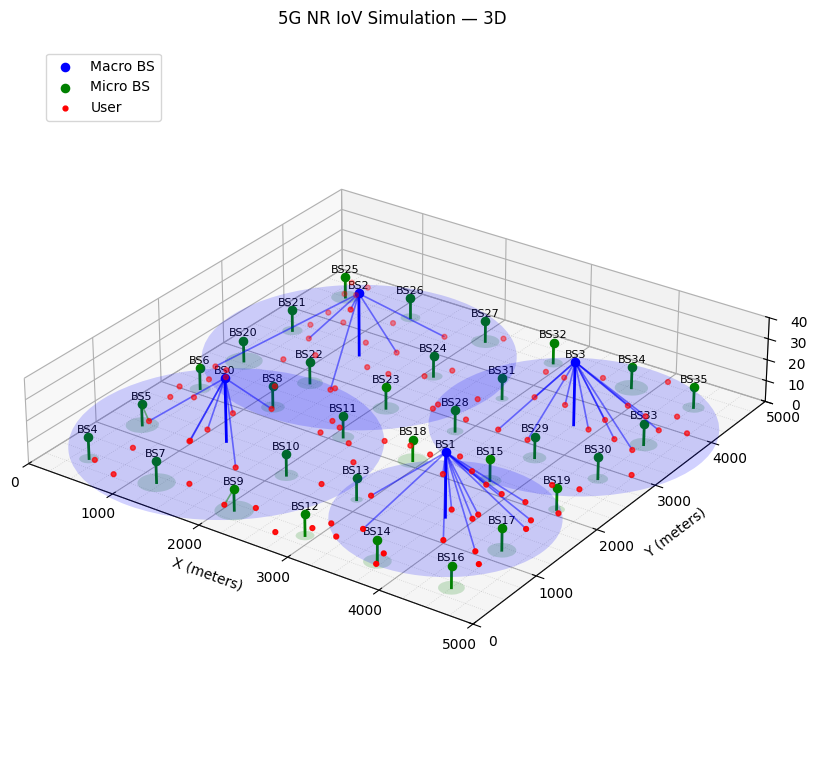

Starting rendering test... (close plot window to stop)


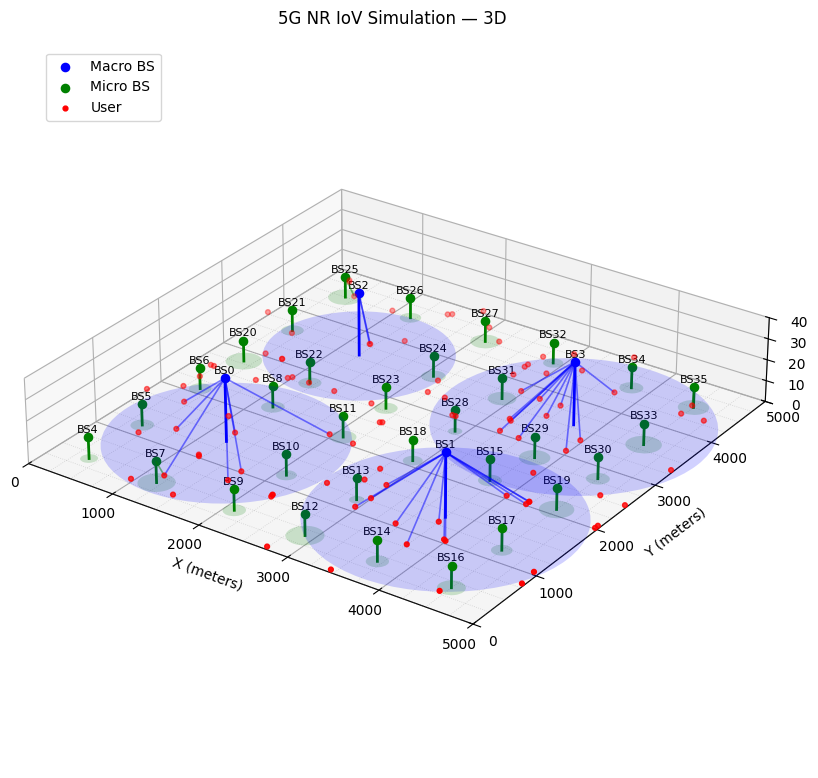

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Finished. Steps=200, Total reward=66.045


In [ ]:
if __name__ == "__main__":
    bs_loc = [(1250, 1400), (3750, 1400), (1250, 3550), (3750, 3550)]

    env = MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=265,
        area_size=5000,
        bs_loc=[
            (1250,1400), (3750,1400), (1250,3550), (3750,3550),
            (400,400), (400,1200), (400,2100), (1200,400), (1200,2200),
            (2100,400), (2100,1200), (2100,2100), (2900,400), (2900,1200),
            (3700,400), (3700,2200), (4500,400), (4500,1200), (2900,2100),
            (4500,2100), (400,2800), (400,3600), (1200,2800), (2100,2800),
            (2100,3600), (400,4500), (1200,4500), (2100,4500), (2900,2800),
            (3800,2800), (4500,2800), (2900,3600), (2900,4500), (4500,3600),
            (3800,4500), (4500,4500)
        ],
        mobility_model="manhattan", road_spacing=250.0, v_mean=12.0, v_std=3.0, stop_prob=0.05, max_stop_steps=3
    )

    obs, _ = env.reset()
    done = False
    total_reward = 0.0
    step = 0

    print("Starting rendering test... (close plot window to stop)")

    try:
        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)

            env.render()          # draw the frame
            plt.pause(0.01)       # let the UI update

            total_reward += reward
            step += 1
            done = terminated or truncated
        print(f"Finished. Steps={step}, Total reward={total_reward:.3f}")
    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        env.close()

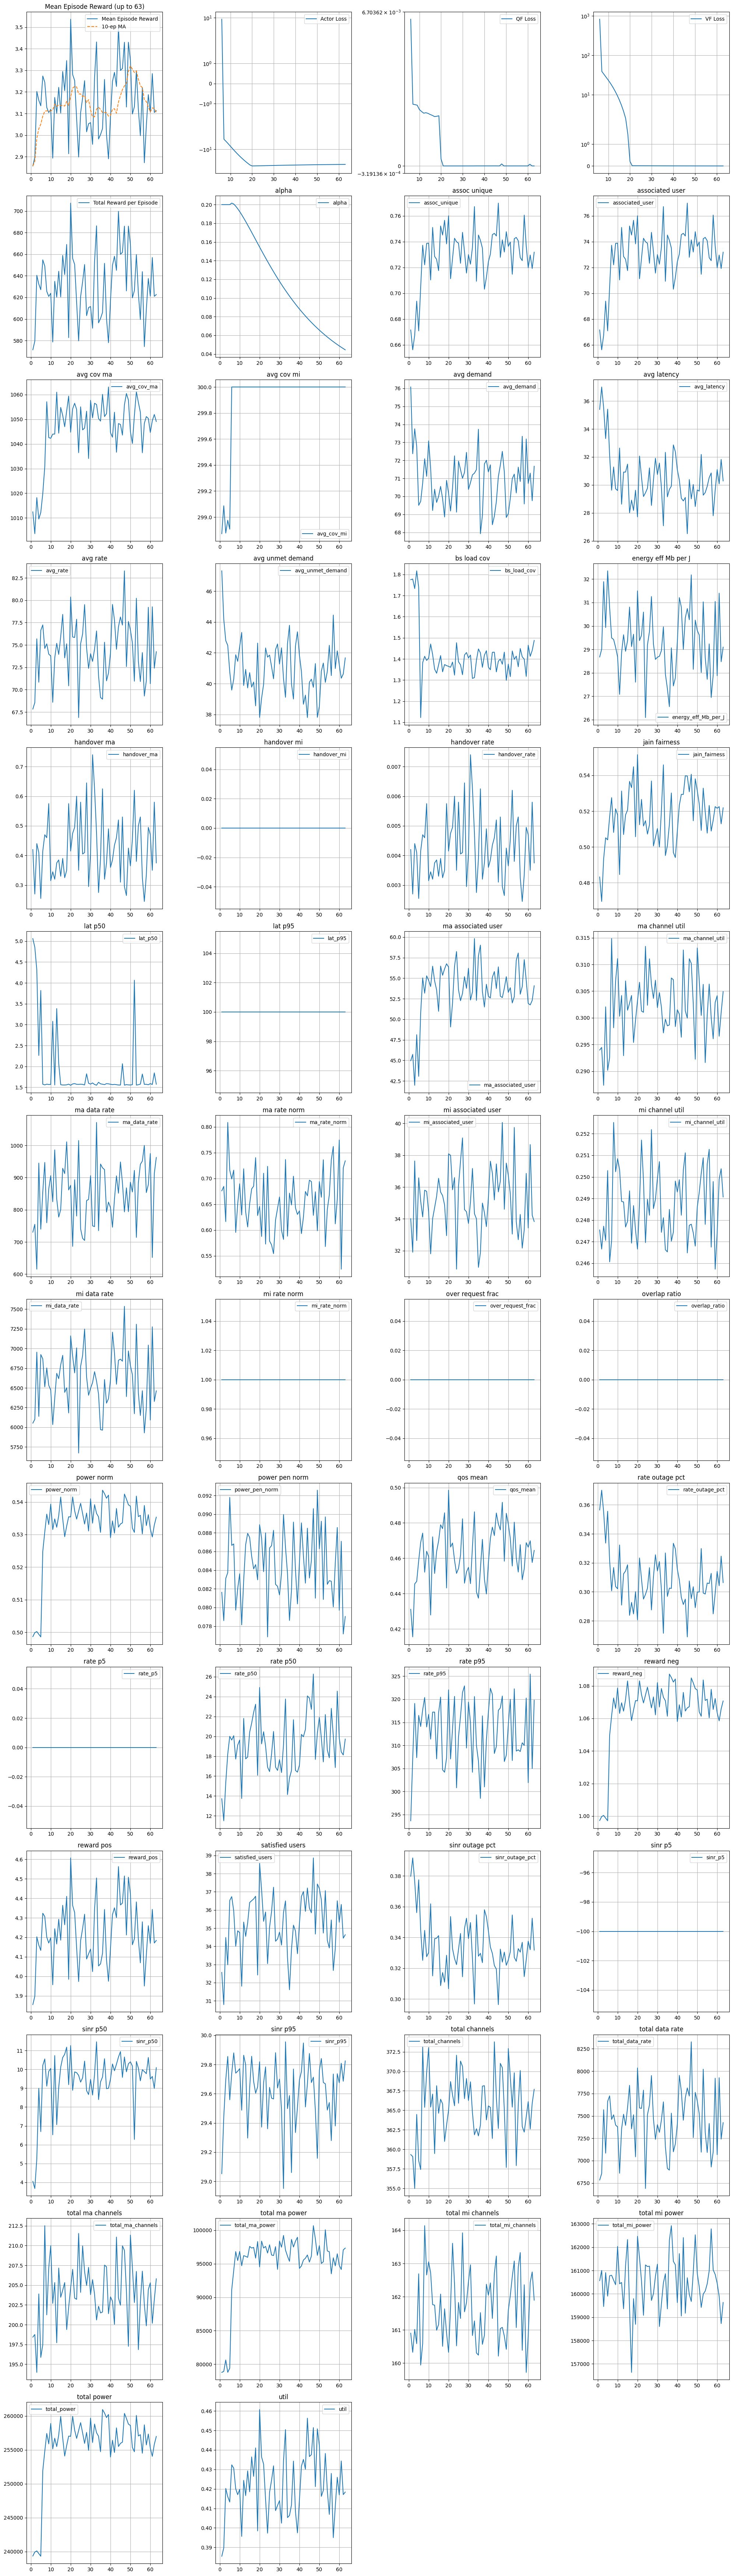

In [ ]:

# =========================
# Replay buffer & ENGNN-SAC
# =========================

class ReplayBuffer:
    def __init__(self, num_nodes: int, node_feature_dim: int, act_dim: int, size: int, batch_size: int = 256):
        self.node_features_buf = np.zeros([size, num_nodes, node_feature_dim], dtype=np.float32)
        self.next_node_features_buf = np.zeros([size, num_nodes, node_feature_dim], dtype=np.float32)
        self.acts_buf = np.zeros([size, act_dim], dtype=np.float32)
        self.rews_buf = np.zeros([size], dtype=np.float32)
        self.term_buf = np.zeros([size], dtype=np.float32)
        self.timeout_buf = np.zeros([size], dtype=np.float32)
        self.max_size, self.batch_size = size, batch_size
        self.ptr, self.size = 0, 0
        self.num_nodes = num_nodes
        self.node_feature_dim = node_feature_dim
        self.action_dim = act_dim

    def store(self, node_features: np.ndarray, act: np.ndarray, rew: float,
              next_node_features: np.ndarray, term: bool, timeout: bool):
        assert node_features.shape == (self.num_nodes, self.node_feature_dim)
        assert next_node_features.shape == (self.num_nodes, self.node_feature_dim)
        assert act.shape == (self.action_dim,)
        self.node_features_buf[self.ptr] = node_features
        self.next_node_features_buf[self.ptr] = next_node_features
        self.acts_buf[self.ptr] = act
        self.rews_buf[self.ptr] = rew
        self.term_buf[self.ptr] = float(term)
        self.timeout_buf[self.ptr] = float(timeout)
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self) -> dict:
        idxs = np.random.choice(self.size, size=self.batch_size, replace=False)
        return dict(
            node_features=self.node_features_buf[idxs],
            next_node_features=self.next_node_features_buf[idxs],
            acts=self.acts_buf[idxs],
            rews=self.rews_buf[idxs],
            term=self.term_buf[idxs],
            timeout=self.timeout_buf[idxs],
        )

    def __len__(self) -> int:
        return self.size


def init_layer_uniform(layer: nn.Linear, init_w: float = 3e-3) -> nn.Linear:
    layer.weight.data.uniform_(-init_w, init_w)
    layer.bias.data.uniform_(-init_w, init_w)
    return layer


# --------- ENGNN blocks (edge-updated MetaLayer) ----------

class _EdgeModel(nn.Module):
    def __init__(self, node_in, edge_in, hid=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(node_in*2 + edge_in, hid), nn.ReLU(),
            nn.Linear(hid, edge_in)
        )
    def forward(self, src, dst, edge_attr, u, batch):
        return edge_attr + self.mlp(torch.cat([src, dst, edge_attr], dim=-1))

class _NodeModel(nn.Module):
    def __init__(self, node_in, edge_in, hid=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(node_in + edge_in, hid), nn.ReLU(),
            nn.Linear(hid, node_in)
        )
    def forward(self, x, edge_index, edge_attr, u, batch):
        # edge_index: [2, E] with row=src, col=dst (PyG convention).
        row, col = edge_index
        m = edge_attr
        # Aggregate messages to the **destination** nodes (col).
        agg = scatter(m, col, dim=0, reduce='mean', dim_size=x.size(0))
        return x + self.mlp(torch.cat([x, agg], dim=-1))

class _ENGNNBlock(nn.Module):
    def __init__(self, node_dim, edge_dim):
        super().__init__()
        self.layer = MetaLayer(_EdgeModel(node_dim, edge_dim),
                               _NodeModel(node_dim, edge_dim), None)
        self.nx = nn.LayerNorm(node_dim)
        self.ne = nn.LayerNorm(edge_dim)
    def forward(self, x, edge_index, edge_attr, batch):
        x2, e2, _ = self.layer(x, edge_index, edge_attr, u=None, batch=batch)
        return self.nx(x2), self.ne(e2)

class ENGNNActor(nn.Module):
    def __init__(self, node_in, edge_in, out_dim_per_node, blocks=2, log_std_min=-20, log_std_max=2):
        super().__init__()
        self.x_proj = nn.Linear(node_in, 64)
        self.e_proj = nn.Linear(edge_in, 32)
        self.blocks = nn.ModuleList([_ENGNNBlock(64, 32) for _ in range(blocks)])
        self.mu = init_layer_uniform(nn.Linear(64, out_dim_per_node))
        self.ls = init_layer_uniform(nn.Linear(64, out_dim_per_node))
        self.log_std_min, self.log_std_max = log_std_min, log_std_max

    def forward(self, data: Data):
        x, ei, ea, b = data.x, data.edge_index, data.edge_attr, data.batch
        x = F.relu(self.x_proj(x)); ea = F.relu(self.e_proj(ea))
        for bl in self.blocks:
            x, ea = bl(x, ei, ea, b)
        mu = self.mu(x)
        log_std = self.ls(x).tanh()
        log_std = self.log_std_min + 0.5*(self.log_std_max - self.log_std_min)*(log_std + 1)
        std = torch.exp(log_std).clamp(1e-6, 1e6)
        dist = torch.distributions.Normal(mu, std)
        z = dist.rsample(); a = torch.tanh(z.clamp(-10, 10))
        eps = 1e-6
        logp = dist.log_prob(z) - torch.log((1 - a.pow(2)).clamp(min=eps))
        logp = scatter(logp.sum(-1, keepdim=True), b, dim=0, reduce='sum')
        return a, logp

class ENGNNQ(nn.Module):
    def __init__(self, node_in, edge_in, act_dim_per_node, blocks=2):
        super().__init__()
        self.x_proj = nn.Linear(node_in + act_dim_per_node, 64)
        self.e_proj = nn.Linear(edge_in, 32)
        self.blocks = nn.ModuleList([_ENGNNBlock(64, 32) for _ in range(blocks)])
        self.out = init_layer_uniform(nn.Linear(64, 1))

    def forward(self, data: Data, action: torch.Tensor):
        x, ei, ea, b = data.x, data.edge_index, data.edge_attr, data.batch
        if action.dim() == 3: action = action.view(-1, action.size(-1))
        x = torch.cat([x, action], dim=-1)
        x = F.relu(self.x_proj(x)); ea = F.relu(self.e_proj(ea))
        for bl in self.blocks:
            x, ea = bl(x, ei, ea, b)
        v = self.out(x)
        return scatter(v, b, dim=0, reduce='mean')

class ENGNNV(nn.Module):
    def __init__(self, node_in, edge_in, blocks=2):
        super().__init__()
        self.x_proj = nn.Linear(node_in, 64)
        self.e_proj = nn.Linear(edge_in, 32)
        self.blocks = nn.ModuleList([_ENGNNBlock(64, 32) for _ in range(blocks)])
        self.out = init_layer_uniform(nn.Linear(64, 1))

    def forward(self, data: Data):
        x, ei, ea, b = data.x, data.edge_index, data.edge_attr, data.batch
        x = F.relu(self.x_proj(x)); ea = F.relu(self.e_proj(ea))
        for bl in self.blocks:
            x, ea = bl(x, ei, ea, b)
        v = self.out(x)
        return scatter(v, b, dim=0, reduce='mean')


class SACAgent:
    def __init__(self, env, bs_loc, memory_size, batch_size,
                 learning_rate=3e-4, gamma=0.99, tau=0.005,
                 initial_random_steps=3000, policy_update_freq=2, seed=42, n_neighbors: int = 6):
        self.env = env
        self.bs_loc = np.array(bs_loc, dtype=np.float32)
        obs_shape = env.observation_space.shape
        self.num_nodes = obs_shape[0]
        self.raw_node_feature_dim = obs_shape[1]  # 13 from env
        # + type one-hot (Ma/Mi)
        self.node_feature_dim = self.raw_node_feature_dim + 2
        # Edge features: distance, same_freq, Ma-Ma, Mi-Mi, tx_diff, inter_avg
        self.edge_feat_dim = 6
        self.action_dim_per_node = env.action_space.shape[1]
        self.action_dim = self.num_nodes * self.action_dim_per_node
        self.action_shape = env.action_space.shape
        self.n_neighbors = max(2, int(n_neighbors))

        self.memory = ReplayBuffer(self.num_nodes, self.raw_node_feature_dim, self.action_dim, memory_size, batch_size)
        self.batch_size = batch_size
        self.gamma = gamma
        self.tau = tau
        self.initial_random_steps = initial_random_steps
        self.policy_update_freq = policy_update_freq
        self.seed = seed

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.use_amp = (self.device.type == "cuda")
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass
        try:
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        except Exception:
            pass

        self.amp_dtype = (torch.bfloat16 if (self.device.type == "cuda" and torch.cuda.is_bf16_supported())
                          else torch.float16)
        if self.use_amp and _AMP_HAS_DEVICE_ARG:
            self.scaler = TorchGradScaler(device="cuda", enabled=True)
        else:
            self.scaler = TorchGradScaler(enabled=self.use_amp)

        def _amp_cm(enabled=True, dtype=self.amp_dtype):
            if not enabled:
                return nullcontext()
            if _AMP_HAS_DEVICE_ARG:
                return autocast(device_type="cuda", dtype=dtype, enabled=True)
            try:
                return autocast(enabled=True, dtype=dtype)
            except TypeError:
                return autocast(enabled=True)
        self._amp_cm = _amp_cm

        self.auto_alpha = True
        init_alpha = 0.2
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(init_alpha, device=self.device)), requires_grad=True)
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=learning_rate)
        self.target_entropy = -0.10 * (self.num_nodes * self.action_dim_per_node)

        # ---- Swap in ENGNN (edge-aware) actor/critics ----
        self.actor = ENGNNActor(self.node_feature_dim, self.edge_feat_dim,
                                self.action_dim_per_node, blocks=2).to(self.device)
        self.vf    = ENGNNV(self.node_feature_dim, self.edge_feat_dim, blocks=2).to(self.device)
        self.vf_target = ENGNNV(self.node_feature_dim, self.edge_feat_dim, blocks=2).to(self.device)
        self.vf_target.load_state_dict(self.vf.state_dict())
        self.vf_target.eval()
        for p in self.vf_target.parameters():
            p.requires_grad = False

        self.qf_1  = ENGNNQ(self.node_feature_dim, self.edge_feat_dim, self.action_dim_per_node, blocks=2).to(self.device)
        self.qf_2  = ENGNNQ(self.node_feature_dim, self.edge_feat_dim, self.action_dim_per_node, blocks=2).to(self.device)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=learning_rate)
        self.vf_optimizer = optim.Adam(self.vf.parameters(), lr=learning_rate)
        self.qf_1_optimizer = optim.Adam(self.qf_1.parameters(), lr=learning_rate)
        self.qf_2_optimizer = optim.Adam(self.qf_2.parameters(), lr=learning_rate)

        self.transition = list()
        self.total_step = 0
        self.is_test = False
        self.episode_rewards = []
        self.episode_actor_losses = []
        # keep also Q/V/alpha losses
        self.episode_qf_losses = []
        self.episode_vf_losses = []
        self.episode_alpha_losses = []
        self.temp_metrics = dd2(list)
        self.episode_metrics = dd2(list)
        self.episode_steps = []
        self.episode_updates = []

        self.static_edge_index = self._compute_edge_index()

        one_hot = np.zeros((self.num_nodes, 2), dtype=np.float32)
        for i, bs in enumerate(self.env.base_stations):
            one_hot[i] = [1, 0] if bs.type_bs == 'Ma' else [0, 1]
        self.type_features = torch.from_numpy(one_hot).to(self.device)

        self.updates_started = False

    def _compute_edge_index(self):
        n = self.num_nodes
        if n <= 1:
            edge_list = [[0, 0]]
        elif n == 2:
            edge_list = [[0, 1], [1, 0]]
        else:
            n_nbrs = min(self.n_neighbors, n)
            nbrs = NearestNeighbors(n_neighbors=n_nbrs, algorithm='ball_tree').fit(self.bs_loc)
            _, indices = nbrs.kneighbors(self.bs_loc)
            edge_list = []
            for i in range(n):
                js = indices[i][1:] if indices[i].size > 1 else []
                for j in js:
                    edge_list.append([i, j]); edge_list.append([j, i])
            if not edge_list:
                for i in range(n):
                    j = (i + 1) % n
                    edge_list.append([i, j]); edge_list.append([j, i])
        return torch.tensor(edge_list, dtype=torch.long).t().contiguous().to(self.device)

    # ---------- Edge features for ENGNN ----------
    def _edge_features(self, obs: np.ndarray) -> torch.Tensor:
        # node-wise from obs
        tx_norm    = torch.as_tensor(obs[:, OBS_IDX.TX_NORM], dtype=torch.float32, device=self.device)
        inter_norm = torch.as_tensor(obs[:, OBS_IDX.INTER_NORM], dtype=torch.float32, device=self.device)
        types01    = self.type_features  # N x 2: [Ma, Mi]
        freqs = torch.as_tensor([self.env.bs_carrier_frequency[i] for i in range(self.num_nodes)],
                                dtype=torch.float32, device=self.device)
        # geometry
        xy = torch.as_tensor(self.bs_loc, dtype=torch.float32, device=self.device)
        src, dst = self.static_edge_index
        d = (xy[src] - xy[dst]).pow(2).sum(-1).sqrt()            # E
        d_norm = (d / 1000.0).clamp(0, 1)
        same_f = (freqs[src] == freqs[dst]).float()
        pair_ma = (types01[src, 0] * types01[dst, 0]).float()
        pair_mi = (types01[src, 1] * types01[dst, 1]).float()
        tx_diff = (tx_norm[src] - tx_norm[dst]).abs()
        inter_avg = 0.5*(inter_norm[src] + inter_norm[dst])
        return torch.stack([d_norm, same_f, pair_ma, pair_mi, tx_diff, inter_avg], dim=-1)  # E x 6

    def create_graph_data(self, obs, add_batch: bool = False):
        if np.any(np.isnan(obs)):
            obs = np.nan_to_num(obs, nan=0.0)
        x_obs = torch.as_tensor(obs, dtype=torch.float32, device=self.device)
        x = torch.cat([x_obs, self.type_features], dim=1)
        data = Data(x=x, edge_index=self.static_edge_index, edge_attr=self._edge_features(obs))
        if add_batch:
            data.batch = torch.zeros(self.num_nodes, dtype=torch.long, device=self.device)
        return data

    @staticmethod
    def _scale_env_action(a_raw: torch.Tensor) -> torch.Tensor:
        low, high = 0.001, 1.0
        return low + (high - low) * (a_raw + 1.0) / 2.0

    def _apply_power_floor_tensor(self, a_env: torch.Tensor, data):
        """
        Clamp actions to avoid starving busy cells:
        - Power floor tied to required power estimate (obs[REQ_P_NORM]).
        - Channel fraction floor tied to coverage utilization (obs[COV_UTIL]).
        - Channel fraction **upper** cap tied to interference (obs[INTER_NORM]).
        NOTE: channel fraction is not used to count channels; it remains as a hint feature.
        """
        # NOTE: data.x is [obs(13) | type_onehot(2)]. OBS_IDX refer to obs slots.
        req_p_norm = data.x[:, OBS_IDX.REQ_P_NORM:OBS_IDX.REQ_P_NORM+1].clamp(0, 1)
        cov_util   = data.x[:, OBS_IDX.COV_UTIL:OBS_IDX.COV_UTIL+1].clamp(0, 1)
        inter_norm = data.x[:, OBS_IDX.INTER_NORM:OBS_IDX.INTER_NORM+1].clamp(0, 1)

        # Power at least 80% of required (plus tiny absolute floor)
        p_floor = torch.maximum(torch.full_like(req_p_norm, 0.05), 0.8 * req_p_norm)
        p = torch.maximum(a_env[:, 0:1], p_floor)

        # Channel fraction scales with coverage utilization; upper cap decays with interference
        ch_floor = (0.05 + 0.6 * cov_util).clamp(0.05, 0.8)
        ch_upper = (1.0 - 0.5 * inter_norm).clamp(0.3, 1.0)
        ch = torch.minimum(torch.maximum(a_env[:, 1:2], ch_floor), ch_upper)

        return torch.cat([p, ch], dim=-1)

    def select_action(self, state: np.ndarray) -> np.ndarray:
        if self.total_step < self.initial_random_steps and not self.is_test:
            action = self.env.action_space.sample()
            action_flat = action.flatten()
        else:
            was_training = self.actor.training
            self.actor.eval()
            with torch.no_grad():
                data = self.create_graph_data(state, add_batch=True)
                a_raw, _ = self.actor(data)
                a_env = self._scale_env_action(a_raw)
                a_env = self._apply_power_floor_tensor(a_env, data)
                action_flat = a_env.detach().cpu().numpy().reshape(-1)
            if was_training and not self.is_test:
                self.actor.train()
        self.transition = [state, action_flat]
        return action_flat.reshape(self.action_shape)

    def step(self, action: np.ndarray):
        # Get the raw env reward (env clips to [-10, 10])
        next_state, env_reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated

        # Use a scaled reward only for learning stability
        reward_scaled = env_reward / 10.0

        if not self.is_test:
            action_flat = action.flatten()
            # store scaled reward in replay
            self.transition += [reward_scaled, next_state, done]
            self.memory.store(self.transition[0], action_flat, reward_scaled,
                              next_state, terminated, truncated)
            # collect metrics for CSV/plots
            for k, v in info.items():
                self.temp_metrics[k].append(v)
            # track temperature (alpha)
            self.temp_metrics['alpha'].append(float(self.log_alpha.exp().detach().cpu().item()))

        # Return UNscaled reward so episode totals/CSV remain on the env scale
        return next_state, env_reward, done, info


    def update_model(self):
        device = self.device
        samples = self.memory.sample_batch()

        action = torch.FloatTensor(samples["acts"]).to(device).view(-1, self.num_nodes, self.action_dim_per_node)
        reward = torch.FloatTensor(samples["rews"]).to(device).reshape(-1, 1)
        term   = torch.FloatTensor(samples["term"]).to(device).reshape(-1, 1)
        not_terminal = 1.0 - term  # bootstrap across time-limit truncations

        data_list      = [self.create_graph_data(obs, add_batch=False) for obs in samples["node_features"]]
        next_data_list = [self.create_graph_data(obs, add_batch=False) for obs in samples["next_node_features"]]
        batch      = Batch.from_data_list(data_list).to(device)
        next_batch = Batch.from_data_list(next_data_list).to(device)

        with self._amp_cm(enabled=self.use_amp):
            with torch.no_grad():
                v_target = self.vf_target(next_batch)
                q_target = reward + self.gamma * v_target * not_terminal
                q_target = q_target.clamp(-50.0, 50.0)

        with self._amp_cm(enabled=self.use_amp):
            q1_pred = self.qf_1(batch, action)
            q2_pred = self.qf_2(batch, action)
            qf_loss = F.smooth_l1_loss(q1_pred, q_target) + F.smooth_l1_loss(q2_pred, q_target)

        self.qf_1_optimizer.zero_grad()
        self.qf_2_optimizer.zero_grad()
        self.scaler.scale(qf_loss).backward()
        self.scaler.unscale_(self.qf_1_optimizer)
        self.scaler.unscale_(self.qf_2_optimizer)
        torch.nn.utils.clip_grad_norm_(self.qf_1.parameters(), 5.0)
        torch.nn.utils.clip_grad_norm_(self.qf_2.parameters(), 5.0)
        self.scaler.step(self.qf_1_optimizer)
        self.scaler.step(self.qf_2_optimizer)

        actor_loss = torch.tensor(0.0, device=device)
        vf_loss    = torch.tensor(0.0, device=device)
        alpha_loss = torch.tensor(0.0, device=device)

        if self.total_step % max(1, self.policy_update_freq) == 0:
            with self._amp_cm(enabled=self.use_amp):
                new_action_raw, log_prob = self.actor(batch)
                log_prob = torch.nan_to_num(log_prob, nan=0.0, posinf=0.0, neginf=0.0)

                new_action_env = self._scale_env_action(new_action_raw)
                new_action_env = self._apply_power_floor_tensor(new_action_env, batch)

                alpha_const = self.log_alpha.exp().detach()
                q_pi = torch.min(self.qf_1(batch, new_action_env), self.qf_2(batch, new_action_env))
                actor_loss = (alpha_const * log_prob - q_pi).mean()

            self.actor_optimizer.zero_grad()
            self.scaler.scale(actor_loss).backward()
            self.scaler.unscale_(self.actor_optimizer)
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 5.0)
            self.scaler.step(self.actor_optimizer)

            if self.auto_alpha:
                with self._amp_cm(enabled=self.use_amp):
                    alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
                self.alpha_optimizer.zero_grad()
                self.scaler.scale(alpha_loss).backward()
                self.scaler.step(self.alpha_optimizer)
                with torch.no_grad():
                    self.log_alpha.clamp_(min=np.log(1e-4), max=np.log(10.0))

            was_q1, was_q2 = self.qf_1.training, self.qf_2.training
            was_act = self.actor.training
            self.qf_1.eval(); self.qf_2.eval(); self.actor.eval()
            with self._amp_cm(enabled=self.use_amp):
                v_pred = self.vf(batch)
                with torch.no_grad():
                    na_raw, lp = self.actor(batch)
                    na_env = self._scale_env_action(na_raw)
                    na_env = self._apply_power_floor_tensor(na_env, batch)
                    q_pi_detached = torch.min(self.qf_1(batch, na_env), self.qf_2(batch, na_env))
                    v_tgt2 = q_pi_detached - self.log_alpha.exp().detach() * lp
                vf_loss = F.mse_loss(v_pred, v_tgt2)
            self.qf_1.train(was_q1); self.qf_2.train(was_q2)
            if was_act: self.actor.train()

            self.vf_optimizer.zero_grad()
            self.scaler.scale(vf_loss).backward()
            self.scaler.unscale_(self.vf_optimizer)
            torch.nn.utils.clip_grad_norm_(self.vf.parameters(), 5.0)
            self.scaler.step(self.vf_optimizer)

        self.scaler.update()
        self._target_soft_update()

        return actor_loss.detach(), qf_loss.detach(), vf_loss.detach(), alpha_loss.detach()

    def train(self, num_frames: int, plotting_interval: int = 200, close_env_on_train_end: bool = False):
        self.is_test = False
        state, _ = self.env.reset()
        score = 0
        actor_losses = []; qf_losses = []; vf_losses = []; alpha_losses = []
        episode_count = 0
        current_episode_steps = 0
        episode_update_count = 0

        info_keys = [
            'total_data_rate','ma_data_rate','mi_data_rate','avg_rate',
            'total_power','total_ma_power','total_mi_power','energy_eff_Mb_per_J',
            'total_channels','total_ma_channels','total_mi_channels',
            'ma_channel_util','mi_channel_util',
            'associated_user','ma_associated_user','mi_associated_user',
            'avg_latency','lat_p50','lat_p95',
            'satisfied_users','avg_unmet_demand',
            'avg_demand',
            'sinr_p5','sinr_p50','sinr_p95',
            'rate_p5','rate_p50','rate_p95',
            'sinr_outage_pct','rate_outage_pct',
            'bs_load_cov',
            'avg_cov_ma','avg_cov_mi',
            'handover_rate','handover_ma','handover_mi',
            'overlap_ratio',
            'ma_rate_norm','mi_rate_norm','assoc_unique',
            # Agent-side scalar
            'alpha',
            # Reward diagnostics
            'qos_mean','jain_fairness','util','power_norm','reward_pos','reward_neg','over_request_frac','power_pen_norm'
        ]

        csv_path = "training_log.csv"
        with open(csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            header = ["Episode","Window10Avg","Total Reward","Steps","Updates","Actor Loss","QF Loss","VF Loss","Alpha Loss"] + info_keys
            writer.writerow(header)

            for self.total_step in range(1, num_frames + 1):
                action = self.select_action(state)
                next_state, reward, done, info = self.step(action)
                state = next_state
                score += reward
                current_episode_steps += 1

                if len(self.memory) >= self.batch_size and self.total_step > self.initial_random_steps:
                    if not self.updates_started:
                        print(f"Updates started at step {self.total_step}, buffer size: {len(self.memory)}")
                        self.updates_started = True
                    losses = self.update_model()
                    actor_losses.append(float(losses[0]))
                    qf_losses.append(float(losses[1]))
                    vf_losses.append(float(losses[2]))
                    alpha_losses.append(float(losses[3]))
                    episode_update_count += 1

                if done:
                    episode_count += 1
                    actor_loss_avg = float(np.mean(actor_losses)) if actor_losses else np.nan
                    qf_loss_avg = float(np.mean(qf_losses)) if qf_losses else np.nan
                    vf_loss_avg = float(np.mean(vf_losses)) if vf_losses else np.nan
                    alpha_loss_avg = float(np.mean(alpha_losses)) if alpha_losses else np.nan
                    self.episode_actor_losses.append(actor_loss_avg)
                    self.episode_qf_losses.append(qf_loss_avg)
                    self.episode_vf_losses.append(vf_loss_avg)
                    self.episode_alpha_losses.append(alpha_loss_avg)
                    self.episode_rewards.append(score)
                    self.episode_steps.append(current_episode_steps)
                    self.episode_updates.append(episode_update_count)
                    for key in self.temp_metrics:
                        if key != 'rewards':
                            self.episode_metrics[key].append(
                                float(np.mean(self.temp_metrics[key])) if self.temp_metrics[key] else np.nan
                            )

                    print(f"Episode {episode_count}: Reward={score:.2f}, Steps={current_episode_steps}, Updates={episode_update_count}, "
                          f"Actor={actor_loss_avg:.6f}, QF={qf_loss_avg:.6f}, VF={vf_loss_avg:.6f}, Alpha={alpha_loss_avg:.6f}")

                    row = [
                        episode_count, 0, score, current_episode_steps, episode_update_count,
                        actor_loss_avg, qf_loss_avg, vf_loss_avg, alpha_loss_avg
                    ] + [
                        (self.episode_metrics[key][-1] if key in self.episode_metrics and self.episode_metrics[key]
                         else np.nan)
                        for key in info_keys
                    ]
                    writer.writerow(row)
                    f.flush()

                    if len(self.episode_rewards) >= 10 and (episode_count % 10 == 0):
                        window = slice(-10, None)
                        avg_reward_10 = float(np.mean(self.episode_rewards[window]))
                        avg_steps_10 = float(np.mean(self.episode_steps[window]))
                        avg_updates_10 = float(np.mean(self.episode_updates[window]))
                        avg_actor_10 = float(np.nanmean(self.episode_actor_losses[window]))
                        avg_qf_10 = float(np.nanmean(self.episode_qf_losses[window]))
                        avg_vf_10 = float(np.nanmean(self.episode_vf_losses[window]))
                        avg_alpha_10 = float(np.nanmean(self.episode_alpha_losses[window]))
                        avg_infos_10 = []
                        for key in info_keys:
                            series = self.episode_metrics.get(key, [])
                            if len(series) >= 10:
                                avg_infos_10.append(float(np.nanmean(series[window])))
                            else:
                                avg_infos_10.append(np.nan)

                        summary_row = [
                            episode_count, 1, avg_reward_10, avg_steps_10, avg_updates_10,
                            avg_actor_10, avg_qf_10, avg_vf_10, avg_alpha_10
                        ] + avg_infos_10
                        writer.writerow(summary_row)
                        f.flush()

                    actor_losses.clear(); qf_losses.clear(); vf_losses.clear(); alpha_losses.clear()
                    score = 0; current_episode_steps = 0; episode_update_count = 0
                    state, _ = self.env.reset()
                    self.temp_metrics = dd2(list)

                if self.total_step % plotting_interval == 0:
                    self._plot(self.total_step, save=False)

            if len(self.episode_rewards) >= 10 and (episode_count % 10 != 0):
                window = slice(-10, None)
                avg_reward_10 = float(np.mean(self.episode_rewards[window]))
                avg_steps_10 = float(np.mean(self.episode_steps[window]))
                avg_updates_10 = float(np.mean(self.episode_updates[window]))
                avg_actor_10 = float(np.nanmean(self.episode_actor_losses[window]))
                avg_qf_10 = float(np.nanmean(self.episode_qf_losses[window]))
                avg_vf_10 = float(np.nanmean(self.episode_vf_losses[window]))
                avg_alpha_10 = float(np.nanmean(self.episode_alpha_losses[window]))
                avg_infos_10 = []
                for key in info_keys:
                    series = self.episode_metrics.get(key, [])
                    if len(series) >= 10:
                        avg_infos_10.append(float(np.nanmean(series[window])))
                    else:
                        avg_infos_10.append(np.nan)
                final_summary = [
                    len(self.episode_rewards), 1, avg_reward_10, avg_steps_10, avg_updates_10,
                    avg_actor_10, avg_qf_10, avg_vf_10, avg_alpha_10
                ] + avg_infos_10
                writer.writerow(final_summary)
                f.flush()

        self._plot(self.total_step, save=True)
        if close_env_on_train_end:
            self.env.close()

    def _plot(self, frame_idx: int, save: bool = False):
        if not self.episode_rewards:
            return
        if _HAVE_IPY:
            clear_output(True)

        episodes = np.arange(1, len(self.episode_rewards) + 1)
        mean_ep_rewards = [r / max(s, 1) for r, s in zip(self.episode_rewards, self.episode_steps)]

        metric_names = sorted([k for k, v in self.episode_metrics.items() if len(v) == len(self.episode_rewards)])

        n_summary = 5
        n_metrics = len(metric_names)
        total_plots = n_summary + n_metrics
        ncols = 4
        nrows = int(np.ceil(total_plots / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
        axes = np.asarray(axes).reshape(-1)

        ax = axes[0]
        ax.plot(episodes, mean_ep_rewards, label="Mean Episode Reward")
        if len(mean_ep_rewards) >= 10:
            ma = [np.mean(mean_ep_rewards[max(0, i-9):i+1]) for i in range(len(mean_ep_rewards))]
            ax.plot(episodes, ma, linestyle='--', label="10-ep MA")
        ax.set_title(f"Mean Episode Reward (up to {len(self.episode_rewards)})"); ax.legend(); ax.grid(True)

        axes[1].plot(episodes, self.episode_actor_losses, label="Actor Loss"); axes[1].set_yscale('symlog'); axes[1].legend(); axes[1].grid(True)
        axes[2].plot(episodes, self.episode_qf_losses, label="QF Loss");    axes[2].set_yscale('symlog'); axes[2].legend(); axes[2].grid(True)
        axes[3].plot(episodes, self.episode_vf_losses, label="VF Loss");    axes[3].set_yscale('symlog'); axes[3].legend(); axes[3].grid(True)

        axes[4].plot(episodes, self.episode_rewards, label="Total Reward per Episode")
        axes[4].legend(); axes[4].grid(True)

        idx = n_summary
        for name in metric_names:
            ax = axes[idx]
            series = self.episode_metrics[name]
            ax.plot(episodes, series, label=name)
            ax.set_title(name.replace('_',' '))
            ax.legend(); ax.grid(True)
            idx += 1

        for j in range(idx, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        if save:
            plt.savefig("final_training_plot.png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close()

    def test(self, num_episodes: int = 5):
        self.is_test = True
        self.actor.eval(); self.vf.eval(); self.qf_1.eval(); self.qf_2.eval()
        scores = []
        for _ in range(num_episodes):
            state, _ = self.env.reset()
            done = False
            score = 0.0
            while not done:
                action = self.select_action(state)
                next_state, reward, done, _ = self.step(action)
                state = next_state
                score += reward
            scores.append(score)
        print(f"Average score over {num_episodes} episodes: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

    def _target_soft_update(self):
        for t_param, l_param in zip(self.vf_target.parameters(), self.vf.parameters()):
            t_param.data.copy_(self.tau * l_param.data + (1.0 - self.tau) * t_param.data)


def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def create_mobile_network_env():
    return MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=135,
        area_size=5000,
        bs_loc=[
            (1250,1400), (3750,1400), (1250,3550), (3750,3550)
        ],
        mobility_model="manhattan", road_spacing=250.0, v_mean=12.0, v_std=3.0, stop_prob=0.05, max_stop_steps=3
    )


if __name__ == "__main__":
    # Training + Test run
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    seed_torch(seed)

    env = create_mobile_network_env()
    bs_loc = [
        (1250,1400), (3750,1400), (1250,3550), (3750,3550),
        (400,400), (400,1200), (400,2100), (1200,400), (1200,2200),
        (2100,400), (2100,1200), (2100,2100), (2900,400), (2900,1200),
        (3700,400), (3700,2200), (4500,400), (4500,1200), (2900,2100),
        (4500,2100), (400,2800), (400,3600), (1200,2800), (2100,2800),
        (2100,3600), (400,4500), (1200,4500), (2100,4500), (2900,2800),
        (3800,2800), (4500,2800), (2900,3600), (2900,4500), (4500,3600),
        (3800,4500), (4500,4500)
    ]

    agent = SACAgent(
        env=env,
        learning_rate=3e-4,
        bs_loc=bs_loc,
        memory_size=int(1e5),   # trimmed to reduce RAM footprint
        batch_size=256,
        initial_random_steps=1000,
        policy_update_freq=2,
        seed=seed,
        n_neighbors=6
    )
    agent.train(num_frames=100000, plotting_interval=200, close_env_on_train_end=False)
    agent.test(num_episodes=10)
    env.close()

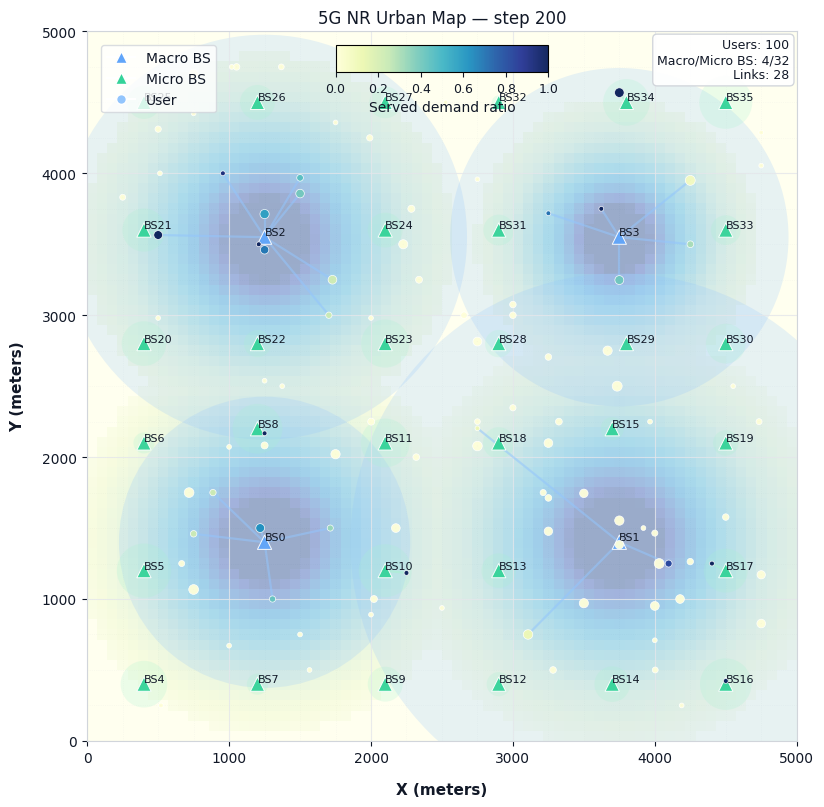

Starting rendering test... (close plot window to stop)


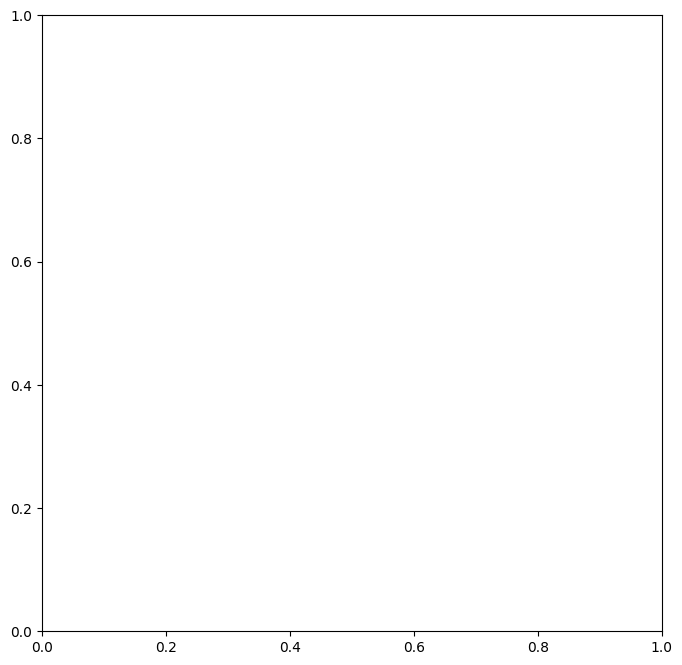

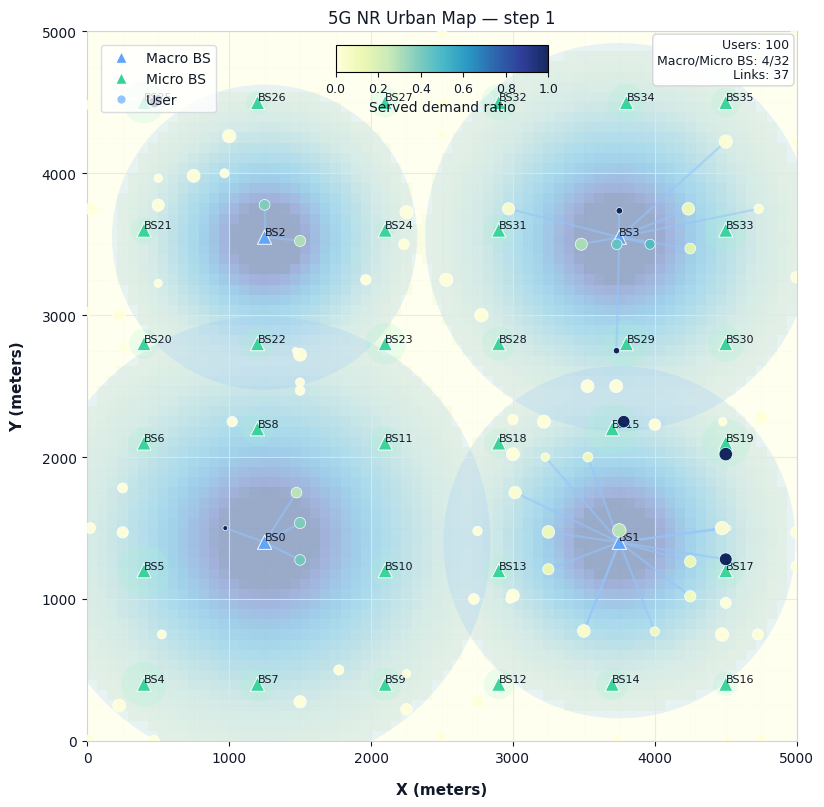

Finished. Steps=200, Total reward=116.404


In [ ]:
import numpy as np
import random
from collections import defaultdict
import warnings
from types import SimpleNamespace

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
try:
    from IPython.display import display
    _HAVE_IPY = True
except Exception:
    _HAVE_IPY = False


# =========================
# 5G/NR PHY HELPERS & PARAMS
# =========================
# 3GPP-style RX sensitivity (dBm): -174 + 10log10(BW) + NF + SNR_req
def rx_sensitivity_dBm(bw_hz, nf_db=7.0, snr_req_db=-5.0):
    return -174.0 + 10.0*np.log10(max(bw_hz, 1.0)) + nf_db + snr_req_db

# --- 256-QAM parameters (NR Rel-15+ compatible) ---
MOD_ORDER = 256
BITS_PER_CODEWORD = int(np.log2(MOD_ORDER))  # 8 bits per symbol/codeword for 256-QAM

# Shannon with SNR gap (linear), gently capped at 256-QAM = 8 b/s/Hz
def spectral_efficiency_from_sinr(SINR_dB, gap_db=1.5, max_se=float(BITS_PER_CODEWORD)):
    """
    Link-to-system: SE ≈ log2(1 + SINR/Γ), capped to 256-QAM's 8 bits/s/Hz.
    Γ (gap) ~ 1.5 dB approximates coding/implementation loss.
    """
    gamma = 10.0**(SINR_dB/10.0) / (10.0**(gap_db/10.0))
    se = np.log2(1.0 + gamma)
    return float(np.clip(se, 0.0, max_se))

# NR physical-layer overhead (PDCCH/DMRS/CSI-RS/guard etc.)
NR_OVERHEAD = 0.85
SNR_GAP_DB = 1.5      # “SNR gap” to Shannon
# IMPORTANT: for strict 256-QAM, cap is exactly 8 b/s/Hz
MAX_SE = float(BITS_PER_CODEWORD)

# Per-tier MIMO max spatial layers (rank)
MIMO_MAX_RANK = {'Ma': 4, 'Mi': 8}

# Simple antenna / beam gains (approximate)
BEAM_GAIN_DB = {
    'Ma': {'tx_main': 8.0,  'tx_side': -3.0, 'rx': 0.0},   # macro panel-ish
    'Mi': {'tx_main': 15.0, 'tx_side': -5.0, 'rx': 7.0},   # mmWave pencil beam-ish
}

# UE-side RX gain used for **interference** accumulation
UE_INTERF_RX_DB = 0.0

# Macro reuse toggle (True => reuse-1 macro interference)
MACRO_REUSE_ONE = False


def mimo_rank_and_total_se(SINR_dB: float, max_layers: int,
                           gap_db: float = SNR_GAP_DB, max_se: float = MAX_SE) -> (int, float):
    """
    Pick MIMO rank (1..max_layers) that maximizes sum-SE assuming equal power split across layers.
    Includes a mild correlation/overhead loss for higher ranks.
    Per-layer SE is capped to 8 b/s/Hz (256-QAM).
    """
    sinr_lin = 10.0**(SINR_dB/10.0)
    best_L, best_sum_se = 1, spectral_efficiency_from_sinr(SINR_dB, gap_db, max_se)
    for L in range(2, max_layers+1):
        # Equal power split: SNR per layer ~ sinr_lin / L
        per_layer_snr_dB = 10.0*np.log10(max(sinr_lin / max(L, 1), 1e-12))
        se_layer = spectral_efficiency_from_sinr(per_layer_snr_dB, gap_db, max_se)
        # Mild degradation for higher ranks (spatial correlation, DMRS overhead, precoder loss)
        corr_eff = max(0.5, 1.0 - 0.07*(L-1))
        sum_se = L * se_layer * corr_eff
        if sum_se > best_sum_se:
            best_sum_se, best_L = sum_se, L
    return best_L, float(best_sum_se)


# ---------- Observation index constants ----------
# Keep these in sync with MobileNetwork.get_observation()
OBS_IDX = SimpleNamespace(
    BS_TYPE=0, TX_NORM=1, CH_UTIL=2, COV_UTIL=3, LOAD_RATIO_NORM=4, NEARBY_POT=5, AVG_SPEED=6,
    REQ_P_NORM=7, AVG_RADIAL_V=8, SP_VAR=9, NEIGHBOR_TX_NORM=10, AVG_DEMAND_NORM=11, INTER_NORM=12
)

# =========================
# ENVIRONMENT
# =========================

class Channel:
    def __init__(self, id, frequency, bandwidth, noise_figure_db=7.0):
        self.id = id
        self.frequency = frequency            # Hz
        self.bandwidth = bandwidth            # Hz
        self.users = []
        self.base_station = None
        self.temperature = 293.15             # K
        self.noise_figure_db = noise_figure_db

    def calculate_noise_power(self):
        """Thermal noise (W) inc. NF: N = kTB * NF."""
        k = 1.38e-23
        N = k * self.temperature * self.bandwidth
        NF = 10.0**(self.noise_figure_db / 10.0)
        return N * NF  # W


class BaseStation:
    def __init__(self, id, transmit_power, height, location, type_bs):
        self.id = id
        self.transmit_power = transmit_power  # mW (total across channels)
        self.height = height
        self.type_bs = type_bs  # 'Ma' (macro) or 'Mi' (micro/mmWave)
        self.location = np.array(location, dtype=float)
        self.users = []
        self.assigned_channels = []  # channels reserved by this BS
        self.coverage_area = 0.0
        self.per_channel_power = {}  # channel_id -> mW (set each step)
        self.MAX_COVERAGE   = {'Ma': 2000.0, 'Mi': 350.0}  # hard cap (tune 250–400 m)
        self.COV_MARGIN_DB  = {'Ma': 3.0,    'Mi': 20.0}   # extra loss for blockage/penumbra
        self.SNR_REQ_DB     = {'Ma': -5.0,   'Mi': +5.0}   # mmWave needs higher SINR at cell edge


    # --- 3GPP TR 38.901 3D-UMa/3D-UMi PL (approximate) ---
    def _pl_uma_los(self, d3d, f_ghz, h_ut=1.5):
        c = 3e8
        f_hz = f_ghz * 1e9
        h_bs = float(self.height)
        d2d = max(np.sqrt(max(d3d**2 - (h_bs - h_ut)**2, 1e-9)), 1.0)
        h_bs_eff = h_bs - 1.0
        h_ut_eff = h_ut - 1.0
        d_bp = 4.0 * h_bs_eff * h_ut_eff * f_hz / c
        pl1 = 28.0 + 22.0*np.log10(d3d) + 20.0*np.log10(f_ghz)
        if d2d <= d_bp:
            return pl1
        pl2 = 28.0 + 40.0*np.log10(d3d) + 20.0*np.log10(f_ghz) - 9.0*np.log10(d_bp**2 + (h_bs - h_ut)**2)
        return pl2

    def _pl_uma_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=h_ut)
        pl_nlos = 13.54 + 39.08*np.log10(d3d) + 20.0*np.log10(f_ghz) - 0.6*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _pl_umi_los(self, d3d, f_ghz):
        return 32.4 + 21.0*np.log10(f_ghz) + 20.0*np.log10(d3d)

    def _pl_umi_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_umi_los(d3d, f_ghz)
        pl_nlos = 22.4 + 35.3*np.log10(d3d) + 21.3*np.log10(f_ghz) - 0.3*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _eirp_dbm(self, transmit_power_mW: float) -> float:
        g = BEAM_GAIN_DB[self.type_bs]
        tx_dbm = 10.0*np.log10(max(transmit_power_mW, 1e-15))
        return tx_dbm + g['tx_main'] + g['rx']

    def calculate_path_loss(self, distance, frequency, user_height=1.5):
        d2d = max(float(distance), 0.1)
        f_ghz = frequency / 1e9
        d3d = np.sqrt(d2d**2 + (self.height - user_height)**2)

        if self.type_bs == 'Ma':
            # UMa
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 63.0)) + np.exp(-d2d / 63.0)
            pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=user_height)
            pl_nlos = self._pl_uma_nlos(d3d, f_ghz, h_ut=user_height)
        else:
            # UMi / mmWave-ish
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 36.0)) + np.exp(-d2d / 36.0)
            pl_los = self._pl_umi_los(d3d, f_ghz)
            pl_nlos = self._pl_umi_nlos(d3d, f_ghz, h_ut=user_height)

        return float(p_los * pl_los + (1.0 - p_los) * pl_nlos)


    def update_coverage_area_from_power(self, transmit_power_mW, frequency_hz):
        if self.per_channel_power:
            p_list = list(self.per_channel_power.values())
            p_ch = float(np.percentile(p_list, 80))  # or np.median(p_list) for a tighter cell
        else:
            p_ch = transmit_power_mW / max(len(self.assigned_channels), 1)

        if self.assigned_channels:
            bw_hz = self.assigned_channels[0].bandwidth
            nf_db = self.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if self.type_bs == 'Ma' else 200e6
            nf_db = 7.0

        # tougher cell-edge for Mi
        sens_dBm = rx_sensitivity_dBm(
            bw_hz,
            nf_db=nf_db,
            snr_req_db=self.SNR_REQ_DB[self.type_bs]
        )

        # your helper currently adds TX+RX gains; keep it but subtract a coverage margin
        eirp_plus_grx_dbm = self._eirp_dbm(p_ch)
        path_loss_budget_dB = eirp_plus_grx_dbm - sens_dBm - self.COV_MARGIN_DB[self.type_bs]

        self.coverage_area = self.find_distance_for_path_loss(path_loss_budget_dB, frequency_hz)

        cap = self.MAX_COVERAGE.get(self.type_bs, None)
        if cap is not None:
            self.coverage_area = min(self.coverage_area, float(cap))
        return self.coverage_area




    def find_distance_for_path_loss(self, path_loss_dB, frequency):
        d_min, d_max = 1.0, 10000.0
        tol = 0.1
        for _ in range(30):
            d_mid = 0.5*(d_min + d_max)
            PL_mid = self.calculate_path_loss(d_mid, frequency)
            if abs(PL_mid - path_loss_dB) < tol:
                return d_mid
            if PL_mid < path_loss_dB:
                d_min = d_mid
            else:
                d_max = d_mid
        return d_mid

    def assign_channels(self, num_channels, available_channels):
        num_channels = min(num_channels, len(available_channels))
        self.assigned_channels = available_channels[:num_channels]
        for ch in self.assigned_channels:
            ch.base_station = self

    def clear_assigned_channels(self):
        self.assigned_channels = []
        self.per_channel_power = {}

    def find_available_channel(self):
        for ch in self.assigned_channels:
            if len(ch.users) == 0:
                return ch
        return None

    def assign_channel_to_user(self, user):
        ch = self.find_available_channel()
        if ch:
            user.channel.append(ch)
            ch.users.append(user)


class User:
    def __init__(self, id, location, velocity, demand):
        self.id = id
        self.location = np.array(location, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.height = 1.5
        self.channel = []
        self.channel_SINR = []
        self.SINR = 0
        self.SINR_ma = 0
        self.SINR_mi = 0
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_mi = 0
        self.demand = demand
        self.speed = np.linalg.norm(velocity)
        # Mobility state
        self.waypoint = None
        self.pause_time = 0
        self.dir_axis = None
        self.dir_sign = 1
        self.next_intersection = None
        # MIMO layers chosen per-channel (set each step)
        self.mimo_layers = []  # parallel to channel_SINR

    def calculate_data_rate(self):
        """
        Uses 256-QAM cap (8 b/s/Hz per layer) inside mimo_rank_and_total_se().
        """
        self.data_rate_ma = 0.0
        self.data_rate_mi = 0.0
        self.mimo_layers = []
        for i, ch in enumerate(self.channel):
            bw_eff = ch.bandwidth * NR_OVERHEAD  # Hz
            SINR_dB = self.channel_SINR[i]
            max_rank = MIMO_MAX_RANK[ch.base_station.type_bs]
            L, total_se = mimo_rank_and_total_se(SINR_dB, max_rank, gap_db=SNR_GAP_DB, max_se=MAX_SE)
            dr_Mbps = (bw_eff * total_se) / 1e6
            self.mimo_layers.append(L)
            if ch.base_station.type_bs == 'Ma':
                self.data_rate_ma += dr_Mbps
            else:
                self.data_rate_mi += dr_Mbps
        self.data_rate = self.data_rate_ma + self.data_rate_mi

    def calculate_demand_from_rng(self, rng):
        app_types = {'video': 50, 'gaming': 100, 'browsing': 20}
        app = rng.choice(list(app_types.keys()))
        self.demand = float(app_types[app] * (1 + rng.uniform(0, 0.5)))

    def calculate_latency(self):
        if not self.channel:
            return 100.0
        avg_d = np.mean([np.linalg.norm(self.location - ch.base_station.location) for ch in self.channel])
        prop_delay = (avg_d / 3e8) * 1e3  # ms
        proc_delay = 0.5
        sched_delay = 0.5
        num_users_on_channel = sum(len(ch.users) for ch in self.channel) / len(self.channel)
        queue_delay = 0.5 + num_users_on_channel / (self.data_rate + 1e-6)
        return float(np.clip(prop_delay + proc_delay + sched_delay + queue_delay, 0.0, 100.0))

    def clear_channel(self):
        self.channel = []
        self.channel_SINR = []
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.mimo_layers = []



class MobileNetwork(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, num_base_stations, num_users, num_channels, area_size, bs_loc,
                 num_steps=0, max_steps=200, render_mode: str = "human",
                 mobility_model: str = "manhattan", road_spacing: float = 250.0,
                 v_mean: float = 12.0, v_std: float = 3.0, stop_prob: float = 0.05, max_stop_steps: int = 3):
        super().__init__()
        self.render_mode = render_mode if render_mode in self.metadata["render_modes"] else None

        self.np_random, seed = gym.utils.seeding.np_random(42)
        self.num_steps = num_steps
        self.max_steps = max_steps
        self.penalty_factor = 0.1
        self.num_base_stations = num_base_stations
        self.bs_loc = bs_loc
        self.num_users = num_users
        self.num_channels = num_channels
        self.area_size = [area_size, area_size]

        # Mobility config
        self.mobility_model = mobility_model
        self.road_spacing = road_spacing
        self.v_mean = v_mean
        self.v_std = v_std
        self.stop_prob = stop_prob
        self.max_stop_steps = max_stop_steps
        self._build_road_grid()

        # TX powers (mW)
        self.ma_transmission_power = 40000.0
        self.mi_transmission_power = 10000.0

        # Channel caps per BS
        self.max_ma_channels = 100
        self.max_mi_channels = 10

        self.type_bs = ["Ma"] * 4 + ["Mi"] * (num_base_stations - 4)
        self.transmit_power = [self.ma_transmission_power] * 4 + [self.mi_transmission_power] * (num_base_stations - 4)
        self.height = [30] * 4 + [10] * (num_base_stations - 4)

        self.base_stations = [
            BaseStation(i, self.transmit_power[i], self.height[i], bs_loc[i], self.type_bs[i])
            for i in range(num_base_stations)
        ]

        # Users
        self.users = []
        for i in range(num_users):
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
            else:
                loc = self.np_random.uniform(0, area_size, 2)
                vel = self.np_random.integers(-10, 10, 2)
            demand = self.np_random.integers(100, 280)
            self.users.append(User(i, loc, vel, demand))

        for u in self.users:
            if self.mobility_model == "manhattan":
                self._init_user_manhattan(u)
            else:
                u.speed = float(np.linalg.norm(u.velocity))
                u.waypoint = self.np_random.uniform(0, area_size, 2)

        # Carriers
        self.macro_carrier_frequencies = [3.5e9] if MACRO_REUSE_ONE else [3.4e9, 3.5e9, 3.6e9, 3.7e9, 3.8e9]
        self.micro_carrier_frequencies = [24.5e9, 25.5e9, 26.5e9, 27.5e9, 28.5e9]

        # Per-channel bandwidths
        num_channels_per_carrier_ma = 135
        num_channels_per_carrier_mi = 130
        macro_bw_hz = 3.6e6
        micro_bw_hz = 14.4e6

        self.macro_channels = []
        ch_id = 0
        for f in self.macro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_ma):
                self.macro_channels.append(Channel(ch_id, f, macro_bw_hz, noise_figure_db=7.0))
                ch_id += 1

        self.micro_channels = []
        for f in self.micro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_mi):
                self.micro_channels.append(Channel(ch_id, f, micro_bw_hz, noise_figure_db=9.0))
                ch_id += 1

        self.cap_per_freq = defaultdict(int)
        for ch in (self.macro_channels + self.micro_channels):
            self.cap_per_freq[ch.frequency] += 1

        self.current_episode_reward = 0.0

        # Plot
        self.fig = self.ax = self.disp = None
        if self.render_mode == "human":
            try:
                self.fig, self.ax = plt.subplots(figsize=(8, 8))
                self.disp = display(self.fig, display_id='sim_fig') if _HAVE_IPY else None
            except Exception as e:
                warnings.warn(f"Render init failed: {e}")
                self.fig = self.ax = self.disp = None
                self.render_mode = None

        low = np.array([[0.001, 0.001]] * num_base_stations, dtype=np.float32)
        high = np.array([[1.0, 1.0]] * num_base_stations, dtype=np.float32)
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_base_stations, 13), dtype=np.float32)
        self.reward_range = (-np.inf, np.inf)

        self.seed()
        self._assign_frequency_subsets()

        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

        # ---------- Render config/history ----------
        self.last_info = {}
        self.history = defaultdict(list)
        self.history_len = 300
        self.render_cfg = SimpleNamespace(
            theme="dark",
            show_dashboard=True,
            show_heat=False,
            heat_res=60,
            vectors=True,
            link_width_scale=1.6,
            demand_size_scale=0.35
        )
        self._artists = {}
        self._axes = {}

    def set_render_config(self, **kwargs):
        for k, v in kwargs.items():
            if hasattr(self.render_cfg, k):
                setattr(self.render_cfg, k, v)

    # ---------- Manhattan (urban) mobility ----------
    def _build_road_grid(self):
        L = self.area_size[0]
        spacing = max(50.0, float(self.road_spacing))
        xs = np.arange(0.0, L + 1e-6, spacing)
        ys = np.arange(0.0, L + 1e-6, spacing)
        self.grid_xs = xs
        self.grid_ys = ys

    def _snap_to_grid(self, p):
        x = self.grid_xs[np.argmin(np.abs(self.grid_xs - p[0]))]
        y = self.grid_ys[np.argmin(np.abs(self.grid_ys - p[1]))]
        return np.array([x, y], dtype=float)

    def _spawn_on_grid(self):
        L = self.area_size[0]
        if self.np_random.random() < 0.5:  # horizontal road
            y = float(self.np_random.choice(self.grid_ys))
            x = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'x', 1 if self.np_random.random() < 0.5 else -1
        else:  # vertical road
            x = float(self.np_random.choice(self.grid_xs))
            y = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'y', 1 if self.np_random.random() < 0.5 else -1
        loc = np.array([x, y], dtype=float)
        speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
        if dir_axis == 'x':
            vel = np.array([dir_sign * speed, 0.0], dtype=float)
        else:
            vel = np.array([0.0, dir_sign * speed], dtype=float)
        return loc, vel

    def _init_user_manhattan(self, u: User):
        L = self.area_size[0]
        u.location = self._snap_to_grid(u.location)
        if abs(u.velocity[0]) >= abs(u.velocity[1]):
            u.dir_axis = 'x'
            u.dir_sign = 1 if u.velocity[0] >= 0 else -1
        else:
            u.dir_axis = 'y'
            u.dir_sign = 1 if u.velocity[1] >= 0 else -1
        u.speed = float(max(1.0, np.linalg.norm(u.velocity)))
        eps = 1e-9
        if u.dir_axis == 'x':
            if u.dir_sign > 0:
                candidates = self.grid_xs[self.grid_xs > (u.location[0] + eps)]
                x_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_xs[self.grid_xs < (u.location[0] - eps)]
                x_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([x_next, u.location[1]], dtype=float)
        else:
            if u.dir_sign > 0:
                candidates = self.grid_ys[self.grid_ys > (u.location[1] + eps)]
                y_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_ys[self.grid_ys < (u.location[1] - eps)]
                y_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([u.location[0], y_next], dtype=float)
        u.pause_time = 0

    def _advance_user_manhattan(self, u: User):
        L = self.area_size[0]
        if u.pause_time > 0:
            u.pause_time -= 1
            return
        delta = u.next_intersection - u.location
        dist = float(np.linalg.norm(delta))
        step = min(dist, u.speed)
        if dist > 1e-9:
            u.location += (delta / dist) * step
        if np.linalg.norm(u.location - u.next_intersection) <= 1e-6 or step == dist:
            if self.np_random.random() < self.stop_prob:
                u.pause_time = int(self.np_random.integers(1, self.max_stop_steps + 1))
            r = self.np_random.random()
            if r < 0.2:  # left
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = 1 if u.dir_sign > 0 else -1
                else:
                    u.dir_axis = 'x'; u.dir_sign = -1 if u.dir_sign > 0 else 1
            elif r < 0.4:  # right
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = -1 if u.dir_sign > 0 else 1
                else:
                    u.dir_axis = 'x'; u.dir_sign = 1 if u.dir_sign > 0 else -1
            u.speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
            if u.dir_axis == 'x':
                if u.dir_sign > 0:
                    candidates = self.grid_xs[self.grid_xs > u.location[0]]
                    x_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_xs[self.grid_xs < u.location[0]]
                    x_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
            else:
                if u.dir_sign > 0:
                    candidates = self.grid_ys[self.grid_ys > u.location[1]]
                    y_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_ys[self.grid_ys < u.location[1]]
                    y_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

            hit_x_edge = (u.next_intersection[0] <= 0.0 or u.next_intersection[0] >= L)
            hit_y_edge = (u.next_intersection[1] <= 0.0 or u.next_intersection[1] >= L)
            if hit_x_edge or hit_y_edge:
                u.dir_sign *= -1
                if u.dir_axis == 'x':
                    if u.dir_sign > 0:
                        candidates = self.grid_xs[self.grid_xs > u.location[0]]
                        x_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_xs[self.grid_xs < u.location[0]]
                        x_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                    u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
                else:
                    if u.dir_sign > 0:
                        candidates = self.grid_ys[self.grid_ys > u.location[1]]
                        y_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_ys[self.grid_ys < u.location[1]]
                        y_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                    u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

    def seed(self, seed=None):
        if seed is None:
            seed = random.randrange(0, 2**32 - 1)
        seed32 = int(seed) & 0xFFFFFFFF
        self.np_random, _ = gym.utils.seeding.np_random(seed32)
        random.seed(seed32)
        np.random.seed(seed32)
        return [seed32]

    def _assign_frequency_subsets(self):
        self.bs_carrier_frequency = {}
        ma_list = self.macro_carrier_frequencies
        mi_list = self.micro_carrier_frequencies
        ma_idx = 0
        mi_idx = 0
        for bs in self.base_stations:
            if bs.type_bs == 'Ma':
                if MACRO_REUSE_ONE:
                    f = ma_list[0]
                else:
                    f = ma_list[ma_idx % len(ma_list)]; ma_idx += 1
            else:
                f = mi_list[mi_idx % len(mi_list)]; mi_idx += 1
            self.bs_carrier_frequency[bs.id] = f

    def _per_channel_tx_power_mW(self, bs):
        # Prefer actual mapping if available; fallback to uniform split
        if bs.per_channel_power:
            return float(np.mean(list(bs.per_channel_power.values())))
        n = max(len(bs.assigned_channels), 1)
        return bs.transmit_power / n

    # --- small PHY helpers ---
    def _noise_mW_for(self, bs):
        if bs.assigned_channels:
            return bs.assigned_channels[0].calculate_noise_power() * 1e3
        bw_hz = 100e6 if bs.type_bs == 'Ma' else 200e6
        k = 1.38e-23; T = 293.15; NF = 10**(7/10)
        return k*T*bw_hz*NF*1e3

    def _est_rate_one_channel_Mbps(self, u, bs):
        if not bs.assigned_channels:
            return 0.0
        f = self.bs_carrier_frequency[bs.id]
        d = float(np.linalg.norm(u.location - bs.location))
        PL_dB = bs.calculate_path_loss(d, f)
        n = max(len(bs.assigned_channels), 1)
        p_ch = bs.transmit_power / n
        g = BEAM_GAIN_DB[bs.type_bs]
        g_tx = 10**(g['tx_main']/10); g_rx = 10**(g['rx']/10)
        sig_mW = p_ch * g_tx * g_rx / (10.0**(PL_dB/10.0))
        noise_mW = self._noise_mW_for(bs)
        SINR = sig_mW / max(noise_mW, 1e-12)
        SINR_dB = 10*np.log10(max(SINR, 1e-12))
        bw = bs.assigned_channels[0].bandwidth * NR_OVERHEAD
        # 256-QAM-aware MIMO gain via rank selection (SE capped at 8)
        _, total_se = mimo_rank_and_total_se(SINR_dB, MIMO_MAX_RANK[bs.type_bs], gap_db=SNR_GAP_DB, max_se=MAX_SE)
        return (bw * total_se) / 1e6  # Mbps

    def _best_bs_in_cov(self, u, type_filter=None):
        # pick a BS that trades link rate with current load, with optional tier filter
        best, best_score = None, 0.0
        for bs in self.base_stations:
            if (type_filter is not None) and (bs.type_bs != type_filter):
                continue
            # skip if no free channel
            if not any(len(c.users) == 0 for c in bs.assigned_channels):
                continue
            d = np.linalg.norm(u.location - bs.location)
            if d > bs.coverage_area:
                continue
            r = self._est_rate_one_channel_Mbps(u, bs)
            # simple load-aware factor to prefer underloaded BS
            load = sum(1 for c in bs.assigned_channels if len(c.users) > 0) / max(1, len(bs.assigned_channels))
            fairness = (1.0 - 0.5 * load)  # in [0.5, 1.0]
            score = r * fairness
            if score > best_score:
                best_score = score; best = bs
        return best, best_score

    # --- interference estimator for power allocation ---
    def _estimate_interference_mW(self, u, f, exclude_bs):
        co = [b for b in self.base_stations if b is not exclude_bs and self.bs_carrier_frequency[b.id] == f]
        I = 0.0
        g_rx_int = 10.0**(UE_INTERF_RX_DB/10.0)
        for bi in co:
            p_i = self._per_channel_tx_power_mW(bi)
            d_i = np.linalg.norm(u.location - bi.location)
            PL_i = bi.calculate_path_loss(d_i, f)
            gi = BEAM_GAIN_DB[bi.type_bs]
            g_tx_i = 10.0**(gi['tx_side']/10.0)
            users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
            util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
            I += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))
        return I

    # --- water-filling for per-BS power split ---
    @staticmethod
    def _waterfill(P_total, h_list, n_list, p_floor_list=None, tol=1e-6, max_it=60):
        """
        Maximize sum log2(1 + p_k * h_k / n_k) subject to sum p_k = P_total, p_k >= p_floor_k (>=0).
        Returns list of p_k. Uses bisection on water level.
        """
        K = len(h_list)
        if K == 0:
            return []
        h = np.asarray(h_list, dtype=float)
        n = np.asarray(n_list, dtype=float)
        p_floor = np.zeros(K, dtype=float) if p_floor_list is None else np.asarray(p_floor_list, dtype=float)
        # Remove hopeless channels (h ~ 0)
        mask = h > 0
        if not np.any(mask):
            return [0.0]*K
        # Bisection bounds for lambda (water level inverse)
        lo, hi = 0.0, 1e12
        def alloc(lmbd):
            # p = max(p_floor, 1/lambda - n/h)
            base = 1.0/max(lmbd, 1e-18)
            out = np.maximum(p_floor, base - n/np.maximum(h, 1e-18))
            return np.maximum(out, 0.0)  # numeric clamp
        # Ensure feasibility: if sum floor > P_total, scale down floors uniformly
        p_floor_sum = float(np.sum(p_floor))
        if p_floor_sum > P_total:
            if p_floor_sum < 1e-12:
                return [0.0]*K
            scaled = P_total * (p_floor / p_floor_sum)
            return list(np.maximum(scaled, 0.0))
        # Bisection
        for _ in range(max_it):
            mid = 0.5*(lo+hi)
            p = alloc(mid)
            s = float(np.sum(p))
            if abs(s - P_total) <= tol:
                return list(np.maximum(p, 0.0))
            if s > P_total:
                lo = mid
            else:
                hi = mid
        return list(np.maximum(alloc(hi), 0.0))

    # --- ON-DEMAND SCHEDULER: exactly ≤1 Ma + ≤1 Mi (if inside Mi coverage) ---
    def assign_channels_on_demand(self, max_macro_per_user=1, max_micro_per_user=1):
        # clear all (defensive; step() already cleared)
        for u in self.users:
            u.clear_channel()

        # Phase A: every user gets at most one macro (best macro within coverage)
        for u in self.users:
            bs_ma, _ = self._best_bs_in_cov(u, type_filter='Ma')
            if bs_ma:
                ch = bs_ma.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['ma_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['ma_base_station'].append(bs_ma.id)
                    self.user_info[u.id]['ma_base_station_location'].append(bs_ma.location)

        # Phase B: users inside any micro coverage get exactly one micro (best micro)
        for u in self.users:
            have_mi = any(c.base_station.type_bs == 'Mi' for c in u.channel)
            if have_mi:
                continue
            bs_mi, _ = self._best_bs_in_cov(u, type_filter='Mi')
            if bs_mi:
                ch = bs_mi.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
                    self.user_info[u.id]['mi_assigned_channel'].append(ch.id)
                    self.user_info[u.id]['mi_base_station'].append(bs_mi.id)
                    self.user_info[u.id]['mi_base_station_location'].append(bs_mi.location)

    def step(self, action):
        """
        One environment tick.
        - action[i, 0] in [0..1] -> power fraction for BS i  (Ma uses ma_transmission_power; Mi uses mi_transmission_power)
        - action[i, 1] in [0..1] -> *channel fraction* for BS i (maps to 0..max_[ma|mi]_channels per BS, clipped by availability on that carrier)
        The number of channels each BS actually reserves is:
            req_ch = round(channel_fraction[i] * max_[ma|mi]_channels)  (then clipped to what's available for its carrier)
        Users are then scheduled (≤1 macro + ≤1 micro) from those reserved channels using your existing on-demand scheduler.
        """
        self.num_steps += 1

        # small stochastic demand refresh
        for u in self.users:
            if self.np_random.random() < 0.1:
                u.calculate_demand_from_rng(self.np_random)

        power_consumption_penalty = 0.0
        total_data_rate = 0.0
        total_mi_data_rate = 0.0
        total_ma_data_rate = 0.0
        user_latencies = []

        # --- parse / clamp action
        action = np.clip(action, self.action_space.low, self.action_space.high)
        power_fraction = action[:, 0]
        channel_fraction = action[:, 1]

        # --- clear state for this step
        for u in self.users:
            u.clear_channel()
        for bs in self.base_stations:
            bs.clear_assigned_channels()
        for ch in self.macro_channels + self.micro_channels:
            ch.users.clear()
            ch.base_station = None

        self.assigned_channels = {}
        self.reset_user_info()
        self.frequency_to_channels = defaultdict(list)

        user_locations = np.array([u.location for u in self.users])

        total_ma_channels = 0
        total_mi_channels = 0
        requested_ma_channels_per_freq = defaultdict(int)
        requested_mi_channels_per_freq = defaultdict(int)

        # -------- per-BS power & channel reservation (NOW channel count comes from action) --------
        for i, bs in enumerate(self.base_stations):
            f = self.bs_carrier_frequency[bs.id]

            # 1) power from action
            if bs.type_bs == 'Ma':
                bs.transmit_power = float(power_fraction[i]) * self.ma_transmission_power
            else:
                bs.transmit_power = float(power_fraction[i]) * self.mi_transmission_power

            # coverage with current total power (no channels yet -> default BW/NF path)
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # 2) channels from action (by carrier availability)
            if bs.type_bs == 'Ma':
                avail_pool = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_ma_channels)
            else:
                avail_pool = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_mi_channels)

            # map fraction -> requested channels; allow zero if the agent wants it
            req_ch = int(np.rint(float(channel_fraction[i]) * max_cap))
            req_ch = int(np.clip(req_ch, 0, len(avail_pool)))
            if req_ch == 0 and len(avail_pool) > 0 and bs.transmit_power > 1e-6:
                req_ch = 1

            # reserve them for this BS
            if req_ch > 0:
                bs.assign_channels(req_ch, avail_pool)
                for ch in bs.assigned_channels:
                    self.assigned_channels[ch] = None
                    self.frequency_to_channels[ch.frequency].append((bs, ch))
                    if bs.type_bs == 'Ma':
                        total_ma_channels += 1
                    else:
                        total_mi_channels += 1

            # track request pressure per frequency (for diagnostics)
            if bs.type_bs == 'Ma':
                requested_ma_channels_per_freq[f] += req_ch
            else:
                requested_mi_channels_per_freq[f] += req_ch

            # Recompute coverage using actual per-channel BW now that assignment is known
            bs.update_coverage_area_from_power(bs.transmit_power, f)

            # --- soft power adequacy regularization ---
            dists = np.linalg.norm(user_locations - bs.location, axis=1)
            idx = np.where(dists <= bs.coverage_area)[0]
            if idx.size > 0:
                p90 = float(np.percentile(dists[idx], 90))
                req_tx_mW_per_ch = self.calculate_required_power_for_distance(p90, bs)
                req_tx_mW_total = req_tx_mW_per_ch * max(1, len(bs.assigned_channels))

                denom = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
                under = max(0.0, (req_tx_mW_total - bs.transmit_power) / max(denom, 1e-9))
                over  = max(0.0, (bs.transmit_power - req_tx_mW_total) / max(denom, 1e-9))
                power_consumption_penalty += 1.2 * under + 0.3 * np.tanh(over)

                # Soft power floor (85% of required)
                min_total = 0.85 * req_tx_mW_total
                if bs.transmit_power < min_total:
                    bs.transmit_power = min_total
                    bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- user scheduling: ≤1 macro + ≤1 micro if inside Mi coverage --------
        self.assign_channels_on_demand(max_macro_per_user=1, max_micro_per_user=1)

        # -------- per-BS power split across *active* channels via water-filling --------
        for bs in self.base_stations:
            bs.per_channel_power = {}
            ch_act, H, N, floors = [], [], [], []
            for ch in bs.assigned_channels:
                if not ch.users:
                    continue
                u = ch.users[0]
                f = self.bs_carrier_frequency[bs.id]
                d = float(np.linalg.norm(u.location - bs.location))
                PL_dB = bs.calculate_path_loss(d, f)
                g = BEAM_GAIN_DB[bs.type_bs]
                h = (10**(g['tx_main']/10) * 10**(g['rx']/10)) / (10**(PL_dB/10.0))  # linear channel gain
                noise_mW = ch.calculate_noise_power()*1e3
                I_mW = self._estimate_interference_mW(u, f, bs)
                prio = float(np.clip(0.5 + (u.demand/150.0), 0.5, 1.5))  # demand-aware
                N_eff = (noise_mW + I_mW) / prio
                ch_act.append(ch); H.append(h); N.append(N_eff); floors.append(0.0)

            if not ch_act:
                # Even if no active channels, keep coverage consistent with total power
                f = self.bs_carrier_frequency[bs.id]
                bs.update_coverage_area_from_power(bs.transmit_power, f)
                continue

            P_total = float(bs.transmit_power)
            p_list = self._waterfill(P_total, H, N, p_floor_list=floors, tol=1e-6, max_it=60)
            for ch, p in zip(ch_act, p_list):
                bs.per_channel_power[ch.id] = float(max(p, 0.0))

            # >>> Recompute coverage using *realized per-channel power* (water-filled) <<<
            f = self.bs_carrier_frequency[bs.id]
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        # -------- SINR / rates / latency aggregation --------
        for u in self.users:
            self.calculate_SINR(u)
            u.calculate_data_rate()
            user_latencies.append(u.calculate_latency())
            total_data_rate += u.data_rate
            total_mi_data_rate += u.data_rate_mi
            total_ma_data_rate += u.data_rate_ma

        ma_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Ma')
        mi_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Mi')
        total_power = ma_power + mi_power

        ma_users = set(); mi_users = set()
        for u in self.users:
            for ch in u.channel:
                (ma_users if ch.base_station.type_bs == 'Ma' else mi_users).add(u.id)
        ma_users_associated = len(ma_users)
        mi_users_associated = len(mi_users)
        num_associated_users = len({u.id for u in self.users if u.channel})

        association_fractions = []
        channel_rewards = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            if users_in_cov:
                assoc_users = [u for u in users_in_cov if any(ch in u.channel for ch in bs.assigned_channels)]
                association_fractions.append(len(assoc_users) / len(users_in_cov))
                ch_num = len(bs.assigned_channels)
                usr_num = len(users_in_cov)
                channel_rewards.append(1.0 - abs(ch_num - usr_num) / max(ch_num + usr_num, 1))

        associated_reward = float(np.mean(association_fractions)) if association_fractions else 0.0
        channel_reward = float(np.mean(channel_rewards)) if channel_rewards else 0.0
        power_penalty = power_consumption_penalty / self.num_base_stations if self.num_base_stations > 0 else 0.0

        # ---- diagnostics: over-request per frequency (normalized) ----
        over_num, cap_sum = 0, 0
        for f in self.macro_carrier_frequencies:
            over_num += max(0, requested_ma_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        for f in self.micro_carrier_frequencies:
            over_num += max(0, requested_mi_channels_per_freq[f] - self.cap_per_freq[f])
            cap_sum  += self.cap_per_freq[f]
        over_frac = float(over_num) / max(cap_sum, 1)

        # overlap ratio (users covered by >1 BS on same freq)
        overlaps = 0
        for u in self.users:
            counts_by_f = defaultdict(int)
            for bs in self.base_stations:
                if not bs.assigned_channels:
                    continue
                f = self.bs_carrier_frequency[bs.id]
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area:
                    counts_by_f[f] += 1
            if any(c > 1 for c in counts_by_f.values()):
                overlaps += 1
        overlap_ratio = overlaps / self.num_users if self.num_users > 0 else 0.0

        # QoS served ratios
        served_ratios = [float(np.clip(u.data_rate / u.demand, 0.0, 1.0)) if u.demand > 0 else 1.0 for u in self.users]
        qos_mean = float(np.mean(served_ratios)) if served_ratios else 0.0
        s = np.array(served_ratios, dtype=float)
        jain = float((s.sum()**2) / (len(s)*np.sum(s**2) + 1e-9)) if len(s) > 0 and np.sum(s**2) > 0 else 0.0

        satisfied_users_count = sum(1 for u in self.users if u.data_rate >= u.demand)
        served = sum(min(u.data_rate, u.demand) for u in self.users)
        total_demand = sum(u.demand for u in self.users) + 1e-9
        util = served / total_demand

        n_ma = sum(1 for bs in self.base_stations if bs.type_bs == 'Ma')
        n_mi = self.num_base_stations - n_ma
        budget_mW = n_ma * self.ma_transmission_power + n_mi * self.mi_transmission_power
        power_norm = total_power / max(budget_mW, 1e-9)

        reward = 10.0 * util - 2.0 * power_norm
        reward = float(np.clip(reward, -10.0, 10.0))

        # summaries
        def P(a, p): return float(np.percentile(a, p)) if len(a) > 0 else 0.0
        best_sinrs = [max(u.channel_SINR) if u.channel_SINR else -100.0 for u in self.users]
        rates = [u.data_rate for u in self.users]
        sinr_p5,  sinr_p50, sinr_p95 = P(best_sinrs, 5),  P(best_sinrs, 50), P(best_sinrs, 95)
        rate_p5,  rate_p50,  rate_p95 = P(rates, 5),       P(rates, 50),      P(rates, 95)
        lat_p95 = float(np.percentile(user_latencies, 95)) if user_latencies else 100.0
        lat_p50 = float(np.percentile(user_latencies, 50)) if user_latencies else 100.0
        avg_unmet_demand = float(np.mean([max(0.0, u.demand - u.data_rate) for u in self.users])) if self.users else 0.0
        avg_rate = float(np.mean(rates)) if rates else 0.0
        sinr_outage_pct = float(sum(1 for s_ in best_sinrs if s_ < 0.0)) / max(self.num_users, 1)
        rate_outage_pct = float(sum(1 for r in rates if r < 1.0)) / max(self.num_users, 1)

        ho_ma = 0; ho_mi = 0
        for u in self.users:
            cur_ma = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Ma'), None)
            cur_mi = next((ch.base_station.id for ch in u.channel if ch.base_station.type_bs == 'Mi'), None)
            prev_ma = self.prev_assoc_by_user[u.id]['Ma']
            prev_mi = self.prev_assoc_by_user[u.id]['Mi']
            if prev_ma is not None and cur_ma is not None and cur_ma != prev_ma: ho_ma += 1
            if prev_mi is not None and cur_mi is not None and cur_mi != prev_mi: ho_mi += 1
            self.prev_assoc_by_user[u.id]['Ma'] = cur_ma
            self.prev_assoc_by_user[u.id]['Mi'] = cur_mi
        handover_count = ho_ma + ho_mi
        handover_rate = float(handover_count) / max(self.num_users, 1)

        load_ratios = []
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            load_ratios.append(len(users_in_cov) / max(1, len(bs.assigned_channels)))
        load_ratios = np.asarray(load_ratios, dtype=float)
        bs_load_cov = float(load_ratios.std() / max(load_ratios.mean(), 1e-9)) if load_ratios.size > 0 else 0.0

        avg_cov_ma = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Ma'])) if any(bs.type_bs=='Ma' for bs in self.base_stations) else 0.0
        avg_cov_mi = float(np.mean([bs.coverage_area for bs in self.base_stations if bs.type_bs == 'Mi'])) if any(bs.type_bs=='Mi' for bs in self.base_stations) else 0.0

        ma_channel_util = float(total_ma_channels / max(len(self.macro_channels), 1))
        mi_channel_util = float(total_mi_channels / max(len(self.micro_channels), 1))
        avg_demand = float(np.mean([u.demand for u in self.users])) if self.users else 0.0

        energy_eff_Mb_per_J = (total_data_rate / max(total_power * 1e-3, 1e-12))

        info = {
            'total_data_rate': total_data_rate,
            'ma_data_rate': total_ma_data_rate,
            'mi_data_rate': total_mi_data_rate,
            'avg_rate': avg_rate,
            'total_power': total_power,
            'total_ma_power': ma_power,
            'total_mi_power': mi_power,
            'energy_eff_Mb_per_J': energy_eff_Mb_per_J,
            'associated_user': num_associated_users,
            'ma_associated_user': ma_users_associated,
            'mi_associated_user': mi_users_associated,
            'avg_latency': float(np.mean(user_latencies)) if user_latencies else 100.0,
            'lat_p50': lat_p50,
            'lat_p95': lat_p95,
            'satisfied_users': satisfied_users_count,
            'avg_unmet_demand': avg_unmet_demand,
            'total_channels': total_ma_channels + total_mi_channels,
            'total_ma_channels': total_ma_channels,
            'total_mi_channels': total_mi_channels,
            'ma_channel_util': ma_channel_util,
            'mi_channel_util': mi_channel_util,
            'avg_demand': avg_demand,
            'sinr_p5': sinr_p5, 'sinr_p50': sinr_p50, 'sinr_p95': sinr_p95,
            'rate_p5': rate_p5, 'rate_p50': rate_p50, 'rate_p95': rate_p95,
            'sinr_outage_pct': sinr_outage_pct,
            'rate_outage_pct': rate_outage_pct,
            'bs_load_cov': bs_load_cov,
            'avg_cov_ma': avg_cov_ma, 'avg_cov_mi': avg_cov_mi,
            'handover_rate': handover_rate, 'handover_ma': float(ho_ma), 'handover_mi': float(ho_mi),
            'overlap_ratio': overlap_ratio,
            'ma_rate_norm': float(np.clip(total_ma_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Ma' for ch in bs.assigned_channels if ch.users)) * (self.macro_channels[0].bandwidth if self.macro_channels else 3.6e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'mi_rate_norm': float(np.clip(total_mi_data_rate / max(((sum(1 for bs in self.base_stations if bs.type_bs=='Mi' for ch in bs.assigned_channels if ch.users)) * (self.micro_channels[0].bandwidth if self.micro_channels else 14.4e6) * NR_OVERHEAD * MAX_SE) / 1e6, 1e-6), 0.0, 1.0)),
            'assoc_unique': num_associated_users / max(self.num_users, 1),
            'qos_mean': qos_mean, 'jain_fairness': jain,
            'util': util, 'power_norm': power_norm,
            'reward_pos': 10.0 * util, 'reward_neg': 2.0 * power_norm,
            'over_request_frac': over_frac,
            'power_pen_norm': float(np.tanh(power_penalty))
        }

        self.current_episode_reward += reward
        terminated = False
        truncated = self.num_steps >= self.max_steps
        obs = self.get_observation()
        self.update_user_location()

        return obs, reward, terminated, truncated, info



    def reset(self, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        self.current_episode_reward = 0.0
        self.num_steps = 0

        L = self.area_size[0]
        for u in self.users:
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
                u.location = loc
                u.velocity = vel
                self._init_user_manhattan(u)
            else:
                u.location = self.np_random.uniform(0, L, 2)
                u.waypoint = self.np_random.uniform(0, L, 2)
                u.speed = float(np.linalg.norm(u.velocity))
            u.data_rate = 0.0
            u.SINR = 0.0
            u.clear_channel()

        for ch in self.macro_channels + self.micro_channels:
            ch.users = []
            ch.base_station = None

        self.assigned_channels = {}
        for bs in self.base_stations:
            bs.users = []
            bs.clear_assigned_channels()
            bs.transmit_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            f = self.bs_carrier_frequency[bs.id]
            if bs.type_bs == 'Ma':
                avail = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
            else:
                avail = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
            bs.assign_channels(1, avail[:1])
            for ch in bs.assigned_channels:
                self.assigned_channels[ch] = None
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        self.update_user_location()
        self.reset_user_info()
        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

        return self.get_observation(), {}

    def calculate_required_power_for_distance(self, distance, base_station):
        f = self.bs_carrier_frequency[base_station.id]
        pl_dB = base_station.calculate_path_loss(distance, f)

        if base_station.assigned_channels:
            bw_hz = base_station.assigned_channels[0].bandwidth
            nf_db = base_station.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if base_station.type_bs == 'Ma' else 200e6
            nf_db = 7.0
        sens_dBm = rx_sensitivity_dBm(bw_hz, nf_db=nf_db, snr_req_db=-5.0)

        g = BEAM_GAIN_DB[base_station.type_bs]
        req_tx_dBm = sens_dBm + pl_dB - (g['tx_main'] + g['rx'])
        return 10.0**(req_tx_dBm/10.0)  # per-channel mW

    def count_users_in_coverage_of_bs(self, base_station):
        users_in_cov = [u for u in self.users if np.linalg.norm(u.location - base_station.location) <= base_station.coverage_area]
        return len(users_in_cov), users_in_cov

    def reset_user_info(self):
        self.user_info = {
            u.id: {
                'user': u.id,
                'ma_assigned_channel': [],
                'mi_assigned_channel': [],
                'ma_base_station': [],
                'mi_base_station': [],
                'ma_base_station_location': [],
                'mi_base_station_location': []
            } for u in self.users
        }

    # legacy helpers
    def assign_unique_channel_from_rf_base_station(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Ma')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['ma_assigned_channel'].append(ch.id)
                self.user_info[user.id]['ma_base_station'].append(bs.id)
                self.user_info[user.id]['ma_base_station_location'].append(bs.location)

    def assign_unique_channel_from_nearest_micro(self, user):
        bs = self.get_closest_bs_in_coverage(user, 'Mi')
        if bs:
            ch = bs.find_available_channel()
            if ch:
                user.channel.append(ch)
                ch.users.append(user)
                self.assigned_channels[ch] = user.id
                self.user_info[user.id]['mi_assigned_channel'].append(ch.id)
                self.user_info[user.id]['mi_base_station'].append(bs.id)
                self.user_info[user.id]['mi_base_station_location'].append(bs.location)

    def get_closest_bs_in_coverage(self, user, bs_type):
        closest, dmin = None, float('inf')
        for bs in self.base_stations:
            if bs.type_bs != bs_type:
                continue
            d = np.linalg.norm(user.location - bs.location)
            if d <= bs.coverage_area and d < dmin:
                closest, dmin = bs, d
        return closest

    def update_user_location(self):
        if self.mobility_model == "manhattan":
            for u in self.users:
                self._advance_user_manhattan(u)
                u.location = np.clip(u.location, 0.0, self.area_size[0])
        else:
            L = self.area_size[0]
            for u in self.users:
                if u.pause_time > 0:
                    u.pause_time -= 1
                    continue
                if u.waypoint is None:
                    u.waypoint = self.np_random.uniform(0, L, 2)

                delta = u.waypoint - u.location
                dist = np.linalg.norm(delta)
                if dist <= u.speed:
                    u.location = u.waypoint
                    u.pause_time = int(self.np_random.integers(0, 10))
                    u.waypoint = self.np_random.uniform(0, L, 2)
                    delta = u.waypoint - u.location
                    dist = np.linalg.norm(delta)
                    direction = delta / dist if dist > 0 else np.zeros(2)
                else:
                    direction = delta / dist if dist > 0 else np.zeros(2)

                u.velocity = direction * u.speed
                u.location = np.clip(u.location + u.velocity, 0, L)

    def get_observation(self):
        obs = []
        max_speed = 25.0
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            max_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            max_ch = self.max_ma_channels if bs.type_bs == 'Ma' else self.max_mi_channels
            bs_type = 0.5 if bs.type_bs == 'Ma' else 1.0
            tx_norm = np.clip(bs.transmit_power / max_power, 0, 1)
            used = sum(1 for c in bs.assigned_channels if len(c.users) > 0)
            ch_util = np.clip(used / max_ch, 0, 1)
            cov_util = len(users_in_cov) / self.num_users if self.num_users > 0 else 0.0
            load_ratio = len(users_in_cov) / max(1, len(bs.assigned_channels))
            load_ratio_norm = float(np.clip(load_ratio, 0.0, 2.0) / 2.0)
            nearby_pot = len([u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area*1.5]) / self.num_users if self.num_users > 0 else 0.0
            avg_speed = np.clip((sum(u.speed for u in users_in_cov) / len(users_in_cov) if users_in_cov else 0.0) / max_speed, 0, 1)

            max_dist = max([np.linalg.norm(u.location - bs.location) for u in users_in_cov]) if users_in_cov else 0.0
            if users_in_cov:
                req_p_per_ch = self.calculate_required_power_for_distance(max_dist, bs)
                n_ch = max(1, len(bs.assigned_channels))
                req_total = req_p_per_ch * n_ch
            else:
                req_total = 0.0
            req_p_norm = np.clip(req_total / max_power if max_power > 0 else 0.0, 0, 1)

            avg_radial_v = (
                (np.mean([np.dot(u.velocity, (bs.location - u.location) / np.linalg.norm(bs.location - u.location))
                          for u in users_in_cov if np.linalg.norm(bs.location - u.location) > 0]) / max_speed + 1) / 2
                if users_in_cov else 0.5
            )
            sp_var = np.clip(np.var([u.speed for u in users_in_cov]) / ((max_speed**2)/4) if len(users_in_cov) > 1 else 0.0, 0, 1)

            f = self.bs_carrier_frequency[bs.id]
            co_bs = [o for o in self.base_stations if o is not bs and self.bs_carrier_frequency[o.id] == f]

            K = 10
            if users_in_cov:
                if len(users_in_cov) <= K:
                    sampled_users = users_in_cov
                else:
                    sampled_users = list(self.np_random.choice(users_in_cov, K, replace=False))
            else:
                sampled_users = []

            I_b = 0.0
            g_rx = 10.0 ** (UE_INTERF_RX_DB / 10.0)
            for b2 in co_bs:
                p_i = self._per_channel_tx_power_mW(b2)
                gi = BEAM_GAIN_DB[b2.type_bs]
                g_tx_i = 10.0 ** (gi['tx_side'] / 10.0)

                users_in_cov_b2 = [uu for uu in self.users if np.linalg.norm(uu.location - b2.location) <= b2.coverage_area]
                util = min(1.0, len(users_in_cov_b2) / max(1, len(b2.assigned_channels)))

                if sampled_users:
                    acc = 0.0
                    for uu in sampled_users:
                        d_i = np.linalg.norm(uu.location - b2.location)
                        PL_i = b2.calculate_path_loss(d_i, f)
                        acc += p_i * g_tx_i * g_rx / (10.0 ** (PL_i / 10.0))
                    I_b += util * (acc / len(sampled_users))

            I_dBm = 10.0 * np.log10(max(I_b, 1e-12))
            inter_norm = np.clip((I_dBm + 120.0) / 120.0, 0.0, 1.0)

            avg_demand_norm = float(np.clip(np.mean([u.demand for u in users_in_cov]) / 300.0, 0, 1)) if users_in_cov else 0.0
            neigh = [
                o.transmit_power / (self.ma_transmission_power if o.type_bs=='Ma' else self.mi_transmission_power)
                for o in self.base_stations
                if o is not bs and np.linalg.norm(bs.location - o.location) < 1000.0
            ]
            neighbor_tx_norm = float(np.mean(neigh)) if len(neigh) > 0 else 0.0

            obs.append([
                bs_type, tx_norm, ch_util, cov_util, load_ratio_norm, nearby_pot, avg_speed,
                req_p_norm, avg_radial_v, sp_var,
                neighbor_tx_norm,
                avg_demand_norm, inter_norm
            ])
        return np.array(obs, dtype=np.float32)

    def calculate_SINR(self, user):
        user.channel_SINR = []
        user.SINR_ma_list = []
        user.SINR_mi_list = []

        for ch in user.channel:
            bs = ch.base_station
            d = np.linalg.norm(user.location - bs.location)
            PL_dB = bs.calculate_path_loss(d, ch.frequency)

            # per-channel power (water-filled if available)
            p_tx_ch = bs.per_channel_power.get(ch.id, None)
            if p_tx_ch is None:
                n = max(len(bs.assigned_channels), 1)
                p_tx_ch = bs.transmit_power / n

            g = BEAM_GAIN_DB[bs.type_bs]
            g_tx_main = 10.0**(g['tx_main']/10.0)
            g_tx_side = 10.0**(g['tx_side']/10.0)
            g_rx_sig = 10.0**(g['rx']/10.0)

            signal_mW = p_tx_ch * g_tx_main * g_rx_sig / (10.0**(PL_dB/10.0))

            if bs.type_bs == 'Ma' and not MACRO_REUSE_ONE:
                interference_mW = 0.0
            else:
                co = {b for (b, _c) in self.frequency_to_channels[ch.frequency] if b != bs}
                interference_mW = 0.0
                g_rx_int = 10.0**(UE_INTERF_RX_DB / 10.0)
                for bi in co:
                    p_i = self._per_channel_tx_power_mW(bi)
                    d_i = np.linalg.norm(user.location - bi.location)
                    PL_i = bi.calculate_path_loss(d_i, ch.frequency)
                    gi = BEAM_GAIN_DB[bi.type_bs]
                    g_tx_i = 10.0**(gi['tx_side']/10.0)
                    users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
                    util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
                    interference_mW += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))

            noise_W = ch.calculate_noise_power()
            noise_mW = noise_W * 1e3
            denom = max(interference_mW + noise_mW, 1e-15)
            SINR_lin = signal_mW / denom if signal_mW > 0 else 0.0
            SINR_dB = float(np.clip(10.0*np.log10(SINR_lin) if SINR_lin > 0 else -100.0, -100.0, 30.0))

            user.channel_SINR.append(SINR_dB)
            if bs.type_bs == 'Ma':
                user.SINR_ma_list.append(SINR_dB)
            else:
                user.SINR_mi_list.append(SINR_dB)

        if user.SINR_ma_list:
            s_ma = np.mean([10.0**(x/10.0) for x in user.SINR_ma_list])
            user.SINR_ma = 10.0*np.log10(s_ma) if s_ma > 0 else -100.0
        else:
            user.SINR_ma = -100.0

        if user.SINR_mi_list:
            s_mi = np.mean([10.0**(x/10.0) for x in user.SINR_mi_list])
            user.SINR_mi = 10.0*np.log10(s_mi) if s_mi > 0 else -100.0
        else:
            user.SINR_mi = -100.0


    # ---------- helpers for renderer ----------
    def _compute_sinr_heat(self, res=60, tier='Ma'):
        L = self.area_size[0]
        xs = np.linspace(0, L, res)
        ys = np.linspace(0, L, res)
        Z = np.full((res, res), -100.0, dtype=float)
        for iy, y in enumerate(ys):
            for ix, x in enumerate(xs):
                p = np.array([x, y], dtype=float)
                best = -100.0
                for bs in self.base_stations:
                    if bs.type_bs != tier or len(bs.assigned_channels) == 0:
                        continue
                    d = np.linalg.norm(p - bs.location)
                    if d > bs.coverage_area:
                        continue
                    f = self.bs_carrier_frequency[bs.id]
                    PL = bs.calculate_path_loss(d, f)
                    p_ch = self._per_channel_tx_power_mW(bs)
                    g = BEAM_GAIN_DB[bs.type_bs]
                    sig = p_ch * 10**(g['tx_main']/10) * 10**(g['rx']/10) / (10**(PL/10))
                    noise = bs.assigned_channels[0].calculate_noise_power() * 1e3
                    sinr = 10*np.log10(max(sig / max(noise, 1e-15), 1e-12))
                    if sinr > best: best = sinr
                Z[iy, ix] = best
        return xs, ys, Z

    def _build_quiver(self, ax):
        # Build quiver with current user positions; start with zero vectors
        xs_u = [u.location[0] for u in self.users]
        ys_u = [u.location[1] for u in self.users]
        U = np.zeros(len(xs_u))
        V = np.zeros(len(ys_u))
        self._artists['quiver'] = ax.quiver(xs_u, ys_u, U, V, angles='xy',
                                            scale_units='xy', scale=1.0, width=0.002,
                                            alpha=0.6, color=("#e6edf3" if self.render_cfg.theme=="dark" else "#111827"))
    def render(self, mode='human', action=None):
            """
            Single-panel 2D render with meter ticks at 0,1000,2000,3000,4000,5000
            (for area_size=5000). For larger/smaller areas, uses a 1000 m step
            when L >= 1000; otherwise falls back to 5 evenly-spaced ticks.
            """
            if hasattr(self, "render_cfg"):
                self.render_cfg.theme = "light"
                if hasattr(self.render_cfg, "show_dashboard"):
                    self.render_cfg.show_dashboard = False

            if self.render_mode != "human":
                return

            from mpl_toolkits.axes_grid1.inset_locator import inset_axes
            from matplotlib.collections import LineCollection
            # Added necessary imports for completeness and assuming np is needed for the original code
            import matplotlib.pyplot as plt
            import numpy as np
            from matplotlib.patches import Circle # Assumed import for Circle

            first_time = (not hasattr(self, "_axes")) or ("map" not in getattr(self, "_axes", {}))
            if first_time:
                # Figure & axes
                self.fig = plt.figure(figsize=(8.6, 8.6))
                self.fig.subplots_adjust(left=0.13, right=0.985, bottom=0.14, top=0.965)
                self._axes = {}
                axm = self.fig.add_subplot(111)
                self._axes["map"] = axm

                # Styling
                bg = "white"; fg = "#111827"; grid_c = "#e5e7eb"
                axm.set_facecolor(bg); self.fig.patch.set_facecolor(bg)
                for s in axm.spines.values():
                    s.set_color("#d1d5db")
                axm.tick_params(colors=fg, labelsize=10, pad=4, top=False, right=False, labeltop=False, labelright=False)

                # Geometry
                L = float(self.area_size[0])
                axm.set_box_aspect(1); axm.set_anchor("N")

                # Road grid (optional)
                if self.mobility_model == "manhattan":
                    for x in self.grid_xs:
                        axm.plot([x, x], [0, L], linestyle=":", linewidth=0.6, alpha=0.45, color=grid_c, zorder=0)
                    for y in self.grid_ys:
                        axm.plot([0, L], [y, y], linestyle=":", linewidth=0.6, alpha=0.45, color=grid_c, zorder=0)

                # Artists containers
                self._artists = {}
                self._artists["cov_patches"] = []
                for bs in self.base_stations:
                    c = "#93c5fd" if bs.type_bs == "Ma" else "#a7f3d0"
                    circ = Circle(bs.location, bs.coverage_area, color=c, alpha=0.22, lw=0, zorder=1)
                    axm.add_patch(circ)
                    self._artists["cov_patches"].append(circ)

                xs_b = [bs.location[0] for bs in self.base_stations]
                ys_b = [bs.location[1] for bs in self.base_stations]
                colors_b = ['#60a5fa' if bs.type_bs == 'Ma' else '#34d399' for bs in self.base_stations]
                self._artists["bs_scatter"] = axm.scatter(
                    xs_b, ys_b, s=105, c=colors_b, marker="^",
                    edgecolors="#ffffff", linewidths=0.7, alpha=0.95, zorder=3
                )
                for bs in self.base_stations:
                    axm.text(bs.location[0], bs.location[1], f"BS{bs.id}", color=fg, fontsize=8,
                                    ha="left", va="bottom", zorder=4)

                xs_u0 = [u.location[0] for u in self.users]
                ys_u0 = [u.location[1] for u in self.users]
                sizes0 = np.full(len(xs_u0), 22.0)
                colors0 = np.zeros(len(xs_u0))
                self._artists["users"] = axm.scatter(
                    xs_u0, ys_u0, s=sizes0, c=colors0, cmap="YlGnBu",
                    vmin=0.0, vmax=1.0, alpha=0.95, edgecolors="#ffffff", linewidths=0.5, zorder=4
                )

                # Inset colorbar
                cax = inset_axes(axm, width="30%", height="3.8%", loc="upper center", borderpad=1)
                cbar = self.fig.colorbar(self._artists["users"], cax=cax, orientation="horizontal")
                cbar.set_label("Served demand ratio", color=fg)
                cbar.ax.xaxis.set_tick_params(color=fg, labelsize=9)
                for lbl in cbar.ax.get_xticklabels():
                    lbl.set_color(fg)
                self._artists["cbar"] = cbar

                # Vectors
                if getattr(self.render_cfg, "vectors", True):
                    U = np.zeros(len(xs_u0)); V = np.zeros(len(ys_u0))
                    self._artists['quiver'] = axm.quiver(
                        xs_u0, ys_u0, U, V, angles='xy', scale_units='xy', scale=1.0, width=0.002,
                        alpha=0.7, color="#6b7280"
                    )

                # Links
                self._artists["links_ma"] = LineCollection([], colors="#93c5fd", linewidths=1.6, alpha=0.55, zorder=2)
                self._artists["links_mi"] = LineCollection([], colors="#a7f3d0", linewidths=1.6, alpha=0.55, zorder=2)
                axm.add_collection(self._artists["links_ma"])
                axm.add_collection(self._artists["links_mi"])

                # Optional heat
                if getattr(self.render_cfg, "show_heat", False):
                    _, _, Z = self._compute_sinr_heat(getattr(self.render_cfg, "heat_res", 60), tier="Ma")
                    self._artists["heat"] = axm.imshow(
                        Z, origin="lower", extent=(0, L, 0, L), alpha=0.40, cmap="YlGnBu",
                        vmin=-5, vmax=25, interpolation="nearest", zorder=0
                    )

                # Limits
                axm.set_xlim(0, L); axm.set_ylim(0, L)

                # ===== FIXED TICKS (meters) =====
                # Use 1000 m step if L >= 1000; else fall back to 6 ticks across the span.
                if L >= 1000:
                    tick_positions = np.arange(0.0, L + 1e-9, 1000.0).tolist()
                    if tick_positions[-1] < L - 1e-9:
                        tick_positions.append(L)
                    tick_labels = [str(int(t)) for t in tick_positions]
                else:
                    tick_positions = np.linspace(0, L, 6).tolist()
                    tick_labels = [f"{int(t)}" for t in tick_positions]

                axm.set_xticks(tick_positions); axm.set_yticks(tick_positions)
                axm.set_xticklabels(tick_labels, color=fg); axm.set_yticklabels(tick_labels, color=fg)

                # Only bottom+left labels
                axm.tick_params(axis='x', which='both', labelbottom=True, labeltop=False)
                axm.tick_params(axis='y', which='both', labelleft=True, labelright=False)

                # Axis titles
                axm.set_xlabel("X (meters)", color=fg, labelpad=12, fontsize=11, fontweight="semibold")
                axm.set_ylabel("Y (meters)", color=fg, labelpad=12, fontsize=11, fontweight="semibold")

                axm.grid(True, color=grid_c, linewidth=0.8, alpha=0.8, zorder=0)
                axm.margins(x=0.01, y=0.01)

                # Legend
                legend_handles = [
                    plt.Line2D([0], [0], marker="^", color="w", label="Macro BS",
                                    markerfacecolor="#60a5fa", markeredgecolor="#ffffff", markersize=9),
                    plt.Line2D([0], [0], marker="^", color="w", label="Micro BS",
                                    markerfacecolor="#34d399", markeredgecolor="#ffffff", markersize=9),
                    plt.Line2D([0], [0], marker="o", color="w", label="User",
                                    markerfacecolor="#93c5fd", markeredgecolor="#ffffff", markersize=7),
                ]
                leg = axm.legend(
                    handles=legend_handles, frameon=True, facecolor="white", edgecolor="#d1d5db",
                    loc="upper left", bbox_to_anchor=(0.01, 0.99), borderaxespad=0.5
                )
                for txt in leg.get_texts():
                    txt.set_color(fg)

                # Scalebar (show 1000 m when possible)
                # The following lines are REMOVED/COMMENTED OUT to eliminate the black line and "1000 m" label.
                # sb_len = 1000.0 if L >= 1000 else L/5.0
                # sb_y = 0.08 * L
                # sb_x0, sb_x1 = 0.06 * L, 0.06 * L + sb_len
                # self._artists["scalebar_line"], = axm.plot([sb_x0, sb_x1], [sb_y, sb_y], color=fg, lw=2)
                # self._artists["scalebar_text"] = axm.text(
                #     (sb_x0 + sb_x1) / 2, sb_y + 0.014 * L, f"{int(sb_len)} m",
                #     ha="center", va="bottom", color=fg
                # )

                # Info box
                self._artists["infobox"] = axm.text(
                    0.99 * L, 0.99 * L, "", ha="right", va="top", fontsize=9, color=fg,
                    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#d1d5db", alpha=0.95),
                    zorder=5
                )

            # --------- per-frame updates ----------
            axm = self._axes["map"]; L = float(self.area_size[0])

            # Coverage
            for circ, bs in zip(self._artists["cov_patches"], self.base_stations):
                circ.center = bs.location
                circ.set_radius(bs.coverage_area)

            # Users (color by served ratio; size by demand)
            xs_u = [u.location[0] for u in self.users]
            ys_u = [u.location[1] for u in self.users]
            served = []
            sizes = []
            for u in self.users:
                r = float(np.clip(u.data_rate / max(u.demand, 1e-6), 0.0, 1.0))
                served.append(r)
                sizes.append(max(12.0, getattr(self.render_cfg, "demand_size_scale", 0.35) * u.demand))
            self._artists["users"].set_offsets(np.c_[xs_u, ys_u])
            self._artists["users"].set_array(np.array(served, dtype=float))
            self._artists["users"].set_sizes(np.array(sizes, dtype=float))

            # Quiver
            if getattr(self.render_cfg, "vectors", True) and "quiver" in self._artists:
                U = np.array([u.velocity[0] for u in self.users], dtype=float)
                V = np.array([u.velocity[1] for u in self.users], dtype=float)
                scale = max(1.0, np.percentile(np.hypot(U, V), 95))
                try:
                    self._artists["quiver"].set_offsets(np.c_[xs_u, ys_u])
                    self._artists["quiver"].set_UVC(U / scale, V / scale)
                except Exception:
                    try:
                        self._artists["quiver"].remove()
                    except Exception:
                        pass
                    self._artists['quiver'] = axm.quiver(
                        xs_u, ys_u, U/scale, V/scale, angles='xy', scale_units='xy', scale=1.0, width=0.002,
                        alpha=0.7, color="#6b7280"
                    )

            # Links
            segs_ma, segs_mi = [], []
            for u in self.users:
                for ch in u.channel:
                    bs = ch.base_station
                    seg = [(u.location[0], u.location[1]), (bs.location[0], bs.location[1])]
                    (segs_ma if bs.type_bs == "Ma" else segs_mi).append(seg)
            self._artists["links_ma"].set_segments(segs_ma)
            self._artists["links_mi"].set_segments(segs_mi)

            # Optional heat refresh
            if getattr(self.render_cfg, "show_heat", False) and (self.num_steps % 8 == 1):
                _, _, Z = self._compute_sinr_heat(getattr(self.render_cfg, "heat_res", 60), tier="Ma")
                if "heat" in self._artists and self._artists["heat"] is not None:
                    self._artists["heat"].set_data(Z)

            # Title + info
            axm.set_title(f"5G NR Urban Map — step {self.num_steps}", color="#111827")
            self._artists["infobox"].set_text(
                f"Users: {len(self.users)}\n"
                f"Macro/Micro BS: {sum(bs.type_bs=='Ma' for bs in self.base_stations)}/"
                f"{sum(bs.type_bs=='Mi' for bs in self.base_stations)}\n"
                f"Links: {len(segs_ma)+len(segs_mi)}"
            )

            # Draw
            self.fig.canvas.draw_idle()
            if hasattr(self, "disp") and self.disp is not None:
                self.disp.update(self.fig)
            else:
                plt.pause(0.001)




    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None


if __name__ == "__main__":
    env = MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=265,
        area_size=5000,
        bs_loc=[
            (1250,1400), (3750,1400), (1250,3550), (3750,3550),
            (400,400), (400,1200), (400,2100), (1200,400), (1200,2200),
            (2100,400), (2100,1200), (2100,2100), (2900,400), (2900,1200),
            (3700,400), (3700,2200), (4500,400), (4500,1200), (2900,2100),
            (4500,2100), (400,2800), (400,3600), (1200,2800), (2100,2800),
            (2100,3600), (400,4500), (1200,4500), (2100,4500), (2900,2800),
            (3800,2800), (4500,2800), (2900,3600), (2900,4500), (4500,3600),
            (3800,4500), (4500,4500)
        ],
        mobility_model="manhattan", road_spacing=250.0, v_mean=12.0, v_std=3.0, stop_prob=0.05, max_stop_steps=3
    )

    env.set_render_config(theme="dark", show_dashboard=True, show_heat=True, heat_res=70, vectors=True)

    obs, _ = env.reset()
    done = False
    total_reward = 0.0

    print("Starting rendering test... (close plot window to stop)")
    try:
        while not done:
            action = env.action_space.sample()  # shape: (B, 2)
            obs, reward, terminated, truncated, info = env.step(action)
            env.render()
            plt.pause(0.01)
            total_reward += reward
            done = terminated or truncated
        print(f"Finished. Steps={env.num_steps}, Total reward={total_reward:.3f}")
    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        env.close()


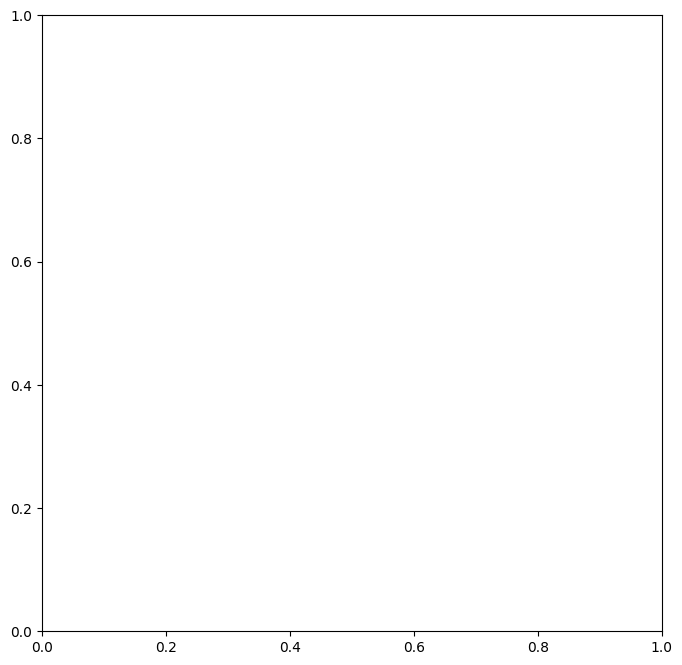

AttributeError: 'MobileNetwork' object has no attribute 'set_render_config'

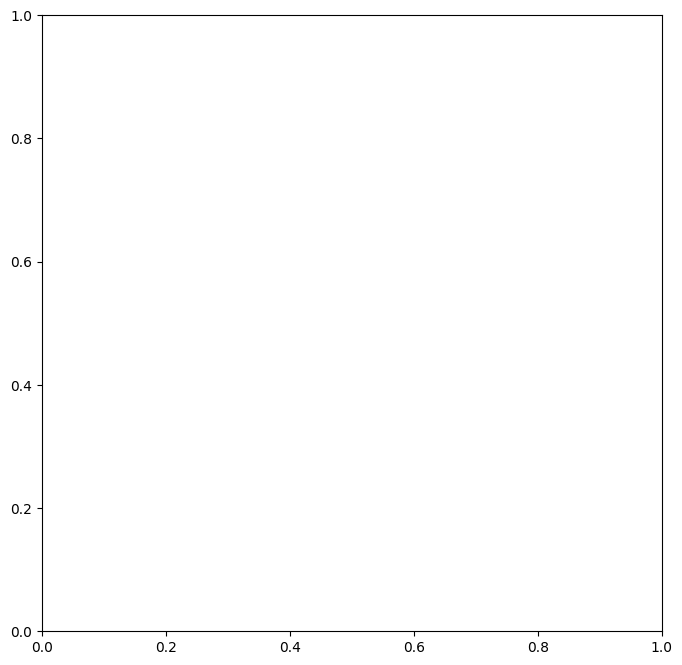

In [ ]:
import numpy as np
import random
from collections import defaultdict
import warnings
from types import SimpleNamespace

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
try:
    from IPython.display import display
    _HAVE_IPY = True
except Exception:
    _HAVE_IPY = False


# =========================
# 5G/NR PHY HELPERS & PARAMS
# =========================
def rx_sensitivity_dBm(bw_hz, nf_db=7.0, snr_req_db=-5.0):
    return -174.0 + 10.0*np.log10(max(bw_hz, 1.0)) + nf_db + snr_req_db

MOD_ORDER = 256
BITS_PER_CODEWORD = int(np.log2(MOD_ORDER))  # 8

def spectral_efficiency_from_sinr(SINR_dB, gap_db=1.5, max_se=float(BITS_PER_CODEWORD)):
    gamma = 10.0**(SINR_dB/10.0) / (10.0**(gap_db/10.0))
    se = np.log2(1.0 + gamma)
    return float(np.clip(se, 0.0, max_se))

NR_OVERHEAD = 0.85
SNR_GAP_DB = 1.5
MAX_SE = float(BITS_PER_CODEWORD)

MIMO_MAX_RANK = {'Ma': 4, 'Mi': 8}

BEAM_GAIN_DB = {
    'Ma': {'tx_main': 8.0,  'tx_side': -3.0, 'rx': 0.0},
    'Mi': {'tx_main': 15.0, 'tx_side': -5.0, 'rx': 7.0},
}

UE_INTERF_RX_DB = 0.0
MACRO_REUSE_ONE = False


def mimo_rank_and_total_se(SINR_dB: float, max_layers: int,
                           gap_db: float = SNR_GAP_DB, max_se: float = MAX_SE) -> (int, float):
    sinr_lin = 10.0**(SINR_dB/10.0)
    best_L, best_sum_se = 1, spectral_efficiency_from_sinr(SINR_dB, gap_db, max_se)
    for L in range(2, max_layers+1):
        per_layer_snr_dB = 10.0*np.log10(max(sinr_lin / max(L, 1), 1e-12))
        se_layer = spectral_efficiency_from_sinr(per_layer_snr_dB, gap_db, max_se)
        corr_eff = max(0.5, 1.0 - 0.07*(L-1))
        sum_se = L * se_layer * corr_eff
        if sum_se > best_sum_se:
            best_sum_se, best_L = sum_se, L
    return best_L, float(best_sum_se)


OBS_IDX = SimpleNamespace(
    BS_TYPE=0, TX_NORM=1, CH_UTIL=2, COV_UTIL=3, LOAD_RATIO_NORM=4, NEARBY_POT=5, AVG_SPEED=6,
    REQ_P_NORM=7, AVG_RADIAL_V=8, SP_VAR=9, NEIGHBOR_TX_NORM=10, AVG_DEMAND_NORM=11, INTER_NORM=12
)

# =========================
# ENVIRONMENT
# =========================

class Channel:
    def __init__(self, id, frequency, bandwidth, noise_figure_db=7.0):
        self.id = id
        self.frequency = frequency            # Hz
        self.bandwidth = bandwidth            # Hz
        self.users = []
        self.base_station = None
        self.temperature = 293.15             # K
        self.noise_figure_db = noise_figure_db

    def calculate_noise_power(self):
        k = 1.38e-23
        N = k * self.temperature * self.bandwidth
        NF = 10.0**(self.noise_figure_db / 10.0)
        return N * NF  # W


class BaseStation:
    def __init__(self, id, transmit_power, height, location, type_bs):
        self.id = id
        self.transmit_power = transmit_power  # mW (total)
        self.height = height
        self.type_bs = type_bs  # 'Ma' or 'Mi'
        self.location = np.array(location, dtype=float)
        self.users = []
        self.assigned_channels = []  # channels reserved by this BS
        self.coverage_area = 0.0
        self.per_channel_power = {}  # channel_id -> mW

    # --- 3GPP TR 38.901 (approximate) ---
    def _pl_uma_los(self, d3d, f_ghz, h_ut=1.5):
        c = 3e8
        f_hz = f_ghz * 1e9
        h_bs = float(self.height)
        d2d = max(np.sqrt(max(d3d**2 - (h_bs - h_ut)**2, 1e-9)), 1.0)
        h_bs_eff = h_bs - 1.0
        h_ut_eff = h_ut - 1.0
        d_bp = 4.0 * h_bs_eff * h_ut_eff * f_hz / c
        pl1 = 28.0 + 22.0*np.log10(d3d) + 20.0*np.log10(f_ghz)
        if d2d <= d_bp:
            return pl1
        pl2 = 28.0 + 40.0*np.log10(d3d) + 20.0*np.log10(f_ghz) - 9.0*np.log10(d_bp**2 + (h_bs - h_ut)**2)
        return pl2

    def _pl_uma_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=h_ut)
        pl_nlos = 13.54 + 39.08*np.log10(d3d) + 20.0*np.log10(f_ghz) - 0.6*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _pl_umi_los(self, d3d, f_ghz):
        return 32.4 + 21.0*np.log10(f_ghz) + 20.0*np.log10(d3d)

    def _pl_umi_nlos(self, d3d, f_ghz, h_ut=1.5):
        pl_los = self._pl_umi_los(d3d, f_ghz)
        pl_nlos = 22.4 + 35.3*np.log10(d3d) + 21.3*np.log10(f_ghz) - 0.3*(h_ut - 1.5)
        return max(pl_nlos, pl_los)

    def _eirp_dbm(self, transmit_power_mW: float) -> float:
        g = BEAM_GAIN_DB[self.type_bs]
        tx_dbm = 10.0*np.log10(max(transmit_power_mW, 1e-15))
        return tx_dbm + g['tx_main'] + g['rx']

    def calculate_path_loss(self, distance, frequency, user_height=1.5):
        d2d = max(float(distance), 0.1)
        f_ghz = frequency / 1e9
        d3d = np.sqrt(d2d**2 + (self.height - user_height)**2)

        if self.type_bs == 'Ma':
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 63.0)) + np.exp(-d2d / 63.0)
            pl_los = self._pl_uma_los(d3d, f_ghz, h_ut=user_height)
            pl_nlos = self._pl_uma_nlos(d3d, f_ghz, h_ut=user_height)
        else:
            p_los = min(18.0 / d2d, 1.0) * (1.0 - np.exp(-d2d / 36.0)) + np.exp(-d2d / 36.0)
            pl_los = self._pl_umi_los(d3d, f_ghz)
            pl_nlos = self._pl_umi_nlos(d3d, f_ghz, h_ut=user_height)

        return float(p_los * pl_los + (1.0 - p_los) * pl_nlos)

    def update_coverage_area_from_power(self, transmit_power_mW, frequency_hz):
        p_ch = transmit_power_mW / max(len(self.assigned_channels), 1)

        if self.assigned_channels:
            bw_hz = self.assigned_channels[0].bandwidth
            nf_db = self.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if self.type_bs == 'Ma' else 200e6
            nf_db = 7.0

        sens_dBm = rx_sensitivity_dBm(bw_hz, nf_db=nf_db, snr_req_db=-5.0)
        eirp_dbm = self._eirp_dbm(p_ch)
        path_loss_dB = eirp_dbm - sens_dBm

        self.coverage_area = self.find_distance_for_path_loss(path_loss_dB, frequency_hz)
        self.coverage_area = min(self.coverage_area, 2000.0 if self.type_bs == 'Ma' else 300.0)
        return self.coverage_area

    def find_distance_for_path_loss(self, path_loss_dB, frequency):
        d_min, d_max = 1.0, 10000.0
        tol = 0.1
        for _ in range(30):
            d_mid = 0.5*(d_min + d_max)
            PL_mid = self.calculate_path_loss(d_mid, frequency)
            if abs(PL_mid - path_loss_dB) < tol:
                return d_mid
            if PL_mid < path_loss_dB:
                d_min = d_mid
            else:
                d_max = d_mid
        return d_mid

    def assign_channels(self, num_channels, available_channels):
        num_channels = min(num_channels, len(available_channels))
        self.assigned_channels = available_channels[:num_channels]
        for ch in self.assigned_channels:
            ch.base_station = self

    def clear_assigned_channels(self):
        self.assigned_channels = []
        self.per_channel_power = {}

    def find_available_channel(self):
        for ch in self.assigned_channels:
            if len(ch.users) == 0:
                return ch
        return None

    def assign_channel_to_user(self, user):
        ch = self.find_available_channel()
        if ch:
            user.channel.append(ch)
            ch.users.append(user)


class User:
    def __init__(self, id, location, velocity, demand):
        self.id = id
        self.location = np.array(location, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.height = 1.5
        self.channel = []
        self.channel_SINR = []
        self.SINR = 0
        self.SINR_ma = 0
        self.SINR_mi = 0
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_mi = 0
        self.demand = demand
        self.speed = np.linalg.norm(velocity)
        self.waypoint = None
        self.pause_time = 0
        self.dir_axis = None
        self.dir_sign = 1
        self.next_intersection = None
        self.mimo_layers = []

    def calculate_data_rate(self):
        self.data_rate_ma = 0.0
        self.data_rate_mi = 0.0
        self.mimo_layers = []
        for i, ch in enumerate(self.channel):
            bw_eff = ch.bandwidth * NR_OVERHEAD
            SINR_dB = self.channel_SINR[i]
            max_rank = MIMO_MAX_RANK[ch.base_station.type_bs]
            L, total_se = mimo_rank_and_total_se(SINR_dB, max_rank, gap_db=SNR_GAP_DB, max_se=MAX_SE)
            dr_Mbps = (bw_eff * total_se) / 1e6
            self.mimo_layers.append(L)
            if ch.base_station.type_bs == 'Ma':
                self.data_rate_ma += dr_Mbps
            else:
                self.data_rate_mi += dr_Mbps
        self.data_rate = self.data_rate_ma + self.data_rate_mi

    def calculate_demand_from_rng(self, rng):
        app_types = {'video': 50, 'gaming': 100, 'browsing': 20}
        app = rng.choice(list(app_types.keys()))
        self.demand = float(app_types[app] * (1 + rng.uniform(0, 0.5)))

    def calculate_latency(self):
        if not self.channel:
            return 100.0
        avg_d = np.mean([np.linalg.norm(self.location - ch.base_station.location) for ch in self.channel])
        prop_delay = (avg_d / 3e8) * 1e3  # ms
        proc_delay = 0.5
        sched_delay = 0.5
        num_users_on_channel = sum(len(ch.users) for ch in self.channel) / len(self.channel)
        queue_delay = 0.5 + num_users_on_channel / (self.data_rate + 1e-6)
        return float(np.clip(prop_delay + proc_delay + sched_delay + queue_delay, 0.0, 100.0))

    def clear_channel(self):
        self.channel = []
        self.channel_SINR = []
        self.SINR_ma_list = []
        self.SINR_mi_list = []
        self.mimo_layers = []


class MobileNetwork(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, num_base_stations, num_users, num_channels, area_size, bs_loc,
                 num_steps=0, max_steps=200, render_mode: str = "human",
                 mobility_model: str = "manhattan", road_spacing: float = 250.0,
                 v_mean: float = 12.0, v_std: float = 3.0, stop_prob: float = 0.05, max_stop_steps: int = 3):
        super().__init__()
        self.render_mode = render_mode if render_mode in self.metadata["render_modes"] else None

        self.np_random, seed = gym.utils.seeding.np_random(42)
        self.num_steps = num_steps
        self.max_steps = max_steps
        self.penalty_factor = 0.1
        self.num_base_stations = num_base_stations
        self.bs_loc = bs_loc
        self.num_users = num_users
        self.num_channels = num_channels
        self.area_size = [area_size, area_size]

        # Mobility config
        self.mobility_model = mobility_model
        self.road_spacing = road_spacing
        self.v_mean = v_mean
        self.v_std = v_std
        self.stop_prob = stop_prob
        self.max_stop_steps = max_stop_steps
        self._build_road_grid()

        # TX powers (mW)
        self.ma_transmission_power = 40000.0
        self.mi_transmission_power = 10000.0

        # Channel caps per BS
        self.max_ma_channels = 100
        self.max_mi_channels = 10

        self.type_bs = ["Ma"] * 4 + ["Mi"] * (num_base_stations - 4)
        self.transmit_power = [self.ma_transmission_power] * 4 + [self.mi_transmission_power] * (num_base_stations - 4)
        self.height = [30] * 4 + [10] * (num_base_stations - 4)

        self.base_stations = [
            BaseStation(i, self.transmit_power[i], self.height[i], bs_loc[i], self.type_bs[i])
            for i in range(num_base_stations)
        ]

        # Users
        self.users = []
        for i in range(num_users):
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
            else:
                loc = self.np_random.uniform(0, area_size, 2)
                vel = self.np_random.integers(-10, 10, 2)
            demand = self.np_random.integers(100, 280)
            self.users.append(User(i, loc, vel, demand))

        for u in self.users:
            if self.mobility_model == "manhattan":
                self._init_user_manhattan(u)
            else:
                u.speed = float(np.linalg.norm(u.velocity))
                u.waypoint = self.np_random.uniform(0, area_size, 2)

        # Carriers
        self.macro_carrier_frequencies = [3.5e9] if MACRO_REUSE_ONE else [3.4e9, 3.5e9, 3.6e9, 3.7e9, 3.8e9]
        self.micro_carrier_frequencies = [24.5e9, 25.5e9, 26.5e9, 27.5e9, 28.5e9]

        # Per-channel bandwidths
        num_channels_per_carrier_ma = 135
        num_channels_per_carrier_mi = 130
        macro_bw_hz = 3.6e6
        micro_bw_hz = 14.4e6

        self.macro_channels = []
        ch_id = 0
        for f in self.macro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_ma):
                self.macro_channels.append(Channel(ch_id, f, macro_bw_hz, noise_figure_db=7.0))
                ch_id += 1

        self.micro_channels = []
        for f in self.micro_carrier_frequencies:
            for _ in range(num_channels_per_carrier_mi):
                self.micro_channels.append(Channel(ch_id, f, micro_bw_hz, noise_figure_db=7.0))
                ch_id += 1

        self.cap_per_freq = defaultdict(int)
        for ch in (self.macro_channels + self.micro_channels):
            self.cap_per_freq[ch.frequency] += 1

        self.current_episode_reward = 0.0

        # Plot
        self.fig = self.ax = self.disp = None
        if self.render_mode == "human":
            try:
                self.fig, self.ax = plt.subplots(figsize=(8, 8))
                self.disp = display(self.fig, display_id='sim_fig') if _HAVE_IPY else None
            except Exception as e:
                warnings.warn(f"Render init failed: {e}")
                self.fig = self.ax = self.disp = None
                self.render_mode = None

        low = np.array([[0.001, 0.001]] * num_base_stations, dtype=np.float32)
        high = np.array([[1.0, 1.0]] * num_base_stations, dtype=np.float32)
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_base_stations, 13), dtype=np.float32)
        self.reward_range = (-np.inf, np.inf)

        self.seed()
        self._assign_frequency_subsets()

        self.prev_assoc_by_user = {u.id: {'Ma': None, 'Mi': None} for u in self.users}

        # ---------- Render config/history ----------
        self.last_info = {}
        self.history = defaultdict(list)
        self.history_len = 300
        self.render_cfg = SimpleNamespace(
            theme="dark",
            show_dashboard=True,
            show_heat=False,
            heat_res=60,
            vectors=True,
            link_width_scale=1.6,
            demand_size_scale=0.35
        )
        self._artists = {}
        self._axes = {}

    def set_render_config(self, **kwargs):
        for k, v in kwargs.items():
            if hasattr(self.render_cfg, k):
                setattr(self.render_cfg, k, v)

    # ---------- Manhattan mobility ----------
    def _build_road_grid(self):
        L = self.area_size[0]
        spacing = max(50.0, float(self.road_spacing))
        xs = np.arange(0.0, L + 1e-6, spacing)
        ys = np.arange(0.0, L + 1e-6, spacing)
        self.grid_xs = xs
        self.grid_ys = ys

    def _snap_to_grid(self, p):
        x = self.grid_xs[np.argmin(np.abs(self.grid_xs - p[0]))]
        y = self.grid_ys[np.argmin(np.abs(self.grid_ys - p[1]))]
        return np.array([x, y], dtype=float)

    def _spawn_on_grid(self):
        L = self.area_size[0]
        if self.np_random.random() < 0.5:
            y = float(self.np_random.choice(self.grid_ys))
            x = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'x', 1 if self.np_random.random() < 0.5 else -1
        else:
            x = float(self.np_random.choice(self.grid_xs))
            y = float(self.np_random.uniform(0, L))
            dir_axis, dir_sign = 'y', 1 if self.np_random.random() < 0.5 else -1
        loc = np.array([x, y], dtype=float)
        speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
        if dir_axis == 'x':
            vel = np.array([dir_sign * speed, 0.0], dtype=float)
        else:
            vel = np.array([0.0, dir_sign * speed], dtype=float)
        return loc, vel

    def _init_user_manhattan(self, u: User):
        L = self.area_size[0]
        u.location = self._snap_to_grid(u.location)
        if abs(u.velocity[0]) >= abs(u.velocity[1]):
            u.dir_axis = 'x'
            u.dir_sign = 1 if u.velocity[0] >= 0 else -1
        else:
            u.dir_axis = 'y'
            u.dir_sign = 1 if u.velocity[1] >= 0 else -1
        u.speed = float(max(1.0, np.linalg.norm(u.velocity)))
        eps = 1e-9
        if u.dir_axis == 'x':
            if u.dir_sign > 0:
                candidates = self.grid_xs[self.grid_xs > (u.location[0] + eps)]
                x_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_xs[self.grid_xs < (u.location[0] - eps)]
                x_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([x_next, u.location[1]], dtype=float)
        else:
            if u.dir_sign > 0:
                candidates = self.grid_ys[self.grid_ys > (u.location[1] + eps)]
                y_next = candidates.min() if candidates.size > 0 else L
            else:
                candidates = self.grid_ys[self.grid_ys < (u.location[1] - eps)]
                y_next = candidates.max() if candidates.size > 0 else 0.0
            u.next_intersection = np.array([u.location[0], y_next], dtype=float)
        u.pause_time = 0

    def _advance_user_manhattan(self, u: User):
        L = self.area_size[0]
        if u.pause_time > 0:
            u.pause_time -= 1
            return
        delta = u.next_intersection - u.location
        dist = float(np.linalg.norm(delta))
        step = min(dist, u.speed)
        if dist > 1e-9:
            u.location += (delta / dist) * step
        if np.linalg.norm(u.location - u.next_intersection) <= 1e-6 or step == dist:
            if self.np_random.random() < self.stop_prob:
                u.pause_time = int(self.np_random.integers(1, self.max_stop_steps + 1))
            r = self.np_random.random()
            if r < 0.2:  # left
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = 1 if u.dir_sign > 0 else -1
                else:
                    u.dir_axis = 'x'; u.dir_sign = -1 if u.dir_sign > 0 else 1
            elif r < 0.4:  # right
                if u.dir_axis == 'x':
                    u.dir_axis = 'y'; u.dir_sign = -1 if u.dir_sign > 0 else 1
                else:
                    u.dir_axis = 'x'; u.dir_sign = 1 if u.dir_sign > 0 else -1
            u.speed = float(max(1.0, self.np_random.normal(self.v_mean, self.v_std)))
            if u.dir_axis == 'x':
                if u.dir_sign > 0:
                    candidates = self.grid_xs[self.grid_xs > u.location[0]]
                    x_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_xs[self.grid_xs < u.location[0]]
                    x_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
            else:
                if u.dir_sign > 0:
                    candidates = self.grid_ys[self.grid_ys > u.location[1]]
                    y_next = candidates.min() if candidates.size > 0 else L
                else:
                    candidates = self.grid_ys[self.grid_ys < u.location[1]]
                    y_next = candidates.max() if candidates.size > 0 else 0.0
                u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

            hit_x_edge = (u.next_intersection[0] <= 0.0 or u.next_intersection[0] >= L)
            hit_y_edge = (u.next_intersection[1] <= 0.0 or u.next_intersection[1] >= L)
            if hit_x_edge or hit_y_edge:
                u.dir_sign *= -1
                if u.dir_axis == 'x':
                    if u.dir_sign > 0:
                        candidates = self.grid_xs[self.grid_xs > u.location[0]]
                        x_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_xs[self.grid_xs < u.location[0]]
                        x_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([x_next, self._snap_to_grid(u.location)[1]], dtype=float)
                    u.velocity = np.array([u.dir_sign * u.speed, 0.0], dtype=float)
                else:
                    if u.dir_sign > 0:
                        candidates = self.grid_ys[self.grid_ys > u.location[1]]
                        y_next = candidates.min() if candidates.size > 0 else L
                    else:
                        candidates = self.grid_ys[self.grid_ys < u.location[1]]
                        y_next = candidates.max() if candidates.size > 0 else 0.0
                    u.next_intersection = np.array([self._snap_to_grid(u.location)[0], y_next], dtype=float)
                    u.velocity = np.array([0.0, u.dir_sign * u.speed], dtype=float)

    def seed(self, seed=None):
        if seed is None:
            seed = random.randrange(0, 2**32 - 1)
        seed32 = int(seed) & 0xFFFFFFFF
        self.np_random, _ = gym.utils.seeding.np_random(seed32)
        random.seed(seed32)
        np.random.seed(seed32)
        return [seed32]

    def _assign_frequency_subsets(self):
        self.bs_carrier_frequency = {}
        ma_list = self.macro_carrier_frequencies
        mi_list = self.micro_carrier_frequencies
        ma_idx = 0
        mi_idx = 0
        for bs in self.base_stations:
            if bs.type_bs == 'Ma':
                if MACRO_REUSE_ONE:
                    f = ma_list[0]
                else:
                    f = ma_list[ma_idx % len(ma_list)]; ma_idx += 1
            else:
                f = mi_list[mi_idx % len(mi_list)]; mi_idx += 1
            self.bs_carrier_frequency[bs.id] = f

    def _per_channel_tx_power_mW(self, bs):
        if bs.per_channel_power:
            return float(np.mean(list(bs.per_channel_power.values())))
        n = max(len(bs.assigned_channels), 1)
        return bs.transmit_power / n

    def _noise_mW_for(self, bs):
        if bs.assigned_channels:
            return bs.assigned_channels[0].calculate_noise_power() * 1e3
        bw_hz = 100e6 if bs.type_bs == 'Ma' else 200e6
        k = 1.38e-23; T = 293.15; NF = 10**(7/10)
        return k*T*bw_hz*NF*1e3

    def _est_rate_one_channel_Mbps(self, u, bs):
        if not bs.assigned_channels:
            return 0.0
        f = self.bs_carrier_frequency[bs.id]
        d = float(np.linalg.norm(u.location - bs.location))
        PL_dB = bs.calculate_path_loss(d, f)
        n = max(len(bs.assigned_channels), 1)
        p_ch = bs.transmit_power / n
        g = BEAM_GAIN_DB[bs.type_bs]
        g_tx = 10**(g['tx_main']/10); g_rx = 10**(g['rx']/10)
        sig_mW = p_ch * g_tx * g_rx / (10.0**(PL_dB/10.0))
        noise_mW = self._noise_mW_for(bs)
        SINR = sig_mW / max(noise_mW, 1e-12)
        SINR_dB = 10*np.log10(max(SINR, 1e-12))
        bw = bs.assigned_channels[0].bandwidth * NR_OVERHEAD
        _, total_se = mimo_rank_and_total_se(SINR_dB, MIMO_MAX_RANK[bs.type_bs], gap_db=SNR_GAP_DB, max_se=MAX_SE)
        return (bw * total_se) / 1e6  # Mbps

    def _best_bs_in_cov(self, u, type_filter=None):
        best, best_score = None, 0.0
        for bs in self.base_stations:
            if (type_filter is not None) and (bs.type_bs != type_filter):
                continue
            if not any(len(c.users) == 0 for c in bs.assigned_channels):
                continue
            d = np.linalg.norm(u.location - bs.location)
            if d > bs.coverage_area:
                continue
            r = self._est_rate_one_channel_Mbps(u, bs)
            load = sum(1 for c in bs.assigned_channels if len(c.users) > 0) / max(1, len(bs.assigned_channels))
            fairness = (1.0 - 0.5 * load)
            score = r * fairness
            if score > best_score:
                best_score = score; best = bs
        return best, best_score

    def _estimate_interference_mW(self, u, f, exclude_bs):
        co = [b for b in self.base_stations if b is not exclude_bs and self.bs_carrier_frequency[b.id] == f]
        I = 0.0
        g_rx_int = 10.0**(UE_INTERF_RX_DB/10.0)
        for bi in co:
            p_i = self._per_channel_tx_power_mW(bi)
            d_i = np.linalg.norm(u.location - bi.location)
            PL_i = bi.calculate_path_loss(d_i, f)
            gi = BEAM_GAIN_DB[bi.type_bs]
            g_tx_i = 10.0**(gi['tx_side']/10.0)
            users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
            util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
            I += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))
        return I

    @staticmethod
    def _waterfill(P_total, h_list, n_list, p_floor_list=None, tol=1e-6, max_it=60):
        K = len(h_list)
        if K == 0:
            return []
        h = np.asarray(h_list, dtype=float)
        n = np.asarray(n_list, dtype=float)
        p_floor = np.zeros(K, dtype=float) if p_floor_list is None else np.asarray(p_floor_list, dtype=float)
        lo, hi = 0.0, 1e12
        def alloc(lmbd):
            base = 1.0/max(lmbd, 1e-18)
            out = np.maximum(p_floor, base - n/np.maximum(h, 1e-18))
            return np.maximum(out, 0.0)
        p_floor_sum = float(np.sum(p_floor))
        if p_floor_sum > P_total:
            if p_floor_sum < 1e-12:
                return [0.0]*K
            scaled = P_total * (p_floor / p_floor_sum)
            return list(np.maximum(scaled, 0.0))
        for _ in range(max_it):
            mid = 0.5*(lo+hi)
            p = alloc(mid)
            s = float(np.sum(p))
            if abs(s - P_total) <= tol:
                return list(np.maximum(p, 0.0))
            if s > P_total:
                lo = mid
            else:
                hi = mid
        return list(np.maximum(alloc(hi), 0.0))

    def assign_channels_on_demand(self, max_macro_per_user=1, max_micro_per_user=1):
        for u in self.users:
            u.clear_channel()
        for u in self.users:
            bs_ma, _ = self._best_bs_in_cov(u, type_filter='Ma')
            if bs_ma:
                ch = bs_ma.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)
        for u in self.users:
            have_mi = any(c.base_station.type_bs == 'Mi' for c in u.channel)
            if have_mi:
                continue
            bs_mi, _ = self._best_bs_in_cov(u, type_filter='Mi')
            if bs_mi:
                ch = bs_mi.find_available_channel()
                if ch:
                    u.channel.append(ch); ch.users.append(u)

    def step(self, action):
        self.num_steps += 1

        for u in self.users:
            if self.np_random.random() < 0.1:
                u.calculate_demand_from_rng(self.np_random)

        power_consumption_penalty = 0.0
        total_data_rate = 0.0
        total_mi_data_rate = 0.0
        total_ma_data_rate = 0.0
        user_latencies = []

        action = np.clip(action, self.action_space.low, self.action_space.high)
        power_fraction = action[:, 0]
        channel_fraction = action[:, 1]

        for u in self.users:
            u.clear_channel()
        for bs in self.base_stations:
            bs.clear_assigned_channels()
        for ch in self.macro_channels + self.micro_channels:
            ch.users.clear()
            ch.base_station = None

        self.assigned_channels = {}
        self.frequency_to_channels = defaultdict(list)

        user_locations = np.array([u.location for u in self.users])

        total_ma_channels = 0
        total_mi_channels = 0
        requested_ma_channels_per_freq = defaultdict(int)
        requested_mi_channels_per_freq = defaultdict(int)

        for i, bs in enumerate(self.base_stations):
            f = self.bs_carrier_frequency[bs.id]

            if bs.type_bs == 'Ma':
                bs.transmit_power = float(power_fraction[i]) * self.ma_transmission_power
            else:
                bs.transmit_power = float(power_fraction[i]) * self.mi_transmission_power

            bs.update_coverage_area_from_power(bs.transmit_power, f)

            if bs.type_bs == 'Ma':
                avail_pool = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_ma_channels)
            else:
                avail_pool = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
                max_cap = int(self.max_mi_channels)

            req_ch = int(np.rint(float(channel_fraction[i]) * max_cap))
            req_ch = int(np.clip(req_ch, 0, len(avail_pool)))
            if req_ch == 0 and len(avail_pool) > 0 and bs.transmit_power > 1e-6:
                req_ch = 1

            if req_ch > 0:
                bs.assign_channels(req_ch, avail_pool)
                for ch in bs.assigned_channels:
                    self.assigned_channels[ch] = None
                    self.frequency_to_channels[ch.frequency].append((bs, ch))
                    if bs.type_bs == 'Ma':
                        total_ma_channels += 1
                    else:
                        total_mi_channels += 1

            if bs.type_bs == 'Ma':
                requested_ma_channels_per_freq[f] += req_ch
            else:
                requested_mi_channels_per_freq[f] += req_ch

            bs.update_coverage_area_from_power(bs.transmit_power, f)

            dists = np.linalg.norm(user_locations - bs.location, axis=1)
            idx = np.where(dists <= bs.coverage_area)[0]
            if idx.size > 0:
                p90 = float(np.percentile(dists[idx], 90))
                req_tx_mW_per_ch = self.calculate_required_power_for_distance(p90, bs)
                req_tx_mW_total = req_tx_mW_per_ch * max(1, len(bs.assigned_channels))

                denom = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
                under = max(0.0, (req_tx_mW_total - bs.transmit_power) / max(denom, 1e-9))
                over  = max(0.0, (bs.transmit_power - req_tx_mW_total) / max(denom, 1e-9))
                power_consumption_penalty += 1.2 * under + 0.3 * np.tanh(over)

                min_total = 0.85 * req_tx_mW_total
                if bs.transmit_power < min_total:
                    bs.transmit_power = min_total
                    bs.update_coverage_area_from_power(bs.transmit_power, f)

        self.assign_channels_on_demand(max_macro_per_user=1, max_micro_per_user=1)

        for bs in self.base_stations:
            bs.per_channel_power = {}
            ch_act, H, N, floors = [], [], [], []
            for ch in bs.assigned_channels:
                if not ch.users:
                    continue
                u = ch.users[0]
                f = self.bs_carrier_frequency[bs.id]
                d = float(np.linalg.norm(u.location - bs.location))
                PL_dB = bs.calculate_path_loss(d, f)
                g = BEAM_GAIN_DB[bs.type_bs]
                h = (10**(g['tx_main']/10) * 10**(g['rx']/10)) / (10**(PL_dB/10.0))
                noise_mW = ch.calculate_noise_power()*1e3
                I_mW = self._estimate_interference_mW(u, f, bs)
                prio = float(np.clip(0.5 + (u.demand/150.0), 0.5, 1.5))
                N_eff = (noise_mW + I_mW) / prio
                ch_act.append(ch); H.append(h); N.append(N_eff); floors.append(0.0)

            if not ch_act:
                continue

            P_total = float(bs.transmit_power)
            p_list = self._waterfill(P_total, H, N, p_floor_list=floors, tol=1e-6, max_it=60)
            for ch, p in zip(ch_act, p_list):
                bs.per_channel_power[ch.id] = float(max(p, 0.0))

        for u in self.users:
            self.calculate_SINR(u)
            u.calculate_data_rate()
            user_latencies.append(u.calculate_latency())
            total_data_rate += u.data_rate
            total_mi_data_rate += u.data_rate_mi
            total_ma_data_rate += u.data_rate_ma

        ma_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Ma')
        mi_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Mi')
        total_power = ma_power + mi_power

        served = sum(min(u.data_rate, u.demand) for u in self.users)
        total_demand = sum(u.demand for u in self.users) + 1e-9
        util = served / total_demand

        n_ma = sum(1 for bs in self.base_stations if bs.type_bs == 'Ma')
        n_mi = self.num_base_stations - n_ma
        budget_mW = n_ma * self.ma_transmission_power + n_mi * self.mi_transmission_power
        power_norm = total_power / max(budget_mW, 1e-9)

        reward = 10.0 * util - 2.0 * power_norm
        reward = float(np.clip(reward, -10.0, 10.0))

        rates = [u.data_rate for u in self.users]
        avg_rate = float(np.mean(rates)) if rates else 0.0

        info = {
            'total_data_rate': total_data_rate,
            'ma_data_rate': total_ma_data_rate,
            'mi_data_rate': total_mi_data_rate,
            'avg_rate': avg_rate,
            'total_power': total_power,
            'util': util,
            'power_norm': power_norm,
        }

        self.current_episode_reward += reward
        self.last_info = info
        for k, v in info.items():
            if isinstance(v, (int, float)):
                self.history[k].append(float(v))
                if len(self.history[k]) > self.history_len:
                    self.history[k] = self.history[k][-self.history_len:]

        terminated = False
        truncated = self.num_steps >= self.max_steps
        obs = self.get_observation()
        self.update_user_location()

        return obs, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        self.current_episode_reward = 0.0
        self.num_steps = 0

        L = self.area_size[0]
        for u in self.users:
            if self.mobility_model == "manhattan":
                loc, vel = self._spawn_on_grid()
                u.location = loc
                u.velocity = vel
                self._init_user_manhattan(u)
            else:
                u.location = self.np_random.uniform(0, L, 2)
                u.waypoint = self.np_random.uniform(0, L, 2)
                u.speed = float(np.linalg.norm(u.velocity))
            u.data_rate = 0.0
            u.SINR = 0.0
            u.clear_channel()

        for ch in self.macro_channels + self.micro_channels:
            ch.users = []
            ch.base_station = None

        self.assigned_channels = {}
        for bs in self.base_stations:
            bs.users = []
            bs.clear_assigned_channels()
            bs.transmit_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            f = self.bs_carrier_frequency[bs.id]
            if bs.type_bs == 'Ma':
                avail = [c for c in self.macro_channels if c.frequency == f and c not in self.assigned_channels]
            else:
                avail = [c for c in self.micro_channels if c.frequency == f and c not in self.assigned_channels]
            bs.assign_channels(1, avail[:1])
            for ch in bs.assigned_channels:
                self.assigned_channels[ch] = None
            bs.update_coverage_area_from_power(bs.transmit_power, f)

        self.update_user_location()

        # Clear render buffers/history
        self.last_info = {}
        self.history = defaultdict(list)
        self._artists = {}
        self._axes = {}

        return self.get_observation(), {}

    def calculate_required_power_for_distance(self, distance, base_station):
        f = self.bs_carrier_frequency[base_station.id]
        pl_dB = base_station.calculate_path_loss(distance, f)

        if base_station.assigned_channels:
            bw_hz = base_station.assigned_channels[0].bandwidth
            nf_db = base_station.assigned_channels[0].noise_figure_db
        else:
            bw_hz = 100e6 if base_station.type_bs == 'Ma' else 200e6
            nf_db = 7.0
        sens_dBm = rx_sensitivity_dBm(bw_hz, nf_db=nf_db, snr_req_db=-5.0)

        g = BEAM_GAIN_DB[base_station.type_bs]
        req_tx_dBm = sens_dBm + pl_dB - (g['tx_main'] + g['rx'])
        return 10.0**(req_tx_dBm/10.0)

    def update_user_location(self):
        if self.mobility_model == "manhattan":
            for u in self.users:
                self._advance_user_manhattan(u)
                u.location = np.clip(u.location, 0.0, self.area_size[0])
        else:
            L = self.area_size[0]
            for u in self.users:
                if u.pause_time > 0:
                    u.pause_time -= 1
                    continue
                if u.waypoint is None:
                    u.waypoint = self.np_random.uniform(0, L, 2)

                delta = u.waypoint - u.location
                dist = np.linalg.norm(delta)
                if dist <= u.speed:
                    u.location = u.waypoint
                    u.pause_time = int(self.np_random.integers(0, 10))
                    u.waypoint = self.np_random.uniform(0, L, 2)
                    delta = u.waypoint - u.location
                    dist = np.linalg.norm(delta)
                    direction = delta / dist if dist > 0 else np.zeros(2)
                else:
                    direction = delta / dist if dist > 0 else np.zeros(2)

                u.velocity = direction * u.speed
                u.location = np.clip(u.location + u.velocity, 0, L)

    def get_observation(self):
        obs = []
        max_speed = 25.0
        for bs in self.base_stations:
            users_in_cov = [u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area]
            max_power = self.ma_transmission_power if bs.type_bs == 'Ma' else self.mi_transmission_power
            max_ch = self.max_ma_channels if bs.type_bs == 'Ma' else self.max_mi_channels
            bs_type = 0.5 if bs.type_bs == 'Ma' else 1.0
            tx_norm = np.clip(bs.transmit_power / max_power, 0, 1)
            used = sum(1 for c in bs.assigned_channels if len(c.users) > 0)
            ch_util = np.clip(used / max_ch, 0, 1)
            cov_util = len(users_in_cov) / self.num_users if self.num_users > 0 else 0.0
            load_ratio = len(users_in_cov) / max(1, len(bs.assigned_channels))
            load_ratio_norm = float(np.clip(load_ratio, 0.0, 2.0) / 2.0)
            nearby_pot = len([u for u in self.users if np.linalg.norm(u.location - bs.location) <= bs.coverage_area*1.5]) / self.num_users if self.num_users > 0 else 0.0
            avg_speed = np.clip((sum(u.speed for u in users_in_cov) / len(users_in_cov) if users_in_cov else 0.0) / max_speed, 0, 1)

            max_dist = max([np.linalg.norm(u.location - bs.location) for u in users_in_cov]) if users_in_cov else 0.0
            if users_in_cov:
                req_p_per_ch = self.calculate_required_power_for_distance(max_dist, bs)
                n_ch = max(1, len(bs.assigned_channels))
                req_total = req_p_per_ch * n_ch
            else:
                req_total = 0.0
            req_p_norm = np.clip(req_total / max_power if max_power > 0 else 0.0, 0, 1)

            f = self.bs_carrier_frequency[bs.id]
            co_bs = [o for o in self.base_stations if o is not bs and self.bs_carrier_frequency[o.id] == f]

            K = 10
            if users_in_cov:
                sampled_users = users_in_cov if len(users_in_cov) <= K else list(self.np_random.choice(users_in_cov, K, replace=False))
            else:
                sampled_users = []

            I_b = 0.0
            g_rx = 10.0 ** (UE_INTERF_RX_DB / 10.0)
            for b2 in co_bs:
                p_i = self._per_channel_tx_power_mW(b2)
                gi = BEAM_GAIN_DB[b2.type_bs]
                g_tx_i = 10.0 ** (gi['tx_side'] / 10.0)

                users_in_cov_b2 = [uu for uu in self.users if np.linalg.norm(uu.location - b2.location) <= b2.coverage_area]
                util = min(1.0, len(users_in_cov_b2) / max(1, len(b2.assigned_channels)))

                if sampled_users:
                    acc = 0.0
                    for uu in sampled_users:
                        d_i = np.linalg.norm(uu.location - b2.location)
                        PL_i = b2.calculate_path_loss(d_i, f)
                        acc += p_i * g_tx_i * g_rx / (10.0 ** (PL_i / 10.0))
                    I_b += util * (acc / len(sampled_users))

            I_dBm = 10.0 * np.log10(max(I_b, 1e-12))
            inter_norm = np.clip((I_dBm + 120.0) / 120.0, 0.0, 1.0)

            avg_demand_norm = float(np.clip(np.mean([u.demand for u in users_in_cov]) / 300.0, 0, 1)) if users_in_cov else 0.0
            neigh = [
                o.transmit_power / (self.ma_transmission_power if o.type_bs=='Ma' else self.mi_transmission_power)
                for o in self.base_stations
                if o is not bs and np.linalg.norm(bs.location - o.location) < 1000.0
            ]
            neighbor_tx_norm = float(np.mean(neigh)) if len(neigh) > 0 else 0.0

            obs.append([
                bs_type, tx_norm, ch_util, cov_util, load_ratio_norm, nearby_pot, avg_speed,
                req_p_norm, 0.5, 0.0,  # avg_radial_v & sp_var dropped in this minimal obs
                neighbor_tx_norm,
                avg_demand_norm, inter_norm
            ])
        return np.array(obs, dtype=np.float32)

    def calculate_SINR(self, user):
        user.channel_SINR = []
        user.SINR_ma_list = []
        user.SINR_mi_list = []

        for ch in user.channel:
            bs = ch.base_station
            d = np.linalg.norm(user.location - bs.location)
            PL_dB = bs.calculate_path_loss(d, ch.frequency)

            # per-channel power (water-filled if available)
            p_tx_ch = bs.per_channel_power.get(ch.id, None)
            if p_tx_ch is None:
                n = max(len(bs.assigned_channels), 1)
                p_tx_ch = bs.transmit_power / n

            g = BEAM_GAIN_DB[bs.type_bs]
            g_tx_main = 10.0**(g['tx_main']/10.0)
            g_tx_side = 10.0**(g['tx_side']/10.0)
            g_rx_sig = 10.0**(g['rx']/10.0)

            signal_mW = p_tx_ch * g_tx_main * g_rx_sig / (10.0**(PL_dB/10.0))

            if bs.type_bs == 'Ma' and not MACRO_REUSE_ONE:
                interference_mW = 0.0
            else:
                co = {b for (b, _c) in self.frequency_to_channels[ch.frequency] if b != bs}
                interference_mW = 0.0
                g_rx_int = 10.0**(UE_INTERF_RX_DB / 10.0)
                for bi in co:
                    p_i = self._per_channel_tx_power_mW(bi)
                    d_i = np.linalg.norm(user.location - bi.location)
                    PL_i = bi.calculate_path_loss(d_i, ch.frequency)
                    gi = BEAM_GAIN_DB[bi.type_bs]
                    g_tx_i = 10.0**(gi['tx_side']/10.0)
                    users_in_cov_bi = [uu for uu in self.users if np.linalg.norm(uu.location - bi.location) <= bi.coverage_area]
                    util = min(1.0, len(users_in_cov_bi) / max(1, len(bi.assigned_channels)))
                    interference_mW += util * p_i * g_tx_i * g_rx_int / (10.0**(PL_i/10.0))

            noise_W = ch.calculate_noise_power()
            noise_mW = noise_W * 1e3
            denom = max(interference_mW + noise_mW, 1e-15)
            SINR_lin = signal_mW / denom if signal_mW > 0 else 0.0
            SINR_dB = float(np.clip(10.0*np.log10(SINR_lin) if SINR_lin > 0 else -100.0, -100.0, 30.0))

            user.channel_SINR.append(SINR_dB)
            if bs.type_bs == 'Ma':
                user.SINR_ma_list.append(SINR_dB)
            else:
                user.SINR_mi_list.append(SINR_dB)

        if user.SINR_ma_list:
            s_ma = np.mean([10.0**(x/10.0) for x in user.SINR_ma_list])
            user.SINR_ma = 10.0*np.log10(s_ma) if s_ma > 0 else -100.0
        else:
            user.SINR_ma = -100.0

        if user.SINR_mi_list:
            s_mi = np.mean([10.0**(x/10.0) for x in user.SINR_mi_list])
            user.SINR_mi = 10.0*np.log10(s_mi) if s_mi > 0 else -100.0
        else:
            user.SINR_mi = -100.0

    # ---------- helpers for renderer ----------
    def _compute_sinr_heat(self, res=60, tier='Ma'):
        L = self.area_size[0]
        xs = np.linspace(0, L, res)
        ys = np.linspace(0, L, res)
        Z = np.full((res, res), -100.0, dtype=float)
        for iy, y in enumerate(ys):
            for ix, x in enumerate(xs):
                p = np.array([x, y], dtype=float)
                best = -100.0
                for bs in self.base_stations:
                    if bs.type_bs != tier or len(bs.assigned_channels) == 0:
                        continue
                    d = np.linalg.norm(p - bs.location)
                    if d > bs.coverage_area:
                        continue
                    f = self.bs_carrier_frequency[bs.id]
                    PL = bs.calculate_path_loss(d, f)
                    p_ch = self._per_channel_tx_power_mW(bs)
                    g = BEAM_GAIN_DB[bs.type_bs]
                    sig = p_ch * 10**(g['tx_main']/10) * 10**(g['rx']/10) / (10**(PL/10))
                    noise = bs.assigned_channels[0].calculate_noise_power() * 1e3
                    sinr = 10*np.log10(max(sig / max(noise, 1e-15), 1e-12))
                    if sinr > best: best = sinr
                Z[iy, ix] = best
        return xs, ys, Z

    def _build_quiver(self, ax):
        # Build quiver with current user positions; start with zero vectors
        xs_u = [u.location[0] for u in self.users]
        ys_u = [u.location[1] for u in self.users]
        U = np.zeros(len(xs_u))
        V = np.zeros(len(ys_u))
        self._artists['quiver'] = ax.quiver(xs_u, ys_u, U, V, angles='xy',
                                            scale_units='xy', scale=1.0, width=0.002,
                                            alpha=0.6, color=("#e6edf3" if self.render_cfg.theme=="dark" else "#111827"))

    def render(self, mode='human', action=None):
        """
        Single-panel render with fixed meter ticks:
        - X/Y ticks: 0,100,200,300,400,500 (meters) from the origin.
        - No duplicate axis labels (only bottom+left).
        - Light, clean styling; colorbar inset.
        """
        if hasattr(self, "render_cfg"):
            self.render_cfg.theme = "light"
            if hasattr(self.render_cfg, "show_dashboard"):
                self.render_cfg.show_dashboard = False

        if self.render_mode != "human":
            return

        from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        first_time = (not hasattr(self, "_axes")) or ("map" not in getattr(self, "_axes", {}))
        if first_time:
            # Fixed margins so labels have space
            self.fig = plt.figure(figsize=(8.6, 8.6))
            self.fig.subplots_adjust(left=0.13, right=0.985, bottom=0.14, top=0.965)
            self._axes = {}
            axm = self.fig.add_subplot(111)
            self._axes["map"] = axm

            # Palette
            bg = "white"; fg = "#111827"; grid_c = "#e5e7eb"
            axm.set_facecolor(bg)
            for s in axm.spines.values():
                s.set_color("#d1d5db")
            axm.tick_params(colors=fg, labelsize=10, pad=4, top=False, right=False, labeltop=False, labelright=False)
            self.fig.patch.set_facecolor(bg)

            # Map geometry
            L = float(self.area_size[0])
            axm.set_box_aspect(1)
            axm.set_anchor("N")

            # Subtle road grid
            if self.mobility_model == "manhattan":
                for x in self.grid_xs:
                    axm.plot([x, x], [0, L], linestyle=":", linewidth=0.6, alpha=0.45, color=grid_c, zorder=0)
                for y in self.grid_ys:
                    axm.plot([0, L], [y, y], linestyle=":", linewidth=0.6, alpha=0.45, color=grid_c, zorder=0)

            # Artists
            self._artists = {}
            self._artists["cov_patches"] = []
            for bs in self.base_stations:
                c = "#93c5fd" if bs.type_bs == "Ma" else "#a7f3d0"
                circ = Circle(bs.location, bs.coverage_area, color=c, alpha=0.22, lw=0, zorder=1)
                axm.add_patch(circ)
                self._artists["cov_patches"].append(circ)

            xs_b = [bs.location[0] for bs in self.base_stations]
            ys_b = [bs.location[1] for bs in self.base_stations]
            colors_b = ['#60a5fa' if bs.type_bs == 'Ma' else '#34d399' for bs in self.base_stations]
            self._artists["bs_scatter"] = axm.scatter(
                xs_b, ys_b, s=105, c=colors_b, marker="^",
                edgecolors="#ffffff", linewidths=0.7, alpha=0.95, zorder=3
            )
            for bs in self.base_stations:
                axm.text(bs.location[0], bs.location[1], f"BS{bs.id}", color=fg, fontsize=8,
                        ha="left", va="bottom", zorder=4)

            xs_u0 = [u.location[0] for u in self.users]
            ys_u0 = [u.location[1] for u in self.users]
            sizes0 = np.full(len(xs_u0), 22.0)
            colors0 = np.zeros(len(xs_u0))
            self._artists["users"] = axm.scatter(
                xs_u0, ys_u0, s=sizes0, c=colors0, cmap="YlGnBu",
                vmin=0.0, vmax=1.0, alpha=0.95, edgecolors="#ffffff", linewidths=0.5, zorder=4
            )

            # Inset colorbar (kept away from axes labels)
            cax = inset_axes(axm, width="30%", height="3.8%", loc="upper right", borderpad=1)
            cbar = self.fig.colorbar(self._artists["users"], cax=cax, orientation="horizontal")
            cbar.set_label("Served demand ratio", color=fg)
            cbar.ax.xaxis.set_tick_params(color=fg, labelsize=9)
            for lbl in cbar.ax.get_xticklabels():
                lbl.set_color(fg)
            self._artists["cbar"] = cbar

            # Vectors
            if getattr(self.render_cfg, "vectors", True):
                U = np.zeros(len(xs_u0)); V = np.zeros(len(ys_u0))
                self._artists['quiver'] = axm.quiver(
                    xs_u0, ys_u0, U, V, angles='xy', scale_units='xy', scale=1.0, width=0.002,
                    alpha=0.7, color="#6b7280"
                )

            # Links
            from matplotlib.collections import LineCollection
            self._artists["links_ma"] = LineCollection([], colors="#93c5fd", linewidths=1.6, alpha=0.55, zorder=2)
            self._artists["links_mi"] = LineCollection([], colors="#a7f3d0", linewidths=1.6, alpha=0.55, zorder=2)
            axm.add_collection(self._artists["links_ma"])
            axm.add_collection(self._artists["links_mi"])

            # Optional heat
            if getattr(self.render_cfg, "show_heat", False):
                _, _, Z = self._compute_sinr_heat(getattr(self.render_cfg, "heat_res", 60), tier="Ma")
                self._artists["heat"] = axm.imshow(
                    Z, origin="lower", extent=(0, L, 0, L), alpha=0.40, cmap="YlGnBu",
                    vmin=-5, vmax=25, interpolation="nearest", zorder=0
                )

            # Limits
            axm.set_xlim(0, L); axm.set_ylim(0, L)

            # ==== FIXED TICKS/LABELS: 0..500 m at 100 m steps ====
            # Map your simulation span [0..L] to labels [0..500] by scaling the tick labels.
            # Place ticks at 6 evenly spaced positions (0, L/5, ..., L).
            tick_positions = np.linspace(0, L, 6)  # corresponds to 0..500 labels
            fixed_labels = [f"{i*100}" for i in range(6)]  # "0, 100, 200, 300, 400, 500"
            axm.set_xticks(tick_positions)
            axm.set_yticks(tick_positions)
            axm.set_xticklabels(fixed_labels, color=fg)
            axm.set_yticklabels(fixed_labels, color=fg)

            # Only bottom+left labels (prevents double labeling)
            axm.tick_params(axis='x', which='both', labelbottom=True, labeltop=False)
            axm.tick_params(axis='y', which='both', labelleft=True, labelright=False)

            # Axis titles (single, clear)
            axm.set_xlabel("X (meters)", color=fg, labelpad=12, fontsize=11, fontweight="semibold")
            axm.set_ylabel("Y (meters)", color=fg, labelpad=12, fontsize=11, fontweight="semibold")

            axm.grid(True, color=grid_c, linewidth=0.8, alpha=0.8, zorder=0)
            axm.margins(x=0.01, y=0.01)

            # Legend (kept away from axes origin)
            legend_handles = [
                plt.Line2D([0], [0], marker="^", color="w", label="Macro BS",
                          markerfacecolor="#60a5fa", markeredgecolor="#ffffff", markersize=9),
                plt.Line2D([0], [0], marker="^", color="w", label="Micro BS",
                          markerfacecolor="#34d399", markeredgecolor="#ffffff", markersize=9),
                plt.Line2D([0], [0], marker="o", color="w", label="User",
                          markerfacecolor="#93c5fd", markeredgecolor="#ffffff", markersize=7),
            ]
            leg = axm.legend(
                handles=legend_handles, frameon=True, facecolor="white", edgecolor="#d1d5db",
                loc="upper left", bbox_to_anchor=(0.01, 0.99), borderaxespad=0.5
            )
            for txt in leg.get_texts():
                txt.set_color(fg)

            # Scalebar (optional small)
            sb_len = min(500.0, L / 5.0)
            sb_y = 0.08 * L
            sb_x0, sb_x1 = 0.06 * L, 0.06 * L + sb_len
            self._artists["scalebar_line"], = axm.plot([sb_x0, sb_x1], [sb_y, sb_y], color=fg, lw=2)
            self._artists["scalebar_text"] = axm.text(
                (sb_x0 + sb_x1) / 2, sb_y + 0.014 * L, f"{int(sb_len)} m",
                ha="center", va="bottom", color=fg
            )

            # Info box
            self._artists["infobox"] = axm.text(
                0.99 * L, 0.99 * L, "", ha="right", va="top", fontsize=9, color=fg,
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#d1d5db", alpha=0.95),
                zorder=5
            )

        # --------- per-frame updates ----------
        axm = self._axes["map"]; L = float(self.area_size[0])

        # Coverage
        for circ, bs in zip(self._artists["cov_patches"], self.base_stations):
            circ.center = bs.location
            circ.set_radius(bs.coverage_area)

        # Users
        xs_u = [u.location[0] for u in self.users]
        ys_u = [u.location[1] for u in self.users]
        served = []
        sizes = []
        for u in self.users:
            r = float(np.clip(u.data_rate / max(u.demand, 1e-6), 0.0, 1.0))
            served.append(r)
            sizes.append(max(12.0, getattr(self.render_cfg, "demand_size_scale", 0.35) * u.demand))
        self._artists["users"].set_offsets(np.c_[xs_u, ys_u])
        self._artists["users"].set_array(np.array(served, dtype=float))
        self._artists["users"].set_sizes(np.array(sizes, dtype=float))

        # Quiver
        if getattr(self.render_cfg, "vectors", True) and "quiver" in self._artists:
            U = np.array([u.velocity[0] for u in self.users], dtype=float)
            V = np.array([u.velocity[1] for u in self.users], dtype=float)
            scale = max(1.0, np.percentile(np.hypot(U, V), 95))
            try:
                self._artists["quiver"].set_offsets(np.c_[xs_u, ys_u])
                self._artists["quiver"].set_UVC(U / scale, V / scale)
            except Exception:
                try:
                    self._artists["quiver"].remove()
                except Exception:
                    pass
                self._artists['quiver'] = axm.quiver(
                    xs_u, ys_u, U/scale, V/scale, angles='xy', scale_units='xy', scale=1.0, width=0.002,
                    alpha=0.7, color="#6b7280"
                )

        # Links
        segs_ma, segs_mi = [], []
        for u in self.users:
            for ch in u.channel:
                bs = ch.base_station
                seg = [(u.location[0], u.location[1]), (bs.location[0], bs.location[1])]
                (segs_ma if bs.type_bs == "Ma" else segs_mi).append(seg)
        self._artists["links_ma"].set_segments(segs_ma)
        self._artists["links_mi"].set_segments(segs_mi)

        # Optional heat refresh
        if getattr(self.render_cfg, "show_heat", False) and (self.num_steps % 8 == 1):
            _, _, Z = self._compute_sinr_heat(getattr(self.render_cfg, "heat_res", 60), tier="Ma")
            if "heat" in self._artists and self._artists["heat"] is not None:
                self._artists["heat"].set_data(Z)

        # Title + info
        axm.set_title(f"5G NR Urban Map — step {self.num_steps}", color="#111827")
        self._artists["infobox"].set_text(
            f"Users: {len(self.users)}\n"
            f"Macro/Micro BS: {sum(bs.type_bs=='Ma' for bs in self.base_stations)}/"
            f"{sum(bs.type_bs=='Mi' for bs in self.base_stations)}\n"
            f"Links: {len(segs_ma)+len(segs_mi)}"
        )

        # Draw
        self.fig.canvas.draw_idle()
        if hasattr(self, "disp") and self.disp is not None:
            self.disp.update(self.fig)
        else:
            plt.pause(0.001)





    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None


if __name__ == "__main__":
    env = MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=265,
        area_size=5000,
        bs_loc=[
            (1250,1400), (3750,1400), (1250,3550), (3750,3550),
            (400,400), (400,1200), (400,2100), (1200,400), (1200,2200),
            (2100,400), (2100,1200), (2100,2100), (2900,400), (2900,1200),
            (3700,400), (3700,2200), (4500,400), (4500,1200), (2900,2100),
            (4500,2100), (400,2800), (400,3600), (1200,2800), (2100,2800),
            (2100,3600), (400,4500), (1200,4500), (2100,4500), (2900,2800),
            (3800,2800), (4500,2800), (2900,3600), (2900,4500), (4500,3600),
            (3800,4500), (4500,4500)
        ],
        mobility_model="manhattan", road_spacing=250.0, v_mean=12.0, v_std=3.0, stop_prob=0.05, max_stop_steps=3
    )

    env.set_render_config(theme="dark", show_dashboard=True, show_heat=True, heat_res=70, vectors=True)

    obs, _ = env.reset()
    done = False
    total_reward = 0.0

    print("Starting rendering test... (close plot window to stop)")
    try:
        while not done:
            action = env.action_space.sample()  # shape: (B, 2)
            obs, reward, terminated, truncated, info = env.step(action)
            env.render()
            plt.pause(0.01)
            total_reward += reward
            done = terminated or truncated
        print(f"Finished. Steps={env.num_steps}, Total reward={total_reward:.3f}")
    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        env.close()
